# Phase 6: Statistical Analysis of MCQ vs OSQ Evaluation Modalities

This notebook analyzes the performance differences between Multiple Choice Questions (MCQ) and Open Short Questions (OSQ) for evaluating LLM knowledge on systems engineering topics.

## Research Questions
1. **Position Bias**: Do MCQ answer positions (A/B/C/D) affect model performance?
2. **Modality Comparison**: Does evaluation modality (MCQ vs OSQ) significantly affect measured performance?
3. **Question Characteristics**: Do certain question types favor one modality over another?

## Dataset
- **Models**: Multiple models across sysengbench variants (a, b, c, d, random)
- **MCQ Variants**: random, a, b, c, d (1144 questions × 5 variants × N models)
- **OSQ**: Judged by LLM-as-a-judge (limited samples, judging incomplete)
- **Correctness Threshold**: OSQ >= 70/100 points

## 1. Setup and Imports

### 1.1 Data Structure Reference

This section documents the JSON schemas for the data we're analyzing.

#### MCQ Sample Structure (from Phase 4)
```json
{
  "doc_id": 0,
  "doc": {
    "Question ID": 1,
    "Tags": "Introduction to risk",
    "INCOSE Handbook Category": "INCOSEHandbook/.../...",
    "question": "What best describes...",
    "choiceA": "...",
    "choiceB": "...",
    "choiceC": "...",
    "choiceD": "...",
    "answer": "A",
    "label": 0,
    "Justification": "..."
  },
  "target": "A",
  "resps": [["A"]],
  "filtered_resps": ["A"],
  "exact_match": 1.0
}
```

**Key Fields:**
- `doc["Question ID"]`: Unique question identifier (1-286)
- `doc["answer"]`: Correct answer letter (changes per variant!)
- `doc["INCOSE Handbook Category"]`: Question category
- `exact_match`: 1.0 (correct) or 0.0 (incorrect)
- `filtered_resps[0]`: Model's parsed answer

#### OSQ Judged Sample Structure (from Phase 5)
```json
{
  "sample_id": 0,
  "phase4_row": {
    "doc_id": 0,
    "doc": {
      "Question ID": 1,
      "osq_prompt": "Define uncertainty in systems engineering...",
      "expected_answer": "...",
      "blooms_level": "Remember"
    },
    "filtered_resps": ["In systems engineering, ..."]
  },
  "judge": {
    "fields": {
      "technical_accuracy": {"score": 19, "justification": "..."},
      "conceptual_understanding": {"score": 19, "justification": "..."},
      "completeness": {"score": 18, "justification": "..."},
      "clarity_organization": {"score": 18, "justification": "..."},
      "professional_relevance": {"score": 20, "justification": "..."}
    },
    "total_score": 94,
    "max_score": 100,
    "percentage": 94.0
  }
}
```

**Key Fields:**
- `phase4_row.doc["Question ID"]`: Links to MCQ via Question ID
- `judge.fields.*`: Multi-dimensional scoring (each out of 20)
- `judge.total_score`: Sum of all field scores (out of 100)

**Data Alignment Strategy:**
- Use `Question ID` as primary key (1-286)
- Position variants (a/b/c/d) shuffle answer choices but same question
- OSQ and MCQ can be joined on (model, question_id)


In [34]:
# Core data processing
import pandas as pd
import numpy as np
from pathlib import Path
import json

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, ttest_rel, wilcoxon
from scipy.stats import mannwhitneyu, pearsonr, spearmanr
from sklearn.utils import resample

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Custom parsers
import sys
sys.path.append(str(Path.cwd()))
from parsers import (parse_mcq_samples, parse_osq_judged_samples, align_mcq_osq_results,
                      filter_osq_data, get_available_judges_and_prompts)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Output directory
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

print("✅ Imports complete")
print(f"✅ Output directory: {output_dir.absolute()}")

✅ Imports complete
✅ Output directory: c:\Users\rabel\Desktop\dissertation\src\phase6_analysis\output


In [35]:
# Utility function for exporting tables to LaTeX
def export_latex_table(df, filename, caption, label, column_format=None):
    """
    Export a pandas DataFrame to a LaTeX table with booktabs formatting.
    
    Args:
        df: DataFrame to export
        filename: Output filename (will be saved to output_dir)
        caption: Table caption for LaTeX
        label: Label for cross-referencing in LaTeX
        column_format: Optional column format string (e.g., 'lrrr'). 
                       If None, auto-generated based on dtypes.
    """
    # Auto-generate column format if not provided
    if column_format is None:
        col_types = []
        for dtype in df.dtypes:
            if dtype in [np.float64, np.int64, np.float32, np.int32]:
                col_types.append('r')  # right-align numbers
            else:
                col_types.append('l')  # left-align text
        column_format = ''.join(col_types)
    
    # Convert DataFrame to LaTeX with booktabs
    latex_str = df.to_latex(
        index=True,
        column_format=column_format,
        escape=False,  # Allow underscores in model names
        float_format='%.4f',
        na_rep='--'
    )
    
    # Replace default table environment with booktabs style
    latex_str = latex_str.replace(r'\toprule', r'\toprule')
    latex_str = latex_str.replace(r'\midrule', r'\midrule')
    latex_str = latex_str.replace(r'\bottomrule', r'\bottomrule')
    
    # Wrap in table environment with caption and label
    full_latex = f"""\\begin{{table}}[htbp]
\\centering
\\caption{{{caption}}}
\\label{{{label}}}
{latex_str}
\\end{{table}}
"""
    
    # Save to file
    filepath = output_dir / filename
    with open(filepath, 'w') as f:
        f.write(full_latex)
    
    print(f"✅ Saved LaTeX table: {filepath}")
    return filepath

print("✅ LaTeX export utility loaded")

✅ LaTeX export utility loaded


## 2. Data Loading

In [36]:
# Define paths
phase4_dir = Path("../phase4_inference/output")
phase5_dir = Path("../phase5_llm_as_a_judge")

print("Loading data...")
print("=" * 80)

Loading data...


In [37]:
# Parse MCQ data
print("\n📖 Parsing MCQ samples from Phase 4...")
print("\n📖 Parsing MCQ samples from Phase 4...")
mcq_data = parse_mcq_samples(phase4_dir, use_latest=True)
mcq_df = pd.DataFrame(mcq_data)

print(f"\n✅ MCQ DataFrame shape: {mcq_df.shape}")
print(f"\n✅ MCQ DataFrame shape: {mcq_df.shape}")
print(f"   Models: {mcq_df['model'].unique().tolist()}")
print(f"   Variants: {mcq_df['variant'].unique().tolist()}")
print(f"   Questions: {mcq_df['question_id'].nunique()}")


📖 Parsing MCQ samples from Phase 4...

📖 Parsing MCQ samples from Phase 4...
📖 Parsing sysengbench/anthropic__claude-sonnet-4.5/samples_sysengbench_2025-11-16T04-31-27.456510.jsonl
📖 Parsing sysengbench/devstral__24b/samples_sysengbench_2025-11-19T22-11-13.670981.jsonl
📖 Parsing sysengbench/gemma3__12b/samples_sysengbench_2025-11-19T22-03-16.047055.jsonl
📖 Parsing sysengbench/gemma3__1b/samples_sysengbench_2025-11-21T00-02-09.310319.jsonl
📖 Parsing sysengbench/gemma3__27b/samples_sysengbench_2025-11-14T23-11-53.059743.jsonl
📖 Parsing sysengbench/gemma3__4b/samples_sysengbench_2025-11-21T00-19-55.392185.jsonl
📖 Parsing sysengbench/google__gemini-2.5-flash/samples_sysengbench_2025-11-16T03-13-38.857265.jsonl
📖 Parsing sysengbench/llama3.2__1b/samples_sysengbench_2025-11-21T01-33-27.866061.jsonl
📖 Parsing sysengbench/llama3.2__3b/samples_sysengbench_2025-11-19T21-42-16.985970.jsonl
📖 Parsing sysengbench/llama3.3__70b/samples_sysengbench_2025-11-15T01-10-38.229116.jsonl
📖 Parsing sysengbe

## 3. MCQ Analysis


### 3.1 Data Exploration


In [12]:
# !pip install pygwalker -q

In [13]:
# import pygwalker as pyg
# pyg.walk(mcq_df)

In [14]:
# MCQ DataFrame preview
print("MCQ DataFrame Sample:")
display(mcq_df.head())

print("\nMCQ DataFrame Info:")
print(mcq_df.info())

MCQ DataFrame Sample:


,model,question_id,variant,variant_full,category,tags,question,correct_answer,model_answer,raw_response,is_correct,doc_id,file
0,anthropic__claude-sonnet-4.5,1,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What best describes the concept of uncertainty...,B,B,B,True,0,samples_sysengbench_2025-11-16T04-31-27.456510...
1,anthropic__claude-sonnet-4.5,2,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,How is risk defined in systems engineering?,C,C,C,True,1,samples_sysengbench_2025-11-16T04-31-27.456510...
2,anthropic__claude-sonnet-4.5,3,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,Which of the following best describes the two ...,B,B,B,True,2,samples_sysengbench_2025-11-16T04-31-27.456510...
3,anthropic__claude-sonnet-4.5,4,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What is the primary goal of systems integratio...,C,C,C,True,3,samples_sysengbench_2025-11-16T04-31-27.456510...
4,anthropic__claude-sonnet-4.5,5,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What best describes the concept of reliability...,B,B,B,True,4,samples_sysengbench_2025-11-16T04-31-27.456510...



MCQ DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108680 entries, 0 to 108679
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   model           108680 non-null  object
 1   question_id     108680 non-null  int64 
 2   variant         108680 non-null  object
 3   variant_full    108680 non-null  object
 4   category        108680 non-null  object
 5   tags            81700 non-null   object
 6   question        108680 non-null  object
 7   correct_answer  108680 non-null  object
 8   model_answer    108680 non-null  object
 9   raw_response    108680 non-null  object
 10  is_correct      108680 non-null  bool  
 11  doc_id          108680 non-null  int64 
 12  file            108680 non-null  object
dtypes: bool(1), int64(2), object(10)
memory usage: 10.1+ MB
None


### 3.2 Overall MCQ Performance


In [15]:
# Table 3: Model Performance Summary (MCQ Overall)
# Overall MCQ accuracy across all variants

print("\n" + "=" * 80)
print("TABLE 3: Model Performance Summary (MCQ)")
print("=" * 80)

# Calculate overall statistics per model
model_perf = mcq_df.groupby('model').agg(
    MCQ_Accuracy=('is_correct', 'mean'),
    N_Samples=('is_correct', 'count'),
    N_Correct=('is_correct', 'sum')
).reset_index()

# Add standard error
model_perf['Std_Error'] = np.sqrt(
    model_perf['MCQ_Accuracy'] * (1 - model_perf['MCQ_Accuracy']) / model_perf['N_Samples']
)

# Sort by accuracy
model_perf = model_perf.sort_values('MCQ_Accuracy', ascending=False).set_index('model')

# Display table
print("\nModel Performance (MCQ):")
print(model_perf.to_string())

# Export to LaTeX
export_latex_table(
    model_perf,
    'table_model_performance_mcq.tex',
    'Overall MCQ Performance by Model',
    'tab:model_performance_mcq',
    column_format='lrrrr'
)

print(f"\n✅ Table displayed and exported to LaTeX")


TABLE 3: Model Performance Summary (MCQ)

Model Performance (MCQ):
                              MCQ_Accuracy  N_Samples  N_Correct  Std_Error
model                                                                      
openai__gpt-4.1                   0.955594       5720       5466   0.002724
anthropic__claude-sonnet-4.5      0.949301       5720       5430   0.002901
google__gemini-2.5-flash          0.948601       5720       5426   0.002920
llama4__16x17b                    0.931818       5720       5330   0.003333
mistral-small3.2__24b             0.928671       5720       5312   0.003403
phi4__14b                         0.927622       5720       5306   0.003426
devstral__24b                     0.924301       5720       5287   0.003497
llama3.3__70b                     0.924301       5720       5287   0.003497
gemma3__27b                       0.917657       5720       5249   0.003635
mixtral__8x22b                    0.906643       5720       5186   0.003847
phi3__14b           

### 3.3 Position Bias Analysis


In [16]:
# Filter for fixed-position variants only (exclude random)
mcq_fixed = mcq_df[mcq_df['variant'].isin(['a', 'b', 'c', 'd'])].copy()

# Calculate accuracy by position and model
position_accuracy = mcq_fixed.groupby(['model', 'variant'])['is_correct'].agg(['mean', 'count', 'sum']).reset_index()
position_accuracy.columns = ['model', 'variant', 'accuracy', 'n_questions', 'n_correct']

print("Position Bias - Accuracy by Variant:")
print("=" * 80)
display(position_accuracy.pivot(index='model', columns='variant', values='accuracy'))

# Overall position statistics
overall_position = mcq_fixed.groupby('variant')['is_correct'].agg(['mean', 'std', 'count'])
print("\nOverall Position Statistics (across models):")
display(overall_position)

Position Bias - Accuracy by Variant:


variant,a,b,c,d
model,,,,
anthropic__claude-sonnet-4.5,0.939685,0.958916,0.967657,0.931818
devstral__24b,0.897727,0.944056,0.941434,0.908217
gemma3__12b,0.862762,0.893357,0.907343,0.888986
gemma3__1b,0.747378,0.562937,0.786713,0.744755
gemma3__27b,0.902098,0.916958,0.935315,0.911713
gemma3__4b,0.823427,0.842657,0.878497,0.836538
google__gemini-2.5-flash,0.953671,0.944930,0.949301,0.945804
llama3.2__1b,0.854895,0.761364,0.603147,0.596154
llama3.2__3b,0.691434,0.812937,0.916958,0.728147



Overall Position Statistics (across models):


,mean,std,count
variant,,,
a,0.883511,0.320818,21736
b,0.885029,0.318994,21736
c,0.898141,0.302469,21736
d,0.864096,0.342694,21736


#### Statistical Test Justification


**Why These Tests for Position Bias?**

We employ a comprehensive suite of statistical tests to detect and quantify position bias:

1. **Chi-Square Test (χ²)**
   - Tests whether answer position (A/B/C/D) is independent of correctness
   - Null hypothesis: Position and correctness are independent (no bias)
   - Rejects H₀ if p < 0.05, indicating significant position bias
   - Assumption: Expected frequency ≥ 5 in each cell

2. **Kruskal-Wallis H Test**
   - Non-parametric alternative to one-way ANOVA
   - Tests whether accuracy distributions differ across positions
   - Does not assume normality of distributions
   - More robust to outliers than parametric ANOVA

3. **Friedman Test**
   - Non-parametric test for repeated measures
   - Treats each question as a "subject" tested across 4 positions
   - Accounts for question-level difficulty variation
   - Tests whether positions have systematically different rankings

4. **Cramér's V Effect Size**
   - Quantifies strength of association between position and correctness
   - Range: 0 (no association) to 1 (perfect association)
   - Interpretation:
     - V < 0.1: Weak effect
     - 0.1 ≤ V < 0.3: Moderate effect
     - V ≥ 0.3: Strong effect
   - Provides practical significance beyond statistical significance

**Reference**: Based on statistical test recommendations from McHugh (2013), Richardson (2011), and Cohen (1988).


#### Chi-Square Test

**What is Being Tested**

The chi-square test evaluates whether a model’s correctness depends on the answer position (A/B/C/D).  
The null hypothesis is:

H₀: Answer position does not affect correctness.

---

**What “Significant” Means**

A result is considered significant when:

p-value < 0.05

This indicates:

- The observed correctness pattern across positions is unlikely to be due to chance.
- The model’s accuracy varies depending on which position contains the correct answer.
- There is statistical evidence of position bias.

In practical terms:  
The model does not treat all answer positions equally.

---

**What “Not Significant” Means**

A result is not significant when:

p-value ≥ 0.05

This means:

- Differences in correctness across positions are consistent with random variation.
- There is no detectable position bias.
- The model appears to treat answer positions uniformly.

---

**Practical Summary**

| Result          | Interpretation                                                   |
|-----------------|------------------------------------------------------------------|
| Significant     | Evidence of position bias; correctness depends on answer position. |
| Not significant | No evidence of position bias; correctness does not depend on position. |




##### Short Table

In [17]:
import pandas as pd
from scipy.stats import chi2_contingency


# Chi-square test for position bias
print("\n📊 Chi-Square Test for Position Bias")
print("=" * 80)
print("H0: Answer position does not affect correctness\n")

rows = []

for model in mcq_fixed['model'].unique():
    model_data = mcq_fixed[mcq_fixed['model'] == model]
    contingency = pd.crosstab(model_data['variant'], model_data['is_correct'])

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    rows.append({
        "model": model,
        "chi_square": chi2,
        "p_value": p_value,
        "dof": dof,
        "significant_0.05": p_value < 0.05
    })

chi_square_df = pd.DataFrame(rows)
chi_square_df



📊 Chi-Square Test for Position Bias
H0: Answer position does not affect correctness



,model,chi_square,p_value,dof,significant_0.05
0,anthropic__claude-sonnet-4.5,19.745696,1.916363e-04,3,True
1,devstral__24b,26.359168,8.020698e-06,3,True
2,gemma3__12b,11.981176,7.447922e-03,3,True
3,gemma3__1b,167.483464,4.445535e-36,3,True
4,gemma3__27b,8.740085,3.295384e-02,3,True
5,gemma3__4b,14.557412,2.236732e-03,3,True
6,google__gemini-2.5-flash,1.107990,7.751455e-01,3,False
7,llama3.2__1b,262.699393,1.171831e-56,3,True
8,llama3.2__3b,206.073562,2.054652e-44,3,True
9,llama3.3__70b,9.922348,1.923787e-02,3,True


##### Long Table

In [18]:
import pandas as pd
from scipy.stats import chi2_contingency

rows = []

for model in mcq_fixed['model'].unique():
    model_data = mcq_fixed[mcq_fixed['model'] == model]
    contingency = pd.crosstab(model_data['variant'], model_data['is_correct'])

    chi2, p_value, dof, expected = chi2_contingency(contingency)
    expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

    flat_observed = contingency.stack()
    flat_expected = expected_df.stack()

    row = {
        "model": model,
        "chi_square": chi2,
        "p_value": p_value,
        "dof": dof,
        "significant_0.05": p_value < 0.05,
    }

    # Add observed + expected columns
    for idx, val in flat_observed.items():
        row[f"obs_{idx[0]}_{idx[1]}"] = val
    for idx, val in flat_expected.items():
        row[f"exp_{idx[0]}_{idx[1]}"] = val

    rows.append(row)

chi_square_df = pd.DataFrame(rows)
chi_square_df


,model,chi_square,p_value,dof,significant_0.05,obs_a_False,obs_a_True,obs_b_False,obs_b_True,obs_c_False,...,obs_d_False,obs_d_True,exp_a_False,exp_a_True,exp_b_False,exp_b_True,exp_c_False,exp_c_True,exp_d_False,exp_d_True
0,anthropic__claude-sonnet-4.5,19.745696,1.916363e-04,3,True,69,1075,47,1097,37,...,78,1066,57.75,1086.25,57.75,1086.25,57.75,1086.25,57.75,1086.25
1,devstral__24b,26.359168,8.020698e-06,3,True,117,1027,64,1080,67,...,105,1039,88.25,1055.75,88.25,1055.75,88.25,1055.75,88.25,1055.75
2,gemma3__12b,11.981176,7.447922e-03,3,True,157,987,122,1022,106,...,127,1017,128.00,1016.00,128.00,1016.00,128.00,1016.00,128.00,1016.00
3,gemma3__1b,167.483464,4.445535e-36,3,True,289,855,500,644,244,...,292,852,331.25,812.75,331.25,812.75,331.25,812.75,331.25,812.75
4,gemma3__27b,8.740085,3.295384e-02,3,True,112,1032,95,1049,74,...,101,1043,95.50,1048.50,95.50,1048.50,95.50,1048.50,95.50,1048.50
5,gemma3__4b,14.557412,2.236732e-03,3,True,202,942,180,964,139,...,187,957,177.00,967.00,177.00,967.00,177.00,967.00,177.00,967.00
6,google__gemini-2.5-flash,1.107990,7.751455e-01,3,False,53,1091,63,1081,58,...,62,1082,59.00,1085.00,59.00,1085.00,59.00,1085.00,59.00,1085.00
7,llama3.2__1b,262.699393,1.171831e-56,3,True,166,978,273,871,454,...,462,682,338.75,805.25,338.75,805.25,338.75,805.25,338.75,805.25
8,llama3.2__3b,206.073562,2.054652e-44,3,True,353,791,214,930,95,...,311,833,243.25,900.75,243.25,900.75,243.25,900.75,243.25,900.75
9,llama3.3__70b,9.922348,1.923787e-02,3,True,86,1058,69,1075,88,...,109,1035,88.00,1056.00,88.00,1056.00,88.00,1056.00,88.00,1056.00


#### Kruskal-Wallis H Test

**What is Being Tested**

The Kruskal–Wallis H test evaluates whether the distribution of accuracy values differs across answer positions (A/B/C/D).  
It compares the underlying distributions rather than simple counts and does not assume normality.

The null hypothesis is:

H₀: Accuracy distributions are the same across all answer positions.

---

**What “Significant” Means**

A result is considered significant when:

p-value < 0.05

This indicates:

- Accuracy values differ meaningfully between at least one pair of positions.
- Differences are unlikely to be due to random sampling variation.
- There is evidence that certain positions produce systematically higher or lower accuracy.

In practical terms:  
The model’s accuracy distributions are not uniform across positions.

---

**What “Not Significant” Means**

A result is not significant when:

p-value ≥ 0.05

This means:

- Accuracy distributions across positions are statistically indistinguishable.
- Observed differences resemble random noise.
- There is no detectable distribution-level position effect.

In practical terms:  
The model performs similarly across all positions when considering accuracy distributions.

---

**Practical Summary**

| Result          | Interpretation                                                            |
|-----------------|----------------------------------------------------------------------------|
| Significant     | Accuracy distributions differ; some positions yield systematically different accuracy. |
| Not significant | Accuracy distributions are similar; no distribution-level position effects detected. |



In [ ]:
# TODO: Fix this error.

# Kruskal-Wallis H Test for Position Bias
# Non-parametric alternative to one-way ANOVA
# Tests whether samples originate from the same distribution

from scipy import stats

print("\n" + "="*80)
print("KRUSKAL-WALLIS H TEST FOR POSITION BIAS")
print("="*80)
print("\nNull Hypothesis: All position groups have the same distribution")
print("Alternative: At least one position group differs\n")

# Group accuracy by position
position_groups = []
position_labels = []
for pos in sorted(mcq_fixed['position'].unique()):
    group = mcq_fixed[mcq_fixed['position'] == pos]['accuracy']
    position_groups.append(group)
    position_labels.append(pos)
    print(f"Position {pos}: n={len(group)}, median={group.median():.4f}")

# Perform Kruskal-Wallis test
h_stat, p_value = stats.kruskal(*position_groups)

print(f"\nKruskal-Wallis H statistic: {h_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.001:
    print(f"Result: HIGHLY SIGNIFICANT (p < 0.001) ✓✓✓")
elif p_value < 0.01:
    print(f"Result: VERY SIGNIFICANT (p < 0.01) ✓✓")
elif p_value < 0.05:
    print(f"Result: SIGNIFICANT (p < 0.05) ✓")
else:
    print(f"Result: NOT SIGNIFICANT (p ≥ 0.05)")

# Effect size: Epsilon-squared (ε²)
# ε² = H / (n² - 1) / (n + 1) where n is total sample size
n_total = sum(len(g) for g in position_groups)
k_groups = len(position_groups)
epsilon_squared = (h_stat - k_groups + 1) / (n_total - k_groups)
print(f"\nEffect size (ε²): {epsilon_squared:.4f}")

# Interpretation
if epsilon_squared < 0.01:
    effect_interp = "negligible"
elif epsilon_squared < 0.06:
    effect_interp = "small"
elif epsilon_squared < 0.14:
    effect_interp = "medium"
else:
    effect_interp = "large"
print(f"Effect size interpretation: {effect_interp}")

# Export results
kruskal_results = {
    'test': 'Kruskal-Wallis H Test',
    'h_statistic': float(h_stat),
    'p_value': float(p_value),
    'epsilon_squared': float(epsilon_squared),
    'effect_interpretation': effect_interp,
    'n_groups': k_groups,
    'n_total': n_total,
    'group_medians': {pos: float(mcq_fixed[mcq_fixed['position'] == pos]['accuracy'].median())
                      for pos in position_labels}
}

output_dir = Path('../output/phase6_analysis')
with open(output_dir / 'kruskal_wallis_results.json', 'w') as f:
    json.dump(kruskal_results, f, indent=2)

print(f"\n✓ Results exported to: {output_dir / 'kruskal_wallis_results.json'}")
print("="*80)



KRUSKAL-WALLIS H TEST FOR POSITION BIAS

Null Hypothesis: All position groups have the same distribution
Alternative: At least one position group differs



#### Friedman Test

**What is Being Tested**

The Friedman test evaluates whether answer positions produce systematically different correctness outcomes when controlling for question difficulty.  
Each question is treated as a repeated-measure “subject,” comparing performance across positions within the same question.

The null hypothesis is:

H₀: Positions do not differ in correctness once question difficulty is controlled for.

---

**What “Significant” Means**

A result is considered significant when:

p-value < 0.05

This indicates:

- Correctness rankings across positions differ consistently within questions.
- Variation cannot be explained by question difficulty alone.
- There is evidence of a systematic position effect at the question level.

In practical terms:  
The model shows consistent position-based performance differences across the same questions.

---

**What “Not Significant” Means**

A result is not significant when:

p-value ≥ 0.05

This means:

- Differences between positions are inconsistent across questions.
- Performance variations are attributable to question difficulty rather than position.
- No systematic within-question position effect is detectable.

In practical terms:  
The model performs similarly across positions once questions are matched for difficulty.

---

**Practical Summary**

| Result          | Interpretation                                                                 |
|-----------------|---------------------------------------------------------------------------------|
| Significant     | Systematic position differences appear within the same questions; evidence of controlled position bias. |
| Not significant | No consistent within-question differences; question difficulty explains variation. |



In [ ]:
# TODO: fix the errors

# Friedman Test for Position Bias (Repeated Measures)
# Non-parametric alternative to repeated measures ANOVA
# Treats each question as a "subject" with repeated measures across positions

from scipy import stats
import pandas as pd

print("\n" + "="*80)
print("FRIEDMAN TEST FOR POSITION BIAS (REPEATED MEASURES)")
print("="*80)
print("\nNull Hypothesis: Position has no effect on accuracy (repeated measures)")
print("Alternative: Position affects accuracy\n")

# Create pivot table: questions × positions
# Each row is a question, each column is a position
pivot_data = mcq_fixed.pivot_table(
    values='accuracy',
    index='question_id',
    columns='position',
    aggfunc='mean'
)

print(f"Data structure for Friedman test:")
print(f"  Questions (subjects): {len(pivot_data)}")
print(f"  Positions (conditions): {len(pivot_data.columns)}")
print(f"  Complete cases: {pivot_data.dropna().shape[0]}\n")

# Remove questions that don't have all positions tested
pivot_complete = pivot_data.dropna()

if len(pivot_complete) < 10:
    print(f"WARNING: Only {len(pivot_complete)} questions have all positions.")
    print("Friedman test may have low power. Consider this when interpreting results.\n")

# Prepare data for Friedman test (each column is a condition)
position_arrays = [pivot_complete[col].values for col in sorted(pivot_complete.columns)]

# Perform Friedman test
if len(position_arrays) >= 3:  # Need at least 3 conditions
    friedman_stat, p_value = stats.friedmanchisquare(*position_arrays)

    print(f"Friedman χ² statistic: {friedman_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Degrees of freedom: {len(position_arrays) - 1}")

    if p_value < 0.001:
        print(f"Result: HIGHLY SIGNIFICANT (p < 0.001) ✓✓✓")
    elif p_value < 0.01:
        print(f"Result: VERY SIGNIFICANT (p < 0.01) ✓✓")
    elif p_value < 0.05:
        print(f"Result: SIGNIFICANT (p < 0.05) ✓")
    else:
        print(f"Result: NOT SIGNIFICANT (p ≥ 0.05)")

    # Kendall's W (effect size for Friedman test)
    # W = χ² / (n * (k - 1)) where n = subjects, k = conditions
    n_subjects = len(pivot_complete)
    k_conditions = len(position_arrays)
    kendalls_w = friedman_stat / (n_subjects * (k_conditions - 1))

    print(f"\nKendall's W (effect size): {kendalls_w:.4f}")

    # Interpretation
    if kendalls_w < 0.1:
        w_interp = "negligible"
    elif kendalls_w < 0.3:
        w_interp = "small"
    elif kendalls_w < 0.5:
        w_interp = "medium"
    else:
        w_interp = "large"
    print(f"Effect size interpretation: {w_interp}")

    # Mean ranks for each position
    print(f"\nMean accuracy by position (in complete cases):")
    for col in sorted(pivot_complete.columns):
        mean_acc = pivot_complete[col].mean()
        print(f"  Position {col}: {mean_acc:.4f}")

    # Export results
    friedman_results = {
        'test': 'Friedman Test',
        'chi_square': float(friedman_stat),
        'p_value': float(p_value),
        'df': k_conditions - 1,
        'kendalls_w': float(kendalls_w),
        'effect_interpretation': w_interp,
        'n_subjects': n_subjects,
        'n_conditions': k_conditions,
        'position_means': {str(col): float(pivot_complete[col].mean())
                          for col in sorted(pivot_complete.columns)}
    }

    output_dir = Path('../output/phase6_analysis')
    with open(output_dir / 'friedman_test_results.json', 'w') as f:
        json.dump(friedman_results, f, indent=2)

    print(f"\n✓ Results exported to: {output_dir / 'friedman_test_results.json'}")
else:
    print(f"ERROR: Need at least 3 positions for Friedman test, found {len(position_arrays)}")

print("="*80)


#### Pairwise McNemar Tests

**What is Being Tested**

Pairwise McNemar tests evaluate whether two answer positions differ in their probability of being answered correctly, using *only the questions where the model’s outcomes differ between the two positions*.  
It is a paired test comparing correctness on the same items across two positions (e.g., A vs B), focusing on disagreements.

The null hypothesis for each pair is:

H₀: The probability of correctness is the same for both positions being compared.

---

**What “Significant” Means**

A result is considered significant when:

p-value < 0.05

This indicates:

- The model performs differently between the two compared positions.
- The imbalance between (A correct, B incorrect) and (A incorrect, B correct) is too large to be attributed to chance.
- There is evidence of a directional position bias between that specific pair of positions.

In practical terms:  
One of the two positions yields systematically higher correctness than the other on the same questions.

---

**What “Not Significant” Means**

A result is not significant when:

p-value ≥ 0.05

This means:

- Differences in correctness between the two positions resemble random variation.
- The number of disagreements in each direction (A better vs B better) is roughly balanced.
- There is no detectable directional bias between that specific pair of positions.

In practical terms:  
The model performs similarly on the two positions being compared.

---

**Practical Summary**

| Result          | Interpretation                                                            |
|-----------------|----------------------------------------------------------------------------|
| Significant     | Evidence that one position outperforms the other on the same questions.   |
| Not significant | No detectable difference in performance between the two positions.        |



In [ ]:
# Pairwise McNemar Tests for Position Comparisons
print("\n📊 Pairwise McNemar Tests")
print("=" * 80)

from scipy.stats import binomtest
from itertools import combinations

mcnemar_results = []

for model in mcq_fixed['model'].unique():
    model_data = mcq_fixed[mcq_fixed['model'] == model]

    # Create pivot: question_id × variant (with is_correct values)
    pivot = model_data.pivot_table(
        index='question_id',
        columns='variant',
        values='is_correct',
        aggfunc='first'
    )

    # Only proceed if we have all 4 positions
    if set(['a', 'b', 'c', 'd']).issubset(set(pivot.columns)):
        # Perform pairwise comparisons
        for pos1, pos2 in combinations(['a', 'b', 'c', 'd'], 2):
            # Create 2x2 contingency table
            both_correct = ((pivot[pos1] == True) & (pivot[pos2] == True)).sum()
            pos1_only = ((pivot[pos1] == True) & (pivot[pos2] == False)).sum()
            pos2_only = ((pivot[pos1] == False) & (pivot[pos2] == True)).sum()
            both_incorrect = ((pivot[pos1] == False) & (pivot[pos2] == False)).sum()

            # McNemar test: focus on discordant pairs
            # Null: pos1_only = pos2_only
            n_discordant = pos1_only + pos2_only
            if n_discordant > 0:
                # Binomial test (exact McNemar)
                p_value = binomtest(pos1_only, n_discordant, p=0.5).pvalue
            else:
                p_value = 1.0  # No discordant pairs

            mcnemar_results.append({
                'model': model,
                'position_1': pos1.upper(),
                'position_2': pos2.upper(),
                'n_pos1_only_correct': pos1_only,
                'n_pos2_only_correct': pos2_only,
                'n_discordant': n_discordant,
                'p_value': p_value,
                'significant': 'Yes' if p_value < 0.05 else 'No'
            })

mcnemar_df = pd.DataFrame(mcnemar_results)

# Display results for each model
for model in mcnemar_df['model'].unique():
    print(f"\n{model}:")
    model_results = mcnemar_df[mcnemar_df['model'] == model]
    for _, row in model_results.iterrows():
        sig_marker = "*" if row['significant'] == 'Yes' else " "
        print(f"  {row['position_1']} vs {row['position_2']}: "
              f"discordant={row['n_discordant']:3d}, p={row['p_value']:.4f} {sig_marker}")

print("\n✓ McNemar pairwise tests complete")
print("  * = significant at α = 0.05")

# Export McNemar test results
mcnemar_df.to_csv('output/mcnemar_pairwise_tests.csv', index=False)
print("\n✓ McNemar results saved to output/mcnemar_pairwise_tests.csv")

# Export LaTeX table (just significant results)
sig_mcnemar = mcnemar_df[mcnemar_df['significant'] == 'Yes']
if len(sig_mcnemar) > 0:
    export_latex_table(
        sig_mcnemar[['model', 'position_1', 'position_2', 'n_discordant', 'p_value']],
        'output/table_mcnemar_significant.tex',
        "Significant Pairwise Position Comparisons (McNemar Tests)",
        'tab:mcnemar'
    )

#### Cramér's V Effect Sizes

**What is Being Tested**

Cramér’s V measures the strength of the association between answer position and correctness.  
It is an effect size metric derived from the chi-square test and quantifies practical importance.

There is no null hypothesis in the traditional sense; instead, the focus is on the magnitude of association.

---

**What “Significant” Means**

Cramér’s V itself is not a significance test, but it is interpreted alongside a chi-square result.  
If chi-square is significant, Cramér’s V tells you how strong the effect is.

Interpretation guidelines:

- V < 0.10 → Weak association  
- 0.10 ≤ V < 0.30 → Moderate association  
- V ≥ 0.30 → Strong association

In practical terms:  
A larger V indicates stronger position bias.

---

**What “Not Significant” Means**

If chi-square is not significant, Cramér’s V should be considered effectively zero.  
The association between position and correctness is negligible in practice.

In practical terms:  
There is no meaningful position bias.

---

**Practical Summary**

| Effect Size (V) | Interpretation                         |
|-----------------|-----------------------------------------|
| < 0.10          | Weak or negligible association          |
| 0.10–0.30       | Moderate association                    |
| ≥ 0.30          | Strong association                      |


In [ ]:
# Cramér's V Effect Size for Position Bias
print("\n📊 Cramér's V Effect Size Analysis")
print("=" * 80)

from scipy.stats import chi2_contingency
import numpy as np

cramers_v_results = []

for model in mcq_fixed['model'].unique():
    model_data = mcq_fixed[mcq_fixed['model'] == model]

    # Create contingency table
    contingency = pd.crosstab(
        model_data['variant'],
        model_data['is_correct']
    )

    # Calculate Chi-square
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    # Calculate Cramér's V
    n = len(model_data)
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    # Classify strength
    if cramers_v < 0.1:
        strength = "Weak"
    elif cramers_v < 0.3:
        strength = "Moderate"
    else:
        strength = "Strong"

    cramers_v_results.append({
        'model': model,
        'cramers_v': cramers_v,
        'chi2_statistic': chi2,
        'p_value': p_value,
        'effect_strength': strength
    })

    print(f"{model:30s} | V = {cramers_v:.4f} ({strength:8s}) | p = {p_value:.4f}")

cramers_v_df = pd.DataFrame(cramers_v_results)
print("\n✓ Cramér's V analysis complete")

# Export Cramér's V results
cramers_v_df.to_csv('output/cramers_v_effect_sizes.csv', index=False)
print("✓ Cramér's V results saved to output/cramers_v_effect_sizes.csv")

# Export LaTeX table
export_latex_table(
    cramers_v_df[['model', 'cramers_v', 'effect_strength', 'p_value']],
    'output/table_cramers_v.tex',
    "Cramér's V Effect Sizes for Position Bias",
    'tab:cramers_v'
)

#### Visualizations



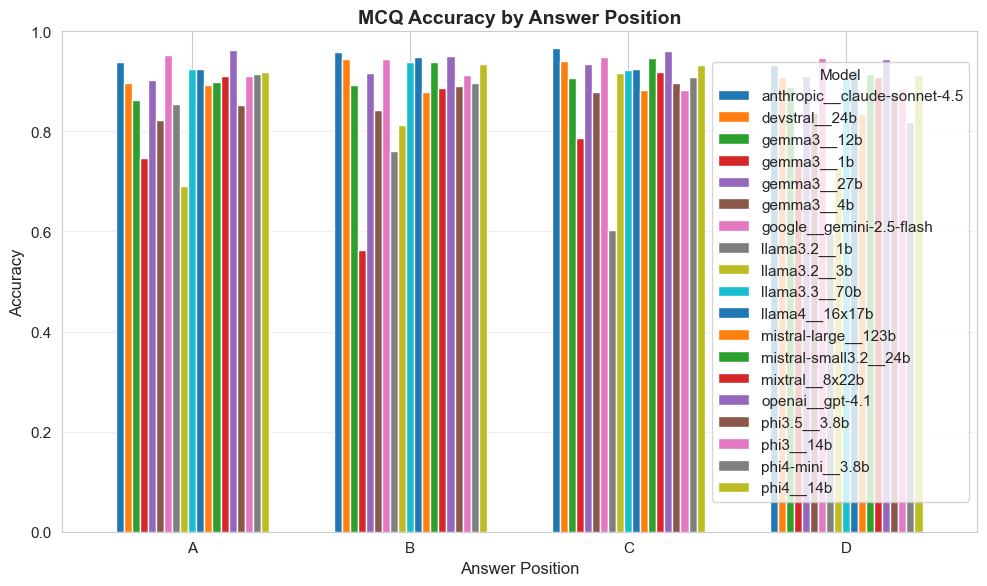

✅ Saved: {output_dir}/position_bias_bar.png


In [ ]:
# Visualization: Position bias bar chart
fig, ax = plt.subplots(figsize=(10, 6))

position_accuracy_wide = position_accuracy.pivot(index='variant', columns='model', values='accuracy')
position_accuracy_wide.plot(kind='bar', ax=ax, width=0.7)

ax.set_xlabel('Answer Position', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('MCQ Accuracy by Answer Position', fontsize=14, fontweight='bold')
ax.set_xticklabels(['A', 'B', 'C', 'D'], rotation=0)
ax.legend(title='Model', loc='right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'position_bias_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: {output_dir}/position_bias_bar.png")

PLOT 1: Per-Position Accuracy Heatmap


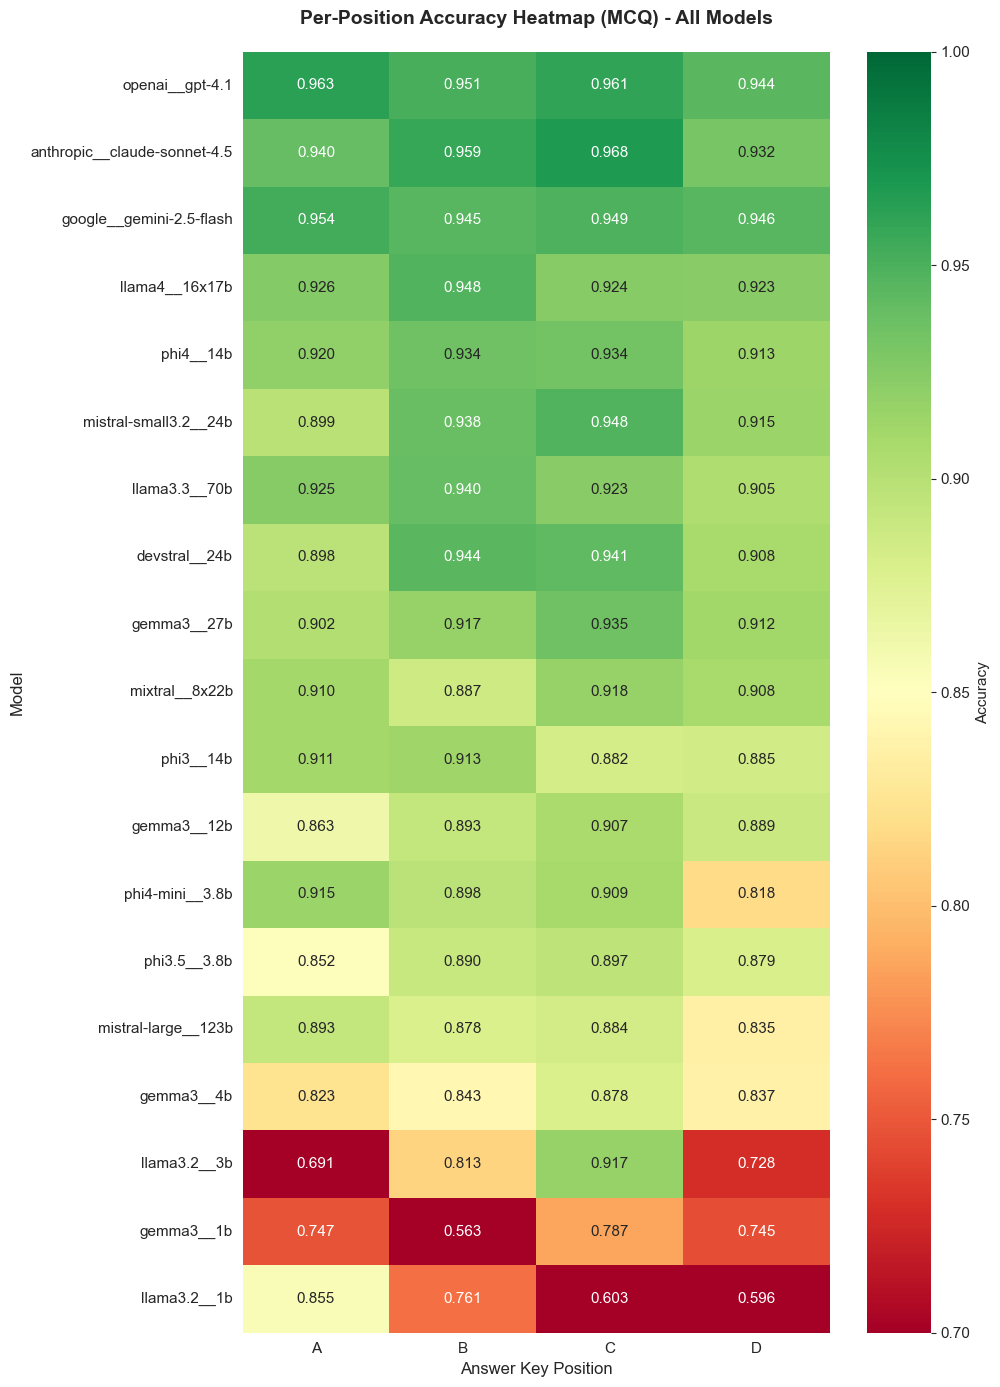

✅ Saved: output/mcq_position_heatmap.png


In [ ]:
# Plot 1: Per-Position Accuracy Heatmap (All Models)
# Comprehensive heatmap showing all models vs all position variants

print("=" * 80)
print("PLOT 1: Per-Position Accuracy Heatmap")
print("=" * 80)

# Calculate accuracy by model and position
acc_heatmap = mcq_fixed.groupby(['model', 'variant'])['is_correct'].mean().unstack(fill_value=0)

# Sort models by average accuracy across positions for better visualization
acc_heatmap['avg'] = acc_heatmap.mean(axis=1)
acc_heatmap = acc_heatmap.sort_values('avg', ascending=False).drop('avg', axis=1)

# Create figure
fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(acc_heatmap, annot=True, cmap="RdYlGn", fmt=".3f", 
            cbar_kws={'label': 'Accuracy'}, 
            xticklabels=['A', 'B', 'C', 'D'],
            vmin=0.7, vmax=1,
            ax=ax)

ax.set_title("Per-Position Accuracy Heatmap (MCQ) - All Models", fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("Answer Key Position", fontsize=12)
ax.set_ylabel("Model", fontsize=12)

plt.tight_layout()
plt.savefig(output_dir / 'mcq_position_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/mcq_position_heatmap.png")


PLOT 2: Deviation-From-Uniform Analysis


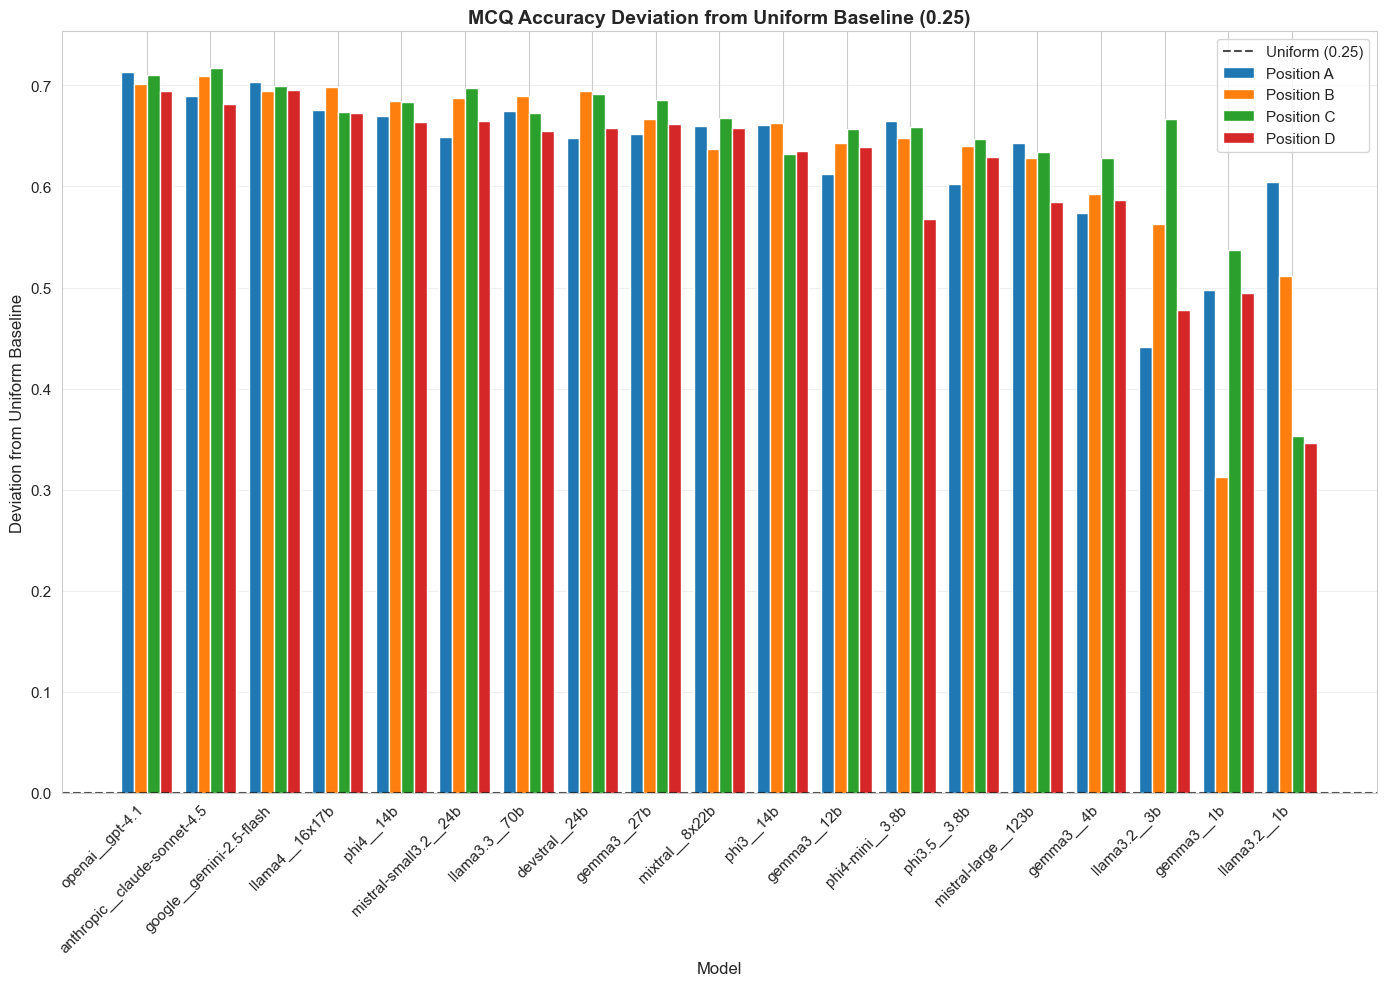

✅ Saved: output/mcq_deviation_from_uniform.png


In [ ]:
# Plot 2: Deviation-From-Uniform Bar Plot
# Expected uniform accuracy = 0.25 per position (random guessing)
# Plot (accuracy - 0.25) to show deviation from baseline

print("\n" + "=" * 80)
print("PLOT 2: Deviation-From-Uniform Analysis")
print("=" * 80)

# Calculate deviation from uniform (0.25)
uniform_baseline = 0.25
acc_pivot = position_accuracy.pivot(index='model', columns='variant', values='accuracy')
deviation = acc_pivot - uniform_baseline

# Sort by mean deviation across positions
deviation['mean_dev'] = deviation.mean(axis=1)
deviation = deviation.sort_values('mean_dev', ascending=False).drop('mean_dev', axis=1)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))
x = np.arange(len(deviation))
width = 0.2

# Plot bars for each position
for i, pos in enumerate(['a', 'b', 'c', 'd']):
    offset = (i - 1.5) * width
    ax.bar(x + offset, deviation[pos], width, label=f'Position {pos.upper()}')

# Add horizontal line at zero (uniform baseline)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Uniform (0.25)')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Deviation from Uniform Baseline', fontsize=12)
ax.set_title('MCQ Accuracy Deviation from Uniform Baseline (0.25)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(deviation.index, rotation=45, ha='right')
ax.legend(loc='best')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'mcq_deviation_from_uniform.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/mcq_deviation_from_uniform.png")

In [ ]:
print("\n" + "=" * 80)
print("PLOT: Centered MCQ Position Bias")
print("=" * 80)

# Pivot: rows=models, cols=positions (a,b,c,d)
acc_pivot = position_accuracy.pivot(index='model', columns='variant', values='accuracy')

# Compute each model's mean accuracy across positions
model_means = acc_pivot.mean(axis=1)

# Center accuracies by subtracting each model's mean
bias_centered = acc_pivot.sub(model_means, axis=0)

# Sort models by overall strength (mean accuracy)
bias_centered['mean_acc'] = model_means
bias_centered = bias_centered.sort_values('mean_acc', ascending=False)
bias_centered = bias_centered.drop(columns=['mean_acc'])

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

x = np.arange(len(bias_centered))
width = 0.2
positions = ['a', 'b', 'c', 'd']

for i, pos in enumerate(positions):
    offset = (i - 1.5) * width
    ax.bar(x + offset, bias_centered[pos], width, label=f'Position {pos.upper()}')

# Zero reference line
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Model', fontsize=12, weight='bold')
ax.set_ylabel('Deviation from Model’s Own Mean Accuracy', fontsize=12, weight='bold')
ax.set_title('MCQ Position Bias (Centered Around Each Model’s Mean Accuracy)',
             fontsize=15, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bias_centered.index, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 3.4 MCQ Normality & Distributional Tests

**What is Being Tested**

Normality tests evaluate whether the distribution of model accuracy scores follows a normal (Gaussian) distribution.  
This matters because many statistical tests (e.g., ANOVA, t-tests, linear models) assume normality of the data or residuals.

In this context, we apply normality tests to the set of per-model accuracy scores to determine whether accuracy can be treated as a normally distributed variable.

The null hypothesis for each test is:

H₀: The accuracy values come from a normal distribution.

---

**What “Significant” Means**

A result is considered significant when:

p-value < 0.05

This indicates:

- The accuracy distribution deviates meaningfully from a normal shape.
- Skewness, kurtosis, or overall distribution form differs from a normal curve.
- Normality assumptions used in parametric statistics are violated.

In practical terms:  
The accuracy values should not be analyzed with parametric tests that assume normality (e.g., ANOVA).  
Non-parametric methods (e.g., Kruskal–Wallis, Friedman) are more appropriate.

---

**What “Not Significant” Means**

A result is not significant when:

p-value ≥ 0.05

This means:

- The accuracy distribution is statistically consistent with a normal distribution.
- Deviations from normality are small enough to be attributed to random variation.
- Normality-based statistical tests may be used safely.

In practical terms:  
Parametric methods (e.g., ANOVA, t-tests, regression) are acceptable.

---

**Practical Summary**

| Result          | Interpretation                                                         |
|-----------------|-------------------------------------------------------------------------|
| Significant     | Accuracy values are **not** normal; use non-parametric statistical tests. |
| Not significant | Accuracy values are compatible with normality; parametric tests are reasonable. |



In [ ]:
# ================================================================
# 📊 Normality Tests for MCQ Accuracy — Minimal + Clean Version
# ================================================================

import pandas as pd
import json
from scipy.stats import shapiro, jarque_bera, normaltest

# Compute per-model accuracy values
accuracy_values = mcq_df.groupby("model")["is_correct"].mean().values

# Run tests
shapiro_stat, shapiro_p = shapiro(accuracy_values)
jb_stat, jb_p = jarque_bera(accuracy_values)
k2_stat, k2_p = normaltest(accuracy_values)

# Build intuitive dataframe
normality_df = pd.DataFrame([
    {
        "test": "Shapiro-Wilk",
        "statistic": float(shapiro_stat),
        "p_value": float(shapiro_p),
        "reject_normality": bool(shapiro_p < 0.05),
        "normal?": "No" if shapiro_p < 0.05 else "Yes",
        "basis": "Overall shape (best for small N)",
        "interpretation": "Distribution is not normal" 
                          if shapiro_p < 0.05 else "Distribution could be normal"
    },
    {
        "test": "Jarque-Bera",
        "statistic": float(jb_stat),
        "p_value": float(jb_p),
        "reject_normality": bool(jb_p < 0.05),
        "normal?": "No" if jb_p < 0.05 else "Yes",
        "basis": "Skewness + kurtosis",
        "interpretation": "Skew/kurtosis deviate from normal"
                          if jb_p < 0.05 else "Skew/kurtosis look normal"
    },
    {
        "test": "D'Agostino K²",
        "statistic": float(k2_stat),
        "p_value": float(k2_p),
        "reject_normality": bool(k2_p < 0.05),
        "normal?": "No" if k2_p < 0.05 else "Yes",
        "basis": "Skewness + kurtosis (transformed)",
        "interpretation": "Non-normal distribution shape"
                          if k2_p < 0.05 else "Shape consistent with normal"
    }
])

# Display in notebook
display(normality_df)

# Optional exports
normality_df.to_json("output/mcq_normality_tests.json", orient="records", indent=2)
normality_df.to_csv("output/mcq_normality_tests.csv", index=False)


,test,statistic,p_value,reject_normality,normal?,basis,interpretation
0,Shapiro-Wilk,0.782536,0.000644,True,No,Overall shape (best for small N),Distribution is not normal
1,Jarque-Bera,8.948912,0.011396,True,No,Skewness + kurtosis,Skew/kurtosis deviate from normal
2,D'Agostino K²,11.586190,0.003049,True,No,Skewness + kurtosis (transformed),Non-normal distribution shape



📊 Generating Q-Q Plot for MCQ Accuracy


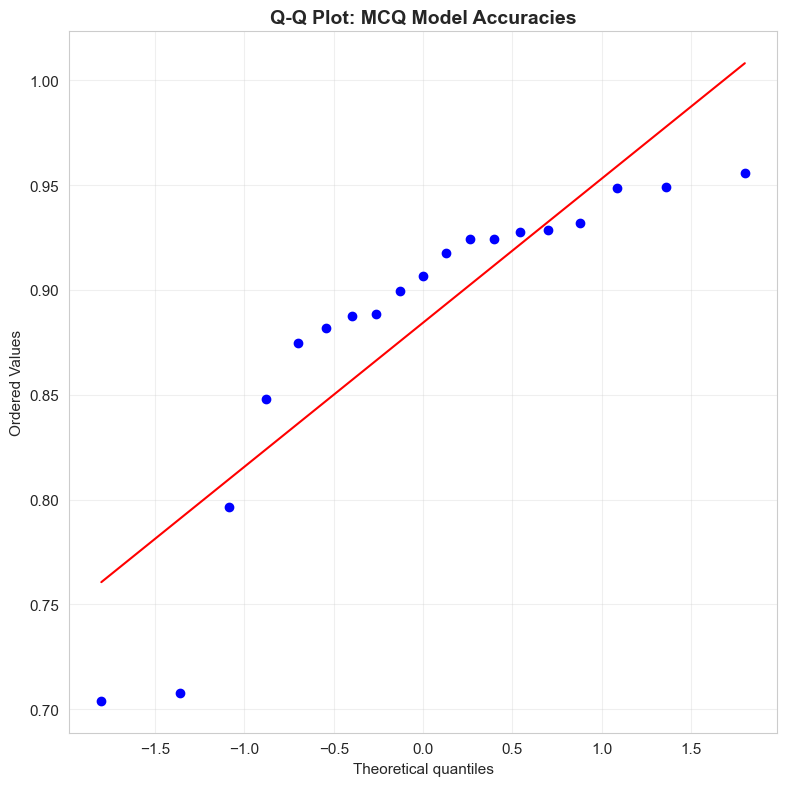

✓ Q-Q plot saved to output/qq_plot_mcq_accuracies.png


In [ ]:
# Q-Q Plot for MCQ Accuracy
print("\n📊 Generating Q-Q Plot for MCQ Accuracy")

from scipy import stats
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
stats.probplot(accuracy_values, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: MCQ Model Accuracies', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/qq_plot_mcq_accuracies.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Q-Q plot saved to output/qq_plot_mcq_accuracies.png")



PLOT 13: Q-Q Plots for Normality Assessment


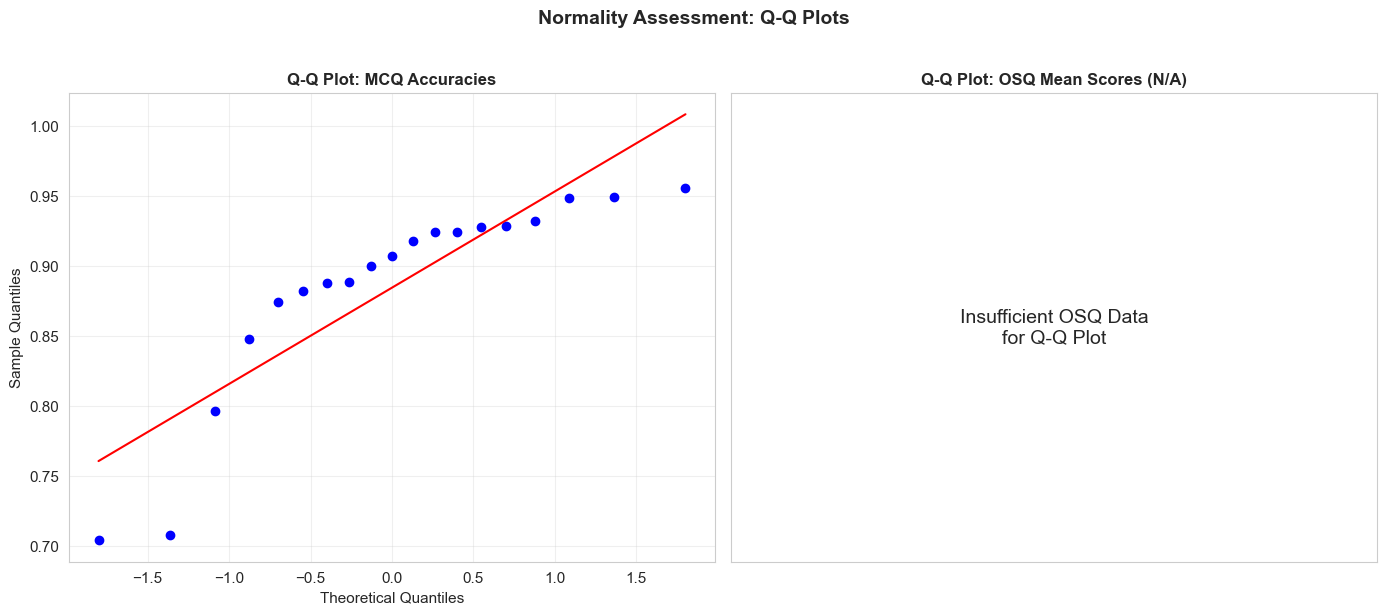

✅ Saved: output/qq_plots.png
✅ Saved: output/qq_plots.png

Shapiro-Wilk Test (MCQ):
  Statistic: 0.7825
  p-value: 0.0006
  Result: Not normally distributed at α=0.05

Shapiro-Wilk Test (OSQ): Not performed — insufficient OSQ data.


In [ ]:
# TODO: DO we move the OSQ portion to anotehr block? Or do we move both of these to mcq vs osq section?
# ================================================================
# Plot 13: Q-Q Plots for Normality Assessment
# ================================================================

print("\n" + "=" * 80)
print("PLOT 13: Q-Q Plots for Normality Assessment")
print("=" * 80)

# ------------------------------------------------
# Determine OSQ availability safely
# ------------------------------------------------
if 'osq_df' in globals() and isinstance(osq_df, pd.DataFrame) and len(osq_df) > 0:
    osq_available = True
else:
    osq_available = False

# ------------------------------------------------
# Q-Q plot for MCQ accuracies
# ------------------------------------------------
model_accuracies = mcq_df.groupby('model')['is_correct'].mean().values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MCQ Q-Q Plot
stats.probplot(model_accuracies, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: MCQ Accuracies', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Theoretical Quantiles', fontsize=11)
axes[0].set_ylabel('Sample Quantiles', fontsize=11)
axes[0].grid(True, alpha=0.3)

# ------------------------------------------------
# OSQ Q-Q Plot (if available)
# ------------------------------------------------
if osq_available and len(osq_df) > 5:
    osq_mean_scores = osq_df.groupby('model')['total_score'].mean().values
    stats.probplot(osq_mean_scores, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot: OSQ Mean Scores', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Theoretical Quantiles', fontsize=11)
    axes[1].set_ylabel('Sample Quantiles', fontsize=11)
    axes[1].grid(True, alpha=0.3)
else:
    # Display placeholder message
    axes[1].text(0.5, 0.5, 'Insufficient OSQ Data\nfor Q-Q Plot',
                 ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title('Q-Q Plot: OSQ Mean Scores (N/A)', fontsize=12, fontweight='bold')
    axes[1].set_xticks([])
    axes[1].set_yticks([])

plt.suptitle('Normality Assessment: Q-Q Plots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Ensure output directory exists
import os
os.makedirs(output_dir, exist_ok=True)

plt.savefig(output_dir / 'qq_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/qq_plots.png")
print(f"✅ Saved: {output_dir}/qq_plots.png")

# ------------------------------------------------
# Shapiro-Wilk test for normality
# ------------------------------------------------
from scipy.stats import shapiro

print("\nShapiro-Wilk Test (MCQ):")
shapiro_stat_mcq, shapiro_p_mcq = shapiro(model_accuracies)
print(f"  Statistic: {shapiro_stat_mcq:.4f}")
print(f"  p-value: {shapiro_p_mcq:.4f}")
print(f"  Result: {'Normally distributed' if shapiro_p_mcq > 0.05 else 'Not normally distributed'} at α=0.05")

if osq_available and len(osq_df) > 5:
    osq_mean_scores = osq_df.groupby('model')['total_score'].mean().values
    print("\nShapiro-Wilk Test (OSQ):")
    shapiro_stat_osq, shapiro_p_osq = shapiro(osq_mean_scores)
    print(f"  Statistic: {shapiro_stat_osq:.4f}")
    print(f"  p-value: {shapiro_p_osq:.4f}")
    print(f"  Result: {'Normally distributed' if shapiro_p_osq > 0.05 else 'Not normally distributed'} at α=0.05")
else:
    print("\nShapiro-Wilk Test (OSQ): Not performed — insufficient OSQ data.")


### 3.5 MCQ Bootstrap Confidence Intervals

**What is Being Estimated**

Bootstrap methods estimate the uncertainty of a statistic—such as accuracy, mean, or error rate—by repeatedly resampling the **observed data** and recalculating the statistic on each resample.

This is used when the theoretical sampling distribution of the statistic is unknown, difficult to compute analytically, or when normality assumptions may not hold.

In this context, the bootstrap is applied to model accuracy values to estimate:

- Confidence intervals  
- Standard errors  
- Sampling variability  

All without relying on assumptions about the underlying population distribution.

The conceptual basis is:

H₀: *The observed sample contains enough information to approximate its own sampling distribution through resampling.*

---

**What “Bootstrap” Means**

The term “bootstrap” comes from the phrase:

**“to pull oneself up by one’s own bootstraps.”**

In statistics, this refers to the idea that:

- The data **generates its own** sampling distribution  
- No external theoretical model is required  
- Uncertainty estimates come directly from the sample  
- The method is self-sufficient, “lifting itself” using only what is already available

In practical terms:  
The bootstrap relies solely on the empirical dataset to approximate repeated sampling from the population.

---

**What This Implies**

When using bootstrapping:

- There is **no assumption** of normality  
- There is **no requirement** for parametric forms (e.g., Gaussian noise, linearity)  
- Small or irregular datasets can still produce valid uncertainty estimates  
- Confidence intervals emerge directly from the resampled statistics  
- The method adapts naturally to skewed, multimodal, or bounded data (like accuracy)

In practice, this means bootstrap CIs are often **more reliable** than textbook formulas when the distribution of the statistic is unknown or non-normal.

---

**What It Does Not Mean**

Bootstrapping does **not** guarantee:

- That the sample perfectly represents the entire population  
- That resampled datasets behave like truly independent experiments  
- That bootstrap confidence intervals always match theoretical ones  

It also does **not** assume:

- The population distribution is normal  
- The statistic’s sampling distribution follows known formulas  

Bootstrap is an empirical, data-driven approximation—not a theoretical one.

---

**Practical Summary**

| Concept                    | Interpretation                                                                 |
|----------------------------|---------------------------------------------------------------------------------|
| Why it's called bootstrap  | The method “lifts itself” using only the observed data—no outside assumptions. |
| What it does               | Estimates uncertainty by resampling the data with replacement.                  |
| When it’s useful           | Unknown distributions, small samples, non-normal statistics, irregular data.    |
| What it avoids             | Parametric assumptions, normality requirements, analytical variance formulas.   |



📊 Bootstrap Confidence Intervals (10,000 iterations)

Model                          | Accuracy |               95% CI |       SE
--------------------------------------------------------------------------------
llama3.2__1b                   |   0.7040 |     [0.6920, 0.7157] |   0.0060
gemma3__1b                     |   0.7079 |     [0.6960, 0.7194] |   0.0060
llama3.2__3b                   |   0.7963 |     [0.7858, 0.8066] |   0.0053
gemma3__4b                     |   0.8481 |     [0.8388, 0.8572] |   0.0047
mistral-large__123b            |   0.8745 |     [0.8659, 0.8832] |   0.0044
phi3.5__3.8b                   |   0.8820 |     [0.8736, 0.8900] |   0.0042
phi4-mini__3.8b                |   0.8876 |     [0.8794, 0.8955] |   0.0041
gemma3__12b                    |   0.8886 |     [0.8806, 0.8967] |   0.0041
phi3__14b                      |   0.8997 |     [0.8918, 0.9073] |   0.0040
mixtral__8x22b                 |   0.9066 |     [0.8990, 0.9142] |   0.0038
gemma3__27b                 

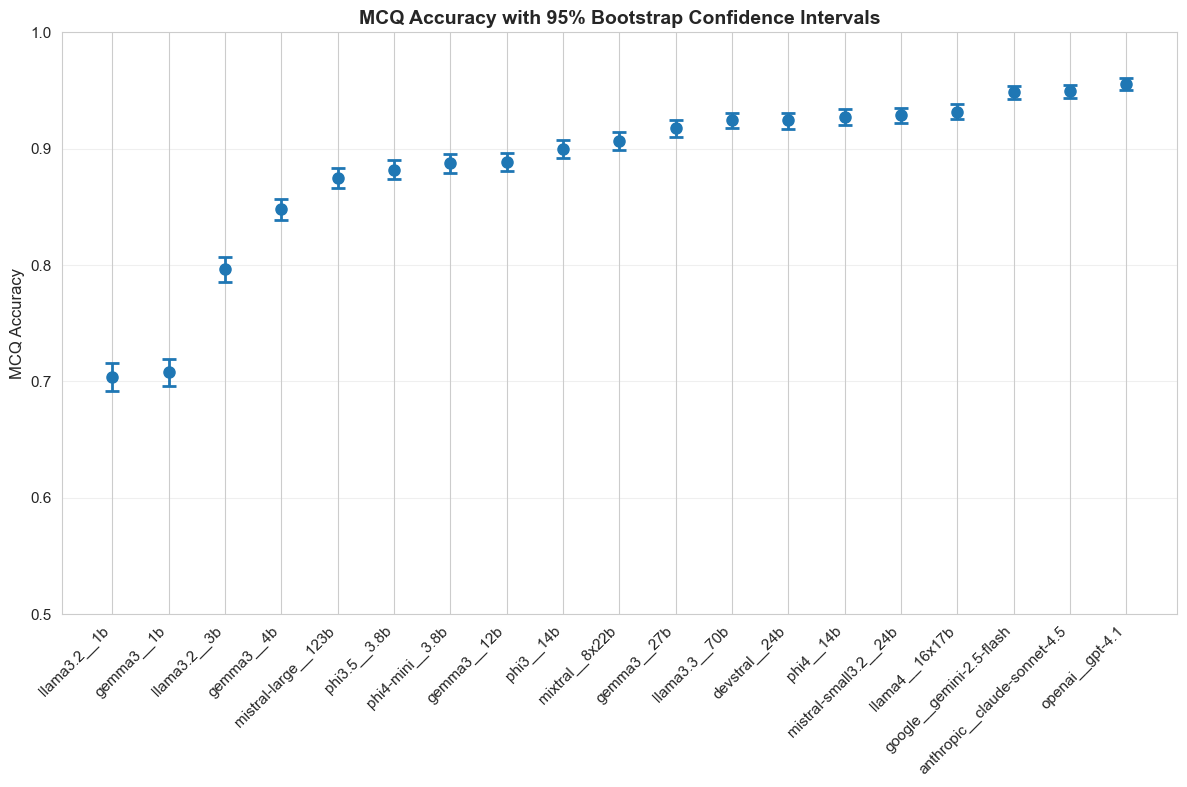

✓ Bootstrap CI plot saved to output/mcq_bootstrap_ci.png
✅ Saved LaTeX table: output\table_bootstrap_ci.tex

✓ LaTeX table saved to output/table_bootstrap_ci.tex


In [ ]:
# Bootstrap Confidence Intervals for MCQ Accuracy (Sorted + Fixed LaTeX Output)

print("\n📊 Bootstrap Confidence Intervals (10,000 iterations)")
print("=" * 80)

import numpy as np

n_iterations = 10000
confidence = 0.95
alpha = 1 - confidence
lower_percentile = (alpha / 2) * 100
upper_percentile = (1 - alpha / 2) * 100

bootstrap_results = []

for model in mcq_df['model'].unique():
    model_data = mcq_df[mcq_df['model'] == model]['is_correct'].values

    bootstrapped_means = []
    np.random.seed(42)  # reproducible per-model

    for _ in range(n_iterations):
        sample = np.random.choice(model_data, size=len(model_data), replace=True)
        bootstrapped_means.append(np.mean(sample))

    bootstrapped_means = np.array(bootstrapped_means)

    bootstrap_results.append({
        'model': model,
        'mean_accuracy': np.mean(model_data),
        'bootstrap_mean': np.mean(bootstrapped_means),
        'ci_lower': np.percentile(bootstrapped_means, lower_percentile),
        'ci_upper': np.percentile(bootstrapped_means, upper_percentile),
        'std_error': np.std(bootstrapped_means),
        'n_samples': len(model_data)
    })

bootstrap_df = pd.DataFrame(bootstrap_results)

# --- SORT LOWEST → HIGHEST MEAN ACCURACY ---
bootstrap_df = bootstrap_df.sort_values('mean_accuracy', ascending=True).reset_index(drop=True)

print(f"\n{'Model':<30s} | {'Accuracy':>8s} | {'95% CI':>20s} | {'SE':>8s}")
print("-" * 80)
for _, row in bootstrap_df.iterrows():
    ci_str = f"[{row['ci_lower']:.4f}, {row['ci_upper']:.4f}]"
    print(f"{row['model']:<30s} | {row['mean_accuracy']:>8.4f} | {ci_str:>20s} | {row['std_error']:>8.4f}")

print("\n✓ Bootstrap confidence intervals complete")

# --- PLOT (Sorted + Fixed Y Range) ---
fig, ax = plt.subplots(figsize=(12, 8))

models = bootstrap_df['model'].values
means = bootstrap_df['mean_accuracy'].values
ci_lower = bootstrap_df['ci_lower'].values
ci_upper = bootstrap_df['ci_upper'].values
errors = np.array([means - ci_lower, ci_upper - means])

ax.errorbar(range(len(models)), means, yerr=errors, fmt='o',
            capsize=5, capthick=2, markersize=8, linewidth=2)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('MCQ Accuracy', fontsize=12)
ax.set_title('MCQ Accuracy with 95% Bootstrap Confidence Intervals', fontsize=14, fontweight='bold')

# --- FIX Y RANGE ---
ax.set_ylim(0.50, 1.00)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/mcq_bootstrap_ci.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Bootstrap CI plot saved to output/mcq_bootstrap_ci.png")

# --- SAVE ONLY LaTeX TABLE (FIXED PATH) ---
export_latex_table(
    bootstrap_df[['model', 'mean_accuracy', 'ci_lower', 'ci_upper', 'std_error']],
    'table_bootstrap_ci.tex',  # FIXED: no nested output/output
    "Bootstrap 95% Confidence Intervals for MCQ Accuracy",
    'tab:bootstrap_ci'
)

print("\n✓ LaTeX table saved to output/table_bootstrap_ci.tex")


## 4. OSQ Analysis


### 4.1 OSQ Data Exploration


In [ ]:
# Configuration: Judge Loading Strategy
# Set to False to load ALL available judges (recommended for comprehensive analysis)
# Set to True to load only the latest judge per model
OSQ_USE_LATEST = False  # Load ALL judges to see complete judgment matrix

print(f"Judge Loading Mode: {'LATEST ONLY' if OSQ_USE_LATEST else 'ALL JUDGES'}")

In [ ]:
def build_osq_multi_judge_progress_matrix(phase5_dir: Path, use_latest: bool = False) -> pd.DataFrame:
    """
    Build progress matrix showing ALL judge models × ALL evaluated models.
    
    Args:
        phase5_dir: Path to phase5_llm_as_a_judge directory
        use_latest: If True, only show latest judge per model; if False, show all judges
    
    Returns:
        DataFrame with columns: model_name, judge_model, prompt_id, sample_count, judged_file
    """
    import re
    from pathlib import Path
    
    osq_judge_dir = phase5_dir / "sysengbench-osq-llm-judge"
    
    if not osq_judge_dir.exists():
        print(f"⚠️  OSQ judge directory not found: {osq_judge_dir}")
        return pd.DataFrame()
    
    rows = []
    
    # Iterate through each model directory
    model_dirs = sorted([d for d in osq_judge_dir.iterdir() if d.is_dir()])
    
    for model_dir in model_dirs:
        model_name = model_dir.name
        
        # Find all judge files
        judge_files = sorted([f for f in model_dir.iterdir() 
                            if f.is_file() and f.name.startswith('samples_') and f.suffix == '.jsonl'])
        
        if not judge_files:
            continue
        
        # Group by judge model and prompt
        judge_data = []
        for jf in judge_files:
            # Extract judge model and prompt ID from filename
            # Format: samples_sysengbench-osq_TIMESTAMP__JUDGE_MODEL-PROMPT.jsonl
            match = re.search(r'__(.+)-(p\d+)\.jsonl$', jf.name)
            if match:
                judge_model = match.group(1)
                prompt_id = match.group(2)
                
                # Count samples
                try:
                    with open(jf, 'r', encoding='utf-8') as f:
                        sample_count = sum(1 for _ in f)
                except:
                    sample_count = 0
                
                judge_data.append({
                    'file': jf,
                    'judge_model': judge_model,
                    'prompt_id': prompt_id,
                    'sample_count': sample_count,
                    'timestamp': jf.stat().st_mtime
                })
        
        # Filter to latest if requested
        if use_latest and judge_data:
            # Sort by timestamp and take the latest
            judge_data = sorted(judge_data, key=lambda x: x['timestamp'], reverse=True)
            judge_data = [judge_data[0]]
        
        # Add to rows
        for jd in judge_data:
            rows.append({
                'model_name': model_name,
                'judge_model': jd['judge_model'],
                'prompt_id': jd['prompt_id'],
                'sample_count': jd['sample_count'],
                'judged_file': str(jd['file'].name)
            })
    
    df = pd.DataFrame(rows)
    
    if len(df) > 0:
        # Sort for better readability
        df = df.sort_values(['judge_model', 'model_name']).reset_index(drop=True)
    
    return df

print("✓ Multi-judge progress matrix function loaded")

In [ ]:
# Build and display OSQ multi-judge progress matrix
print("=" * 80)
print("OSQ MULTI-JUDGE PROGRESS MATRIX")
print("=" * 80)

osq_progress_df = build_osq_multi_judge_progress_matrix(phase5_dir, use_latest=OSQ_USE_LATEST)

if len(osq_progress_df) > 0:
    print(f"\n📊 Found {len(osq_progress_df)} judge-model combinations")
    print(f"   Judges: {osq_progress_df['judge_model'].nunique()}")
    print(f"   Models: {osq_progress_df['model_name'].nunique()}")
    print(f"   Prompts: {osq_progress_df['prompt_id'].unique().tolist()}")
    
    # Display summary by judge
    print("\n📋 Judge Model Summary:")
    judge_summary = osq_progress_df.groupby('judge_model').agg({
        'model_name': 'count',
        'sample_count': 'sum'
    }).rename(columns={'model_name': 'models_judged', 'sample_count': 'total_samples'})
    display(judge_summary)
    
    # Create pivot table for matrix view
    print("\n📊 Progress Matrix (Judge × Model):")
    matrix_pivot = osq_progress_df.pivot_table(
        index='judge_model',
        columns='model_name',
        values='sample_count',
        fill_value=0
    ).astype(int)
    display(matrix_pivot)
    
    # Full detail table
    print("\n📋 Complete Judge-Model Combinations:")
    display(osq_progress_df)
    
else:
    print("⚠️  No OSQ judge data found")

print("\n" + "=" * 80)

In [38]:
# Load OSQ data and create aligned datasetprint("=" * 80)print("OSQ DATA LOADING")print("=" * 80)try:    print(f"\n📊 Parsing OSQ judged samples (mode: {'LATEST ONLY' if OSQ_USE_LATEST else 'ALL JUDGES'})...")    print("\n📊 Parsing OSQ judged samples...")    osq_data = parse_osq_judged_samples(phase5_dir, use_latest=OSQ_USE_LATEST)    osq_df = pd.DataFrame(osq_data)        print(f"✅ OSQ DataFrame shape: {osq_df.shape}")    print(f"✅ OSQ DataFrame shape: {osq_df.shape}")        if len(osq_df) > 0:        print(f"   Models: {osq_df['model'].unique().tolist()}")        print(f"   Questions: {osq_df['question_id'].nunique()}")        print(f"   Mean score: {osq_df['total_score'].mean():.2f}")                # Display available judges and prompts        judges_and_prompts = get_available_judges_and_prompts(osq_data)        print(f"\n📋 Available Judges: {judges_and_prompts['judges']}")        print(f"📋 Available Prompts: {judges_and_prompts['prompts']}")                # Count samples by judge and prompt        print("\n📊 Sample counts by judge and prompt:")        judge_prompt_counts = osq_df.groupby(['judge_model', 'prompt_id']).size().reset_index(name='count')        for _, row in judge_prompt_counts.iterrows():            print(f"   {row['judge_model']:30s} | {row['prompt_id']:5s} | {row['count']:4d} samples")                # Align MCQ and OSQ data        print("\n📊 Aligning MCQ and OSQ data...")        print("\n📊 Aligning MCQ and OSQ data...")        aligned_df = pd.DataFrame(align_mcq_osq_results(mcq_data, osq_data))        print(f"✅ Aligned DataFrame shape: {aligned_df.shape}")        print(f"✅ Aligned DataFrame shape: {aligned_df.shape}")                osq_available = True    else:        print("⚠️  No OSQ samples found. OSQ plots will be skipped.")        print("⚠️  No OSQ samples found. OSQ plots will be skipped.")        osq_available = False        aligned_df = pd.DataFrame()        except Exception as e:    print(f"⚠️  Error loading OSQ data: {e}")    print(f"⚠️  Error loading OSQ data: {e}")    print("   OSQ plots will be skipped.")    osq_available = False    osq_df = pd.DataFrame()    aligned_df = pd.DataFrame()

OSQ DATA LOADING

📊 Parsing OSQ judged samples...

📊 Parsing OSQ judged samples...
📖 Parsing anthropic__claude-sonnet-4.5/samples_sysengbench-osq_2025-11-16T21-02-49.453852__google_gemini-2.5-flash-p1.jsonl (judge: google_gemini-2.5-flash, prompt: p1)
   ⚠️  Error processing line 1: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠️  Error processing line 2: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠️  Error processing line 3: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠️  Error processing line 4: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠️  Error processing line 5: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠️  Error processing line 6: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠️  Error processing line 7: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠️  Error processing line 8: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠

In [39]:
display(aligned_df.head())

,model,question_id,category,tags,question,mcq_random_correct,mcq_a_correct,mcq_b_correct,mcq_c_correct,mcq_d_correct,...,osq_is_correct,osq_technical_accuracy,osq_conceptual_understanding,osq_completeness,osq_clarity_organization,osq_professional_relevance,blooms_level,judge_model,prompt_id,mcq_avg_correct
0,google__gemini-2.5-flash,521,INCOSEHandbook/Lifecycle Stages/Defense Acquis...,None,Which activity is a key focus during the Opera...,True,True,True,True,True,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,1.0
1,llama3.3__70b,682,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,What does MIL-STD-882 specify about the manage...,True,True,True,True,True,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,1.0
2,devstral__24b,438,INCOSEHandbook/Cross-Cutting Systems Engineeri...,Allocations,What term best describes the nature of allocat...,True,True,True,True,True,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,1.0
3,anthropic__claude-sonnet-4.5,694,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,"Under MIL-STD-1474, what must be considered wh...",True,True,True,True,True,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,1.0
4,openai__gpt-4.1,201,INCOSEHandbook/Systems Engineering Overview/Sy...,None,"According to SEBoK, what is a key benefit of S...",True,True,True,True,True,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,1.0


In [40]:
# Optional: Filter OSQ data by specific judge and/or prompt
# Uncomment and modify the lines below to filter:

# FILTER_JUDGE = 'openai_gpt-5'  # Set to None for all judges
# FILTER_JUDGE = 'openai_gpt-5-mini'  # Set to None for all judges
# FILTER_PROMPT = 'p1'           # Set to None for all prompts
FILTER_JUDGE = None
FILTER_PROMPT = None

if osq_available and (FILTER_JUDGE is not None or FILTER_PROMPT is not None):
    print("\n" + "=" * 80)
    print("FILTERING OSQ DATA")
    print("=" * 80)
    
    original_count = len(osq_data)
    osq_data_filtered = filter_osq_data(osq_data, judge_model=FILTER_JUDGE, prompt_id=FILTER_PROMPT)
    osq_df = pd.DataFrame(osq_data_filtered)
    
    print(f"\nFiltering criteria:")
    print(f"   Judge: {FILTER_JUDGE if FILTER_JUDGE else 'All'}")
    print(f"   Prompt: {FILTER_PROMPT if FILTER_PROMPT else 'All'}")
    print(f"\n✅ Filtered: {original_count} → {len(osq_data_filtered)} samples")
    
    # Re-align MCQ and OSQ data with filtered data
    print("\n📊 Re-aligning MCQ and OSQ data with filtered samples...")
    aligned_df = pd.DataFrame(align_mcq_osq_results(mcq_data, osq_data_filtered))
    print(f"✅ Aligned DataFrame shape: {aligned_df.shape}")
else:
    print("\n📌 No filtering applied. Using all OSQ data.")


📌 No filtering applied. Using all OSQ data.


In [42]:
# TODO: Fix this -- there are multiple judge files available. It says there is only 1. Maybe it is saying you need all questions done. Finish running gpt-5 and see if this gets fixed.

print(aligned_df)

                              model  question_id  \
0          google__gemini-2.5-flash          521   
1                     llama3.3__70b          682   
2                     devstral__24b          438   
3      anthropic__claude-sonnet-4.5          694   
4                   openai__gpt-4.1          201   
...                             ...          ...   
21731                   gemma3__27b          432   
21732                llama4__16x17b          298   
21733           mistral-large__123b            9   
21734                  llama3.2__3b          790   
21735                     phi3__14b          566   

                                                category  \
0      INCOSEHandbook/Lifecycle Stages/Defense Acquis...   
1      INCOSEHandbook/Specialty Engineering Activitie...   
2      INCOSEHandbook/Cross-Cutting Systems Engineeri...   
3      INCOSEHandbook/Specialty Engineering Activitie...   
4      INCOSEHandbook/Systems Engineering Overview/Sy...   
...            

In [ ]:
# ================================================================
# OSQ Judge and Prompt Analysis
# ================================================================

if osq_available and len(osq_df) > 0:
    print("=" * 80)
    print("OSQ JUDGE AND PROMPT ANALYSIS")
    print("=" * 80)
    
    # Check if we have multiple judges or prompts
    n_judges = osq_df['judge_model'].nunique()
    n_prompts = osq_df['prompt_id'].nunique()
    
    print(f"\nNumber of unique judges: {n_judges}")
    print(f"Number of unique prompts: {n_prompts}")
    
    # Calculate mean scores by judge and prompt
    if n_judges > 1 or n_prompts > 1:
        print("\n📊 Mean scores by judge and prompt:")
        judge_prompt_stats = osq_df.groupby(['judge_model', 'prompt_id']).agg({
            'total_score': ['mean', 'std', 'count'],
            'percentage': 'mean'
        }).round(2)
        print(judge_prompt_stats)
        
        # Calculate mean scores by model, judge, and prompt
        print("\n📊 Mean scores by model, judge, and prompt:")
        model_judge_prompt_stats = osq_df.groupby(['model', 'judge_model', 'prompt_id'])['total_score'].mean().round(2)
        print(model_judge_prompt_stats.head(20))
    
    else:
        print("\n📌 Only one judge/prompt combination found. Skipping comparative analysis.")
else:
    print("⚠️ OSQ data not available for judge/prompt analysis")

OSQ JUDGE AND PROMPT ANALYSIS

Number of unique judges: 1
Number of unique prompts: 1

📌 Only one judge/prompt combination found. Skipping comparative analysis.


### 4.2 OSQ Score Distribution


In [ ]:
# ================================================================
# Plot: OSQ Score Distribution by Judge Model
# ================================================================

if osq_available and len(osq_df) > 0:
    n_judges = osq_df['judge_model'].nunique()
    
    if n_judges > 1:
        print("\n📊 PLOT: OSQ Score Distribution by Judge Model")
        print("=" * 80)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Box plot by judge
        osq_df.boxplot(column='total_score', by='judge_model', ax=axes[0])
        axes[0].set_title('OSQ Score Distribution by Judge Model', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Judge Model', fontsize=12)
        axes[0].set_ylabel('Total Score (out of 100)', fontsize=12)
        axes[0].get_figure().suptitle('')  # Remove auto-generated title
        plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # Violin plot by judge
        sns.violinplot(data=osq_df, x='judge_model', y='total_score', ax=axes[1])
        axes[1].set_title('OSQ Score Distribution by Judge Model (Violin)', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Judge Model', fontsize=12)
        axes[1].set_ylabel('Total Score (out of 100)', fontsize=12)
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.savefig(output_dir / 'osq_scores_by_judge.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Saved: {output_dir / 'osq_scores_by_judge.png'}")
    else:
        print("\n📌 Only one judge found. Skipping judge comparison plot.")


📌 Only one judge found. Skipping judge comparison plot.


In [ ]:
# ================================================================
# Plot: OSQ Score Distribution by Prompt
# ================================================================

if osq_available and len(osq_df) > 0:
    n_prompts = osq_df['prompt_id'].nunique()
    
    if n_prompts > 1:
        print("\n📊 PLOT: OSQ Score Distribution by Prompt")
        print("=" * 80)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Box plot by prompt
        osq_df.boxplot(column='total_score', by='prompt_id', ax=axes[0])
        axes[0].set_title('OSQ Score Distribution by Prompt', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Prompt ID', fontsize=12)
        axes[0].set_ylabel('Total Score (out of 100)', fontsize=12)
        axes[0].get_figure().suptitle('')  # Remove auto-generated title
        
        # Violin plot by prompt
        sns.violinplot(data=osq_df, x='prompt_id', y='total_score', ax=axes[1])
        axes[1].set_title('OSQ Score Distribution by Prompt (Violin)', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Prompt ID', fontsize=12)
        axes[1].set_ylabel('Total Score (out of 100)', fontsize=12)
        
        plt.tight_layout()
        plt.savefig(output_dir / 'osq_scores_by_prompt.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Saved: {output_dir / 'osq_scores_by_prompt.png'}")
    else:
        print("\n📌 Only one prompt found. Skipping prompt comparison plot.")


📌 Only one prompt found. Skipping prompt comparison plot.


In [ ]:
# ================================================================
# Plot: Model Performance Across Different Judges
# ================================================================

if osq_available and len(osq_df) > 0:
    n_judges = osq_df['judge_model'].nunique()
    n_models = osq_df['model'].nunique()
    
    if n_judges > 1 and n_models > 1:
        print("\n📊 PLOT: Model Performance Across Different Judges")
        print("=" * 80)
        
        # Create pivot table for heatmap
        pivot_data = osq_df.pivot_table(
            values='total_score',
            index='model',
            columns='judge_model',
            aggfunc='mean'
        )
        
        # Create heatmap
        plt.figure(figsize=(12, max(8, n_models * 0.5)))
        sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='RdYlGn', 
                   cbar_kws={'label': 'Mean Total Score'}, vmin=0, vmax=100)
        plt.title('Model Performance Across Different Judge Models\n(Mean Total Score out of 100)', 
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Judge Model', fontsize=12)
        plt.ylabel('Evaluated Model', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(output_dir / 'osq_model_performance_by_judge_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Saved: {output_dir / 'osq_model_performance_by_judge_heatmap.png'}")
        
        # Calculate correlation between judges
        print("\n📊 Inter-Judge Correlation:")
        judge_corr = pivot_data.corr()
        print(judge_corr)
        
    else:
        print("\n📌 Need multiple judges and models for comparison. Skipping.")


📌 Need multiple judges and models for comparison. Skipping.


### Plot 6: OSQ Score Distribution Histogram with KDE

**What is Being Visualized**

This plot examines how OSQ total scores are distributed for each model by showing a smoothed estimate of the score density.  
The visualization combines Kernel Density Estimation (KDE) curves for all models, allowing a direct comparison of how their score distributions differ in shape, spread, central tendency, and variance.

In this context, KDE provides a continuous approximation of the score distribution for each model, revealing whether models tend to score similarly, whether some produce more variable OSQ results, and whether any distribution is skewed, bimodal, or tightly clustered.

The plot also includes a vertical line at the passing threshold (70), allowing interpretation of how each model’s distribution relates to the benchmark.

---

**What KDE Represents**

Kernel Density Estimation is a non-parametric method that estimates the probability density function of a variable.  
It does this by placing a smooth "kernel" (similar to a bump or bell curve) over each data point and summing them to produce a continuous distribution curve.

KDE curves help identify:

- The most common score ranges  
- Whether distributions are narrow or wide  
- The presence of skewness or multimodality  
- How each model’s score pattern differs from others  

In practical terms:  
KDE smooths out the noise of a histogram and produces a clearer view of the underlying distribution.

---

**What This Implies**

A KDE plot makes it easier to interpret differences between models because:

- Models with higher peaks around a wider range may be more variable  
- Models with tight, narrow peaks show more consistent scoring  
- Overlapping KDE curves indicate similar scoring behaviors  
- Curves shifted left or right indicate relative performance differences  
- Alignment with or deviation from the passing threshold indicates practical performance implications  

Because KDE is non-parametric, it does not assume the scores follow a normal distribution and adapts naturally to skewed or irregular score patterns.

---

**What It Does Not Mean**

KDE does **not** imply:

- That the score distribution follows a specific theoretical form  
- That the smoothing reflects true population variance  
- That the highest KDE point corresponds exactly to the mean or median  
- That KDE is reliable with extremely small sample sizes  

The method also does not guarantee:

- Accurate representation when only a few data points exist (hence requiring at least 3 points per model)  
- That the KDE curve captures rare outlier behavior  

KDE is an approximation dependent on sample size and smoothing parameters.

---

**Practical Summary**

| Concept                   | Interpretation                                                                 |
|---------------------------|---------------------------------------------------------------------------------|
| What is visualized        | KDE curves showing the estimated distribution of OSQ total scores per model.    |
| What KDE shows            | Smoothed density patterns: peaks, spread, skewness, modality, overlap.          |
| Why it’s useful           | Reveals distribution shape without assuming normality; clearer than histograms. |
| What it avoids            | Parametric assumptions about score distributions; reliance on bin settings.     |
| Passing threshold line    | Shows how each model’s distribution aligns with the OSQ passing score (70).     |



PLOT 6: OSQ Score Histogram with Density


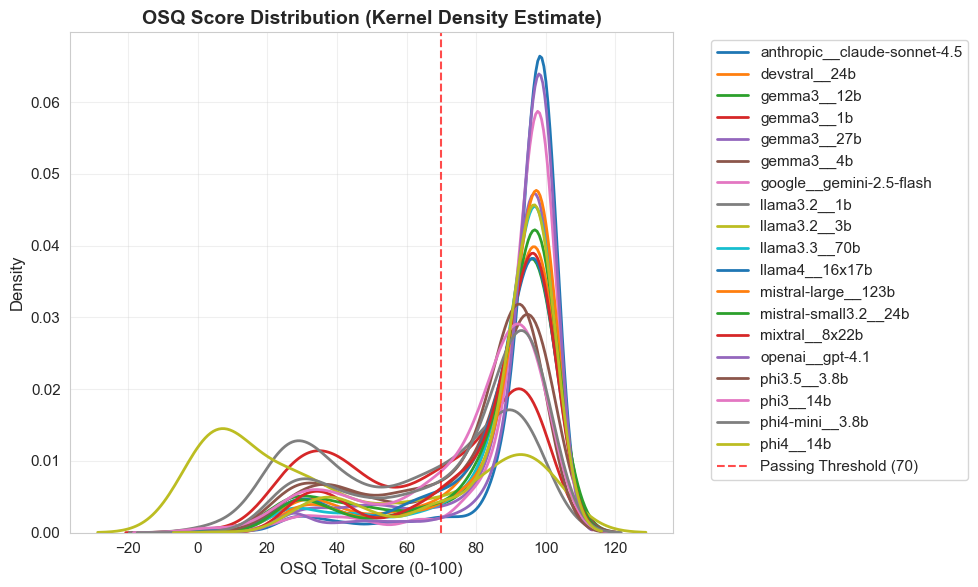

✅ Saved: output/osq_score_histogram.png
✅ Saved: output/osq_score_histogram.png


In [ ]:

if osq_available and len(osq_df) > 10:
    print("\n" + "=" * 80)
    print("PLOT 6: OSQ Score Histogram with Density")
    print("=" * 80)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create histogram with KDE for each model
    for model in osq_df['model'].unique():
        model_scores = osq_df[osq_df['model'] == model]['total_score']
        if len(model_scores) >= 3:  # Need at least 3 points for KDE
            sns.kdeplot(data=model_scores, label=model, ax=ax, linewidth=2)
    
    ax.set_xlabel('OSQ Total Score (0-100)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('OSQ Score Distribution (Kernel Density Estimate)', fontsize=14, fontweight='bold')
    ax.axvline(x=70, color='red', linestyle='--', alpha=0.7, label='Passing Threshold (70)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'osq_score_histogram.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Saved: {output_dir}/osq_score_histogram.png")
    print(f"✅ Saved: {output_dir}/osq_score_histogram.png")
else:
    print("\n⚠️  Skipping Plot 6 (OSQ Histogram): Insufficient data")
    print("\n⚠️  Skipping Plot 6 (OSQ Histogram): Insufficient data")
    print(f"   Current OSQ samples: {len(osq_df) if 'osq_df' in locals() else 0}")


PLOT 5: OSQ Score Distribution (Violin Plot)


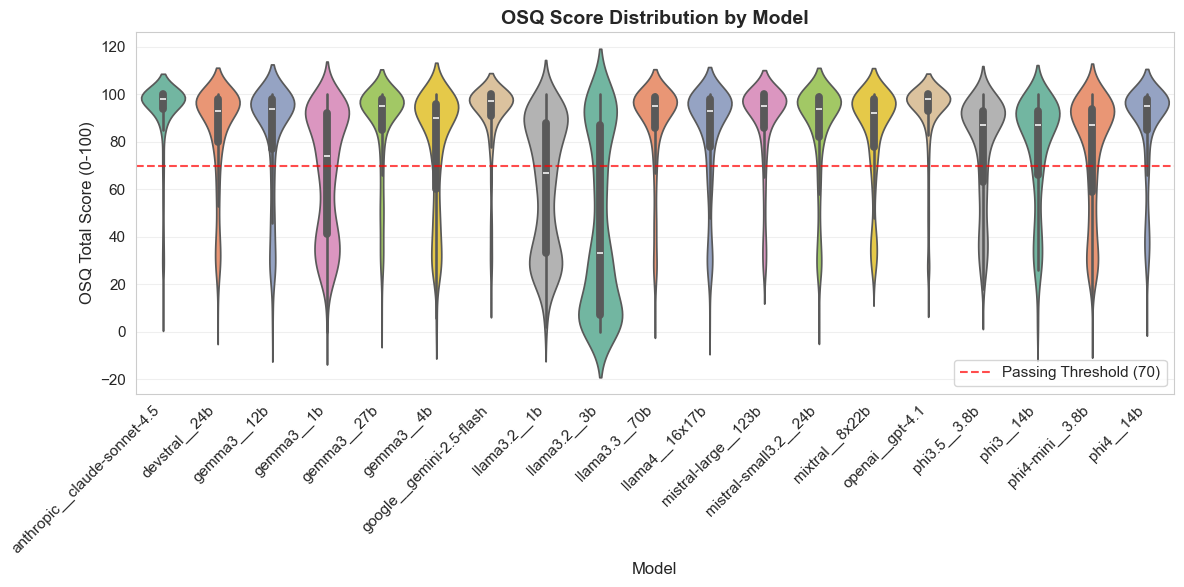

✅ Saved: output/osq_violin_scores.png
✅ Saved: output/osq_violin_scores.png


In [35]:
# Plot 5: OSQ Violin Plot - Score Distribution
if osq_available and len(osq_df) > 10:  # Need reasonable sample size
    print("\n" + "=" * 80)
    print("PLOT 5: OSQ Score Distribution (Violin Plot)")
    print("=" * 80)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create violin plot by model
    sns.violinplot(data=osq_df, x='model', y='total_score', ax=ax, palette='Set2')
    
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('OSQ Total Score (0-100)', fontsize=12)
    ax.set_title('OSQ Score Distribution by Model', fontsize=14, fontweight='bold')
    ax.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Passing Threshold (70)')
    plt.xticks(rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'osq_violin_scores.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Saved: {output_dir}/osq_violin_scores.png")
    print(f"✅ Saved: {output_dir}/osq_violin_scores.png")
else:
    print("\n⚠️  Skipping Plot 5 (OSQ Violin): Insufficient data")
    print("\n⚠️  Skipping Plot 5 (OSQ Violin): Insufficient data")
    print(f"   Current OSQ samples: {len(osq_df) if 'osq_df' in locals() else 0}")
    print("   Need at least 10 samples for meaningful visualization")

In [38]:
osq_df.columns.tolist()


['model',
 'question_id',
 'category',
 'tags',
 'osq_prompt',
 'expected_answer',
 'model_response',
 'blooms_level',
 'judge_model',
 'prompt_id',
 'technical_accuracy',
 'conceptual_understanding',
 'completeness',
 'clarity_organization',
 'professional_relevance',
 'total_score',
 'percentage',
 'is_correct',
 'sample_id',
 'file']

In [ ]:
# Plot 5: OSQ Stripplot (Rubric Dimensions) - Optimized for performance
if osq_available and len(osq_df) > 10:
    print("\n" + "=" * 80)
    print("PLOT 5: OSQ Stripplot (Rubric Dimensions)")
    print("=" * 80)

    # Explicit mapping based on your actual OSQ fields
    rubric_fields = [
        ("technical_accuracy", "Technical Accuracy"),
        ("conceptual_understanding", "Conceptual Understanding"),
        ("completeness", "Completeness"),
        ("clarity_organization", "Clarity & Organization"),
        ("professional_relevance", "Professional Relevance")
    ]

    n_fields = len(rubric_fields)

    fig, axes = plt.subplots(
        n_fields, 1,
        figsize=(12, 3.6 * n_fields),
        sharex=True
    )

    if n_fields == 1:
        axes = [axes]

    for ax, (col, label) in zip(axes, rubric_fields):

        # Use stripplot instead of swarmplot for much better performance
        # stripplot is 10-100x faster and still shows individual data points
        sns.stripplot(
            data=osq_df,
            x="model",
            y=col,
            hue="model",
            palette="Set2",
            size=5,
            alpha=0.6,
            jitter=True,
            dodge=False,
            ax=ax
        )

        ax.set_ylabel(f"{label} (0–100)", fontsize=12)
        ax.set_title(f"{label} by Model", fontsize=14, fontweight="bold")

        # Draw passing threshold (>=70)
        ax.axhline(y=70, color="red", linestyle="--", alpha=0.6)

        ax.grid(axis="y", alpha=0.3)
        ax.legend([], [], frameon=False)  # hide repeated legends

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    save_path = output_dir / "osq_stripplot_rubric.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✅ Saved: {save_path}")

else:
    print("\n⚠️  Skipping Plot 5 (OSQ Stripplot): Insufficient data")
    print(f"   Current OSQ samples: {len(osq_df) if 'osq_df' in locals() else 0}")


PLOT 5: OSQ Beeswarm Plot (Rubric Dimensions)



PLOT 7: OSQ Performance by Bloom's Taxonomy Level


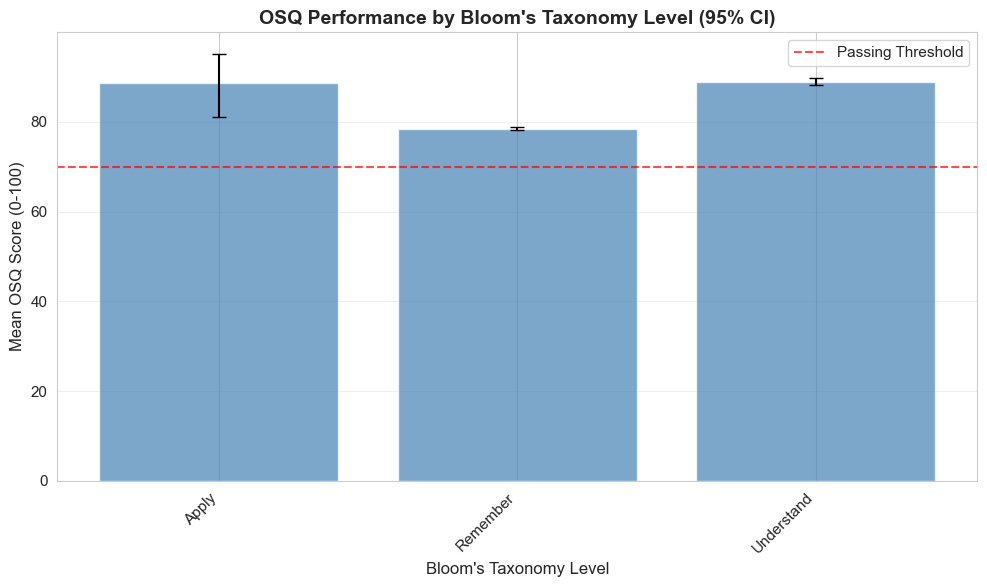

✅ Saved: output/osq_blooms_comparison.png
✅ Saved: output/osq_blooms_comparison.png

Bloom's Level Performance:
                   mean        std  count   ci_lower   ci_upper
blooms_level                                                   
Apply         88.710526  22.068576     38  80.998684  95.186842
Remember      78.503750  26.196903  14134  78.089380  78.907342
Understand    88.960891  18.486675   1841  88.127567  89.780187
✅ Saved LaTeX table: output\table_blooms_performance.tex


In [36]:
# Plot 7: OSQ Bloom's Level Comparison (if Bloom's data available)
if osq_available and len(osq_df) > 10 and 'blooms_level' in osq_df.columns:
    print("\n" + "=" * 80)
    print("PLOT 7: OSQ Performance by Bloom's Taxonomy Level")
    print("=" * 80)
    
    # Filter out null Bloom's levels
    osq_blooms = osq_df[osq_df['blooms_level'].notna()].copy()
    
    if len(osq_blooms) > 0:
        # Calculate mean score per Bloom's level
        blooms_summary = osq_blooms.groupby('blooms_level')['total_score'].agg(['mean', 'std', 'count']).reset_index()
        
        # Bootstrap 95% CI
        def bootstrap_ci(data, n_boot=1000):
            boots = [resample(data, n_samples=len(data)).mean() for _ in range(n_boot)]
            return np.percentile(boots, [2.5, 97.5])
        
        ci_data = []
        for level in osq_blooms['blooms_level'].unique():
            level_scores = osq_blooms[osq_blooms['blooms_level'] == level]['total_score']
            if len(level_scores) >= 3:
                ci = bootstrap_ci(level_scores)
                ci_data.append({'blooms_level': level, 'ci_lower': ci[0], 'ci_upper': ci[1]})
        
        ci_df = pd.DataFrame(ci_data)
        blooms_summary = blooms_summary.merge(ci_df, on='blooms_level', how='left')
        
        # Create bar chart
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(blooms_summary))
        
        ax.bar(x, blooms_summary['mean'], yerr=[
            blooms_summary['mean'] - blooms_summary['ci_lower'],
            blooms_summary['ci_upper'] - blooms_summary['mean']
        ], capsize=5, alpha=0.7, color='steelblue')
        
        ax.set_xlabel("Bloom's Taxonomy Level", fontsize=12)
        ax.set_ylabel('Mean OSQ Score (0-100)', fontsize=12)
        ax.set_title("OSQ Performance by Bloom's Taxonomy Level (95% CI)", fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(blooms_summary['blooms_level'], rotation=45, ha='right')
        ax.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Passing Threshold')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(output_dir / 'osq_blooms_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Saved: {output_dir}/osq_blooms_comparison.png")
        print(f"✅ Saved: {output_dir}/osq_blooms_comparison.png")
        
        # Also export as table
        blooms_table = blooms_summary.set_index('blooms_level')
        print("\nBloom's Level Performance:")
        print(blooms_table.to_string())
        
        export_latex_table(
            blooms_table,
            'table_blooms_performance.tex',
            "OSQ Performance by Bloom's Taxonomy Level",
            'tab:blooms_performance',
            column_format='lrrrrrr'
        )
    else:
        print("⚠️  Skipping Plot 7: No valid Bloom's level data")
        print("⚠️  Skipping Plot 7: No valid Bloom's level data")
else:
    print("\n⚠️  Skipping Plot 7 (Bloom's Level): Insufficient data or missing column")
    print("\n⚠️  Skipping Plot 7 (Bloom's Level): Insufficient data or missing column")
    print(f"   Current OSQ samples: {len(osq_df) if 'osq_df' in locals() else 0}")

In [3]:
# Plot 4: Violin Plots for OSQ Score Distribution by Dataset/Variant
# This plot will work when OSQ judged data is available
# Adapting to show distribution across MCQ variants (key positions)

try:
    if len(osq_df) > 0 and 'osq_score' in aligned_df.columns:
        # Create violin plot showing OSQ score distribution by variant and model
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # Add variant information to aligned data if available
        if 'variant' in aligned_df.columns:
            # Map variant names to readable labels
            variant_labels = {'a': 'Key A', 'b': 'Key B', 'c': 'Key C', 'd': 'Key D', 'random': 'Random'}
            aligned_df['variant_label'] = aligned_df['variant'].map(variant_labels)
            
            sns.violinplot(data=aligned_df, x="variant_label", y="osq_score", hue="model", ax=ax)
            ax.set_xlabel("Dataset (Key Position)", fontsize=12)
        else:
            # Fallback: show by model only
            sns.violinplot(data=aligned_df, x="model", y="osq_score", ax=ax)
            ax.set_xlabel("Model", fontsize=12)
            plt.xticks(rotation=45, ha='right')
        
        ax.set_ylabel("OSQ Score (0-100)", fontsize=12)
        ax.set_title("OSQ Score Distribution by Dataset (Key Position)", fontsize=14, fontweight='bold')
        ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.savefig('outputs/plot4_osq_violin_by_dataset.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Saved: outputs/plot4_osq_violin_by_dataset.png")
        print(f"✅ Saved: outputs/plot4_osq_violin_by_dataset.png")
    else:
        print("⚠️  OSQ data not available yet.")
        print("⚠️  OSQ data not available yet.")
        print("   Plot 4 (violin plots) will be generated when OSQ judging is complete.")
        print("   Expected data structure:")
        print("   - osq_score: continuous score 0-100")
        print("   - variant: key position (a, b, c, d, random)")
        print("   - model: model identifier")
        
except NameError:
    print("⚠️  OSQ data not loaded.")
    print("⚠️  OSQ data not loaded.")
    print("   Plot 4 will be generated when OSQ judging data is available.")

⚠️  OSQ data not loaded.
⚠️  OSQ data not loaded.
   Plot 4 will be generated when OSQ judging data is available.


### 4.3 OSQ Normality & Distributional Tests


In [ ]:
# Normality Tests for OSQ Scores
print("\n📊 Normality Tests for OSQ Scores")
print("=" * 80)

# Check if OSQ data exists
if 'osq_df' in locals() and not osq_df.empty:
    # Calculate per-model mean scores
    model_osq_scores = osq_df.groupby('model')['total_score'].mean()
    osq_score_values = model_osq_scores.values

    print(f"Testing normality of {len(osq_score_values)} model OSQ scores\n")

    # Shapiro-Wilk Test
    shapiro_stat, shapiro_p = shapiro(osq_score_values)
    print(f"Shapiro-Wilk Test:")
    print(f"  Statistic: {shapiro_stat:.4f}")
    print(f"  p-value:   {shapiro_p:.4f}")
    print(f"  Result:    {'Reject normality' if shapiro_p < 0.05 else 'Fail to reject normality'}")

    # Jarque-Bera Test
    jb_stat, jb_p = jarque_bera(osq_score_values)
    print(f"\nJarque-Bera Test:")
    print(f"  Statistic: {jb_stat:.4f}")
    print(f"  p-value:   {jb_p:.4f}")
    print(f"  Result:    {'Reject normality' if jb_p < 0.05 else 'Fail to reject normality'}")

    # Q-Q Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    stats.probplot(osq_score_values, dist="norm", plot=ax)
    ax.set_title('Q-Q Plot: OSQ Model Scores', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('output/qq_plot_osq_scores.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ OSQ normality tests complete")
    print("✓ Q-Q plot saved to output/qq_plot_osq_scores.png")

    # Export OSQ normality test results
    osq_normality_results = {
        'shapiro_wilk': {
            'statistic': float(shapiro_stat),
            'p_value': float(shapiro_p),
            'reject_normality': shapiro_p < 0.05
        },
        'jarque_bera': {
            'statistic': float(jb_stat),
            'p_value': float(jb_p),
            'reject_normality': jb_p < 0.05
        }
    }
    with open('output/osq_normality_tests.json', 'w') as f:
        json.dump(osq_normality_results, f, indent=2)
    print("✓ OSQ normality test results saved to output/osq_normality_tests.json")
else:
    print("OSQ data not available, skipping normality tests")

            # 'p_value': float(shapiro_p),
            # 'reject_normality': shapiro_p < 0.05
            # 'statistic': float(jb_stat),
            # 'p_value': float(jb_p),
            # 'reject_normality': jb_p < 0.05

### 4.4 OSQ Bootstrap Confidence Intervals


In [ ]:
# Bootstrap Confidence Intervals for OSQ Scores
# Calculate 95% confidence intervals for mean OSQ scores by model

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("BOOTSTRAP CONFIDENCE INTERVALS FOR OSQ SCORES")
print("="*80)

# Bootstrap parameters
n_bootstrap = 10000
ci_level = 0.95
alpha = 1 - ci_level

print(f"\nBootstrap parameters:")
print(f"  Iterations: {n_bootstrap:,}")
print(f"  Confidence level: {ci_level*100}%")
print(f"  Alpha: {alpha}\n")

# Perform bootstrap for each model
bootstrap_results = {}

for model in sorted(osq_df['model'].unique()):
    model_data = osq_df[osq_df['model'] == model]['total_score'].dropna()

    if len(model_data) < 10:
        print(f"Skipping {model}: insufficient data (n={len(model_data)})")
        continue

    # Bootstrap resampling
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(model_data, size=len(model_data), replace=True)
        bootstrap_means.append(np.mean(sample))

    bootstrap_means = np.array(bootstrap_means)

    # Calculate confidence intervals
    ci_lower = np.percentile(bootstrap_means, alpha/2 * 100)
    ci_upper = np.percentile(bootstrap_means, (1 - alpha/2) * 100)
    observed_mean = model_data.mean()

    # Standard error
    se = bootstrap_means.std()

    bootstrap_results[model] = {
        'observed_mean': float(observed_mean),
        'ci_lower': float(ci_lower),
        'ci_upper': float(ci_upper),
        'se': float(se),
        'ci_width': float(ci_upper - ci_lower),
        'n': len(model_data),
        'bootstrap_means': bootstrap_means
    }

    print(f"{model}:")
    print(f"  Observed mean: {observed_mean:.4f}")
    print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"  CI width: {ci_upper - ci_lower:.4f}")
    print(f"  SE: {se:.4f}")
    print(f"  n: {len(model_data)}\n")

# Visualize bootstrap distributions
n_models = len(bootstrap_results)
fig, axes = plt.subplots(n_models, 1, figsize=(10, 3*n_models))
if n_models == 1:
    axes = [axes]

for idx, (model, results) in enumerate(sorted(bootstrap_results.items())):
    ax = axes[idx]

    # Plot bootstrap distribution
    ax.hist(results['bootstrap_means'], bins=50, alpha=0.7, edgecolor='black', density=True)

    # Add observed mean
    ax.axvline(results['observed_mean'], color='red', linestyle='--', linewidth=2,
               label=f"Observed: {results['observed_mean']:.4f}")

    # Add confidence intervals
    ax.axvline(results['ci_lower'], color='green', linestyle=':', linewidth=2,
               label=f"95% CI: [{results['ci_lower']:.4f}, {results['ci_upper']:.4f}]")
    ax.axvline(results['ci_upper'], color='green', linestyle=':', linewidth=2)

    ax.set_title(f"Bootstrap Distribution: {model}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean OSQ Score')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
output_dir = Path('../output/phase6_analysis')
plt.savefig(output_dir / 'plot_osq_bootstrap_ci.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Visualization saved to: {output_dir / 'plot_osq_bootstrap_ci.png'}")
plt.show()

# Export results
export_results = {
    model: {k: v for k, v in results.items() if k != 'bootstrap_means'}
    for model, results in bootstrap_results.items()
}

with open(output_dir / 'osq_bootstrap_results.json', 'w') as f:
    json.dump(export_results, f, indent=2)

print(f"✓ Results exported to: {output_dir / 'osq_bootstrap_results.json'}")
print("="*80)


## 5. MCQ vs OSQ Comparative Analysis


### 5.1 Comparative Analysis Rationale


**Why These Tests for MCQ vs OSQ Comparison?**

Comparing MCQ and OSQ performance requires careful statistical methodology:

1. **Paired t-test**
   - Compares mean MCQ accuracy vs mean OSQ score for the same models
   - Accounts for pairing (same model tested on both formats)
   - Assumptions:
     - Paired differences are normally distributed
     - Independent observations
   - If normality violated, use Wilcoxon signed-rank test instead

2. **Wilcoxon Signed-Rank Test**
   - Non-parametric alternative to paired t-test
   - Tests whether median difference between paired samples is zero
   - More robust to non-normal distributions
   - Does not require interval-scale data (ordinal sufficient)

3. **Bootstrap Confidence Intervals**
   - Resampling method (10,000 iterations) to estimate parameter uncertainty
   - Provides robust CIs without distributional assumptions
   - Particularly useful for:
     - Small sample sizes
     - Non-normal distributions
     - Complex statistics (e.g., median difference)
   - 95% CI interpretation: Range likely to contain true parameter value

4. **Effect Sizes (Cohen's d, Hedges' g)**
   - Quantify practical significance of differences
   - Standardized measures allow cross-study comparison
   - **Cohen's d**: (Mean₁ - Mean₂) / Pooled SD
     - |d| < 0.2: Negligible effect
     - 0.2 ≤ |d| < 0.5: Small effect
     - 0.5 ≤ |d| < 0.8: Medium effect
     - |d| ≥ 0.8: Large effect
   - **Hedges' g**: Corrected Cohen's d for small samples (n < 20)
   - **Glass's Δ**: Uses control group SD (when groups have different variability)

**Practical Interpretation**:
- **p-value < 0.05**: Statistical significance (difference unlikely due to chance)
- **Effect size**: Practical significance (magnitude of difference)
- Both are needed: Statistically significant but negligible effect has limited practical value

**Reference**: Based on Lakens (2013), Cumming (2014), and Wasserstein & Lazar (2016).

        # Export Wilcoxon test results
        wilcoxon_results = {
            'w_statistic': float(w_stat),
            'p_value': float(w_p),
            'significant': w_p < 0.05,
            'median_difference': float(median_diff),
            'n_pairs': int(len(paired_data))
        }
        with open('output/wilcoxon_test_results.json', 'w') as f:
            json.dump(wilcoxon_results, f, indent=2)
        print("✓ Wilcoxon test results saved to output/wilcoxon_test_results.json")

### 5.2 Correlation Analysis


In [77]:
# ================================================================
# Analysis: MCQ-OSQ Correlation by Judge and Prompt
# ================================================================

if osq_available and len(aligned_df) > 0:
    n_judges = aligned_df['judge_model'].nunique() if 'judge_model' in aligned_df.columns else 0
    n_prompts = aligned_df['prompt_id'].nunique() if 'prompt_id' in aligned_df.columns else 0
    
    if n_judges > 1 or n_prompts > 1:
        print("\n" + "=" * 80)
        print("MCQ-OSQ CORRELATION BY JUDGE AND PROMPT")
        print("=" * 80)
        
        from scipy.stats import pearsonr, spearmanr
        
        # Calculate correlation for each judge/prompt combination
        if 'judge_model' in aligned_df.columns and 'prompt_id' in aligned_df.columns:
            correlations = []
            
            for (judge, prompt), group in aligned_df.groupby(['judge_model', 'prompt_id']):
                # Filter out rows with missing data
                valid_data = group.dropna(subset=['mcq_avg_correct', 'osq_total_score'])
                
                if len(valid_data) >= 3:  # Need at least 3 points for correlation
                    pearson_r, pearson_p = pearsonr(
                        valid_data['mcq_avg_correct'], 
                        valid_data['osq_total_score']
                    )
                    spearman_r, spearman_p = spearmanr(
                        valid_data['mcq_avg_correct'], 
                        valid_data['osq_total_score']
                    )
                    
                    correlations.append({
                        'judge_model': judge,
                        'prompt_id': prompt,
                        'n_samples': len(valid_data),
                        'pearson_r': pearson_r,
                        'pearson_p': pearson_p,
                        'spearman_r': spearman_r,
                        'spearman_p': spearman_p
                    })
            
            if correlations:
                corr_df = pd.DataFrame(correlations)
                print("\n📊 MCQ-OSQ Correlation by Judge and Prompt:")
                print(corr_df.to_string(index=False))
                
                # Save to CSV
                corr_df.to_csv(output_dir / 'mcq_osq_correlation_by_judge_prompt.csv', index=False)
                print(f"\n✅ Saved: {output_dir / 'mcq_osq_correlation_by_judge_prompt.csv'}")
            else:
                print("\n⚠️ Insufficient data for correlation analysis")
    else:
        print("\n📌 Only one judge/prompt combination. Skipping correlation by judge/prompt analysis.")
else:
    print("\n⚠️ OSQ data not available for correlation analysis")


📌 Only one judge/prompt combination. Skipping correlation by judge/prompt analysis.


### 5.3 Paired Statistical Tests


In [78]:
# Wilcoxon Signed-Rank Test for MCQ vs OSQ
print("\n📊 Wilcoxon Signed-Rank Test (Non-Parametric)")
print("=" * 80)

from scipy.stats import wilcoxon

# Check if both MCQ and OSQ data are available
if 'aligned_df' in locals() and not aligned_df.empty:
    # Get paired samples (models with both MCQ and OSQ data)
    paired_data = aligned_df.dropna(subset=['mcq_avg_correct', 'osq_percentage'])

    if len(paired_data) > 0:
        mcq_scores = paired_data['mcq_avg_correct'].values
        osq_scores = paired_data['osq_percentage'].values / 100  # Normalize to 0-1

        # Wilcoxon signed-rank test
        w_stat, w_p = wilcoxon(mcq_scores, osq_scores)

        print(f"Number of paired observations: {len(paired_data)}")
        print(f"\nWilcoxon Signed-Rank Test:")
        print(f"  W statistic: {w_stat:.4f}")
        print(f"  p-value:     {w_p:.4f}")
        print(f"  Result:      {'Significant difference' if w_p < 0.05 else 'No significant difference'}")

        median_diff = np.median(osq_scores - mcq_scores)
        print(f"\nMedian difference (OSQ - MCQ): {median_diff:.4f}")

        print("\n✓ Wilcoxon test complete")
    else:
        print("⚠️  No paired MCQ-OSQ data available")
else:
    print("⚠️  Aligned dataset not available, skipping Wilcoxon test")



📊 Wilcoxon Signed-Rank Test (Non-Parametric)
Number of paired observations: 10951

Wilcoxon Signed-Rank Test:
  W statistic: 7230898.0000
  p-value:     0.0000
  Result:      Significant difference

Median difference (OSQ - MCQ): -0.0400

✓ Wilcoxon test complete


### 5.4 Effect Size Calculations


In [6]:
# Effect Size Calculations: MCQ vs OSQ
print("\n Effect Size Calculations")
print("=" * 80)

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

def hedges_g(group1, group2):
    """Calculate Hedges' g (small sample correction of Cohen's d)."""
    n1, n2 = len(group1), len(group2)
    d = cohens_d(group1, group2)
    correction = 1 - (3 / (4 * (n1 + n2) - 9))
    return d * correction

def glass_delta(group1, group2, control=2):
    """Calculate Glass's Delta using control group SD."""
    control_group = group2 if control == 2 else group1
    return (np.mean(group1) - np.mean(group2)) / np.std(control_group, ddof=1)

def interpret_effect_size(d):
    """Interpret effect size magnitude."""
    d_abs = abs(d)
    if d_abs < 0.2:
        return "Negligible"
    elif d_abs < 0.5:
        return "Small"
    elif d_abs < 0.8:
        return "Medium"
    else:
        return "Large"

# Calculate effect sizes if data available
if 'aligned_df' in locals() and not aligned_df.empty:
    paired_data = aligned_df.dropna(subset=['mcq_avg_correct', 'osq_percentage'])

    if len(paired_data) > 0:
        mcq_scores = paired_data['mcq_avg_correct'].values
        osq_scores = paired_data['osq_percentage'].values / 100  # Normalize to 0-1

        # Calculate effect sizes
        d = cohens_d(osq_scores, mcq_scores)  # OSQ vs MCQ
        g = hedges_g(osq_scores, mcq_scores)
        delta = glass_delta(osq_scores, mcq_scores, control=2)  # MCQ as control

        print(f"Cohen's d:   {d:>7.4f}  ({interpret_effect_size(d)})")
        print(f"Hedges' g:   {g:>7.4f}  ({interpret_effect_size(g)})")
        print(f"Glass's Δ:   {delta:>7.4f}  ({interpret_effect_size(delta)})")

        print(f"\nInterpretation:")
        print(f"  Positive values indicate OSQ scores higher than MCQ")
        print(f"  Negative values indicate MCQ scores higher than OSQ")

        # Create effect size summary
        effect_summary = pd.DataFrame([{
            'Measure': 'Cohen\'s d',
            'Value': d,
            'Interpretation': interpret_effect_size(d)
        }, {
            'Measure': 'Hedges\' g',
            'Value': g,
            'Interpretation': interpret_effect_size(g)
        }, {
            'Measure': 'Glass\'s Δ',
            'Value': delta,
            'Interpretation': interpret_effect_size(delta)
        }])

        print("\n✓ Effect size calculations complete")
    else:
        print("⚠️  No paired MCQ-OSQ data available")
else:
    print("⚠️  Aligned dataset not available, skipping effect sizes")

    # Export effect size results
    effect_summary.to_csv('output/effect_sizes_mcq_vs_osq.csv', index=False)
    print("\n✓ Effect sizes saved to output/effect_sizes_mcq_vs_osq.csv")

    # Export LaTeX table
    export_latex_table(
        effect_summary,
        'output/table_effect_sizes.tex',
        "Effect Sizes for MCQ vs OSQ Comparison",
        'tab:effect_sizes'
    )

    # Also save detailed JSON
    effect_details = {
        'cohens_d': float(d),
        'hedges_g': float(g),
        'glass_delta': float(delta),
        'interpretation': interpret_effect_size(d),
        'n_pairs': int(len(paired_data))
    }
    with open('output/effect_sizes_details.json', 'w') as f:
        json.dump(effect_details, f, indent=2)


 Effect Size Calculations
Cohen's d:   -0.3573  (Small)
Hedges' g:   -0.3573  (Small)
Glass's Δ:   -0.3571  (Small)

Interpretation:
  Positive values indicate OSQ scores higher than MCQ
  Negative values indicate MCQ scores higher than OSQ

✓ Effect size calculations complete


### 5.5 Visualizations


In [7]:
# ================================================================
# Plot 9: Side-by-Side Bar Chart (MCQ vs OSQ)
# ================================================================

# -----------------------------
# Safe OSQ availability check
# -----------------------------
try:
    osq_available_flag = (
        'osq_available' in globals() and osq_available and
        'aligned_df' in globals() and isinstance(aligned_df, pd.DataFrame) and
        len(aligned_df) > 0 and
        'comparison_df' in globals() and isinstance(comparison_df, pd.DataFrame)
    )
except:
    osq_available_flag = False

if osq_available_flag:
    print("\n" + "=" * 80)
    print("PLOT 9: MCQ vs OSQ Side-by-Side Comparison")
    print("=" * 80)
    
    # Display judge and prompt information
    if 'judge_model' in aligned_df.columns and 'prompt_id' in aligned_df.columns:
        judges_used = aligned_df['judge_model'].dropna().unique()
        prompts_used = aligned_df['prompt_id'].dropna().unique()
        print(f"\n📋 Judge model(s) in comparison: {list(judges_used)}")
        print(f"📋 Prompt(s) in comparison: {list(prompts_used)}")

    # Validate required columns
    # -------------------------------------------------------
    required_cols = {'model', 'mcq_accuracy', 'osq_normalized'}
    if not required_cols.issubset(comparison_df.columns):
        missing = required_cols - set(comparison_df.columns)
        print(f"⚠️ Missing required columns for Plot 9: {missing}")
        print(f"⚠️ Missing required columns for Plot 9: {missing}")
        print("Skipping Plot 9.")
    else:
        # -------------------------------------------------------
        # Prepare data for side-by-side bars
        # -------------------------------------------------------
        comparison_bars = (
            comparison_df[['model', 'mcq_accuracy', 'osq_normalized']]
            .set_index('model')
            .sort_values('mcq_accuracy', ascending=False)
        )

        # -------------------------------------------------------
        # Create figure
        # -------------------------------------------------------
        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(comparison_bars))
        width = 0.35

        ax.bar(x - width/2, comparison_bars['mcq_accuracy'], width,
               label='MCQ Accuracy', alpha=0.85)
        ax.bar(x + width/2, comparison_bars['osq_normalized'], width,
               label='OSQ Score (Normalized)', alpha=0.85)

        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel('Score (0–1)', fontsize=12)
        ax.set_ylabel('Score (0–1)', fontsize=12)
        ax.set_title('MCQ vs OSQ Performance Comparison',
                     fontsize=14, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(comparison_bars.index, rotation=45, ha='right')

        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, 1)

        plt.tight_layout()

        # -------------------------------------------------------
        # Ensure output directory exists
        # -------------------------------------------------------
        import os
        os.makedirs(output_dir, exist_ok=True)

        plt.savefig(output_dir / 'mcq_vs_osq_sidebyside.png',
                    dpi=300, bbox_inches='tight')
        plt.show()

        print(f"✅ Saved: {output_dir}/mcq_vs_osq_sidebyside.png")
        print(f"✅ Saved: {output_dir}/mcq_vs_osq_sidebyside.png")

        # -------------------------------------------------------
        # Prepare LaTeX export table
        # -------------------------------------------------------
        export_cols = ['model', 'mcq_accuracy', 'osq_mean', 'osq_std', 'n_samples']
        available_cols = [c for c in export_cols if c in comparison_df.columns]

        comparison_export = (
            comparison_df[available_cols]
            .set_index('model')
            .sort_values('mcq_accuracy', ascending=False)
        )

        print("\nMCQ vs OSQ Performance Summary:")
        print(comparison_export.to_string())

        export_latex_table(
            comparison_export,
            'table_mcq_vs_osq_performance.tex',
            'MCQ vs OSQ Performance Comparison by Model',
            'tab:mcq_osq_performance',
            column_format='l' + 'r' * (len(comparison_export.columns))
        )
else:
    print("\n⚠️  Skipping Plot 9 (Side-by-Side): Insufficient aligned OSQ data")
    print(f"   Current aligned samples: {len(aligned_df) if 'aligned_df' in globals() else 0}")



⚠️  Skipping Plot 9 (Side-by-Side): Insufficient aligned OSQ data
   Current aligned samples: 21736


#### Plot 8: MCQ Accuracy vs OSQ Mean Score Scatter

**Region 1 — OSQ > MCQ (Above the Diagonal)**

Models in this region score higher on OSQ tasks than on MCQs, falling clearly above the line of perfect agreement. This suggests that the model performs better when allowed to generate structured, free-form reasoning than when choosing among fixed alternatives. OSQ may be easier or more expressive, judges may reward partial credit or explanations, or MCQs may contain challenging distractors. These models demonstrate strong generative reasoning relative to discriminative selection.

**Region 2 — Good Agreement (Within ± of the Diagonal)**

Models within this ±0.02 band are considered to have good agreement between MCQ accuracy and OSQ performance. For these models, the two modalities are effectively measuring the same underlying capability. MCQ accuracy becomes a reliable proxy for OSQ quality. Differences between the two modalities fall within expected noise such as judge variability, sampling differences, or prompt variance. This region indicates benchmark consistency.

**Region 3 — OSQ < MCQ (Below the Diagonal)**

Models in this region perform better on MCQs than OSQs, indicating stronger discriminative selection than generative reasoning. These systems may rely on pattern matching, recognition of answer shapes, or memorization—but struggle when required to produce structured explanations or complete solutions. This suggests that MCQ accuracy may overestimate real-world performance on generative tasks.

**Note**
±0.02 was selected from visual inspection and a margin of 4% is fairly large and greater than the variance shown with MCQ golden answer shifting variance.



PLOT 8: MCQ Accuracy vs OSQ Mean Score

📋 Judge model(s) in comparison: ['openai_gpt-5-mini']
📋 Prompt(s) in comparison: ['p1']


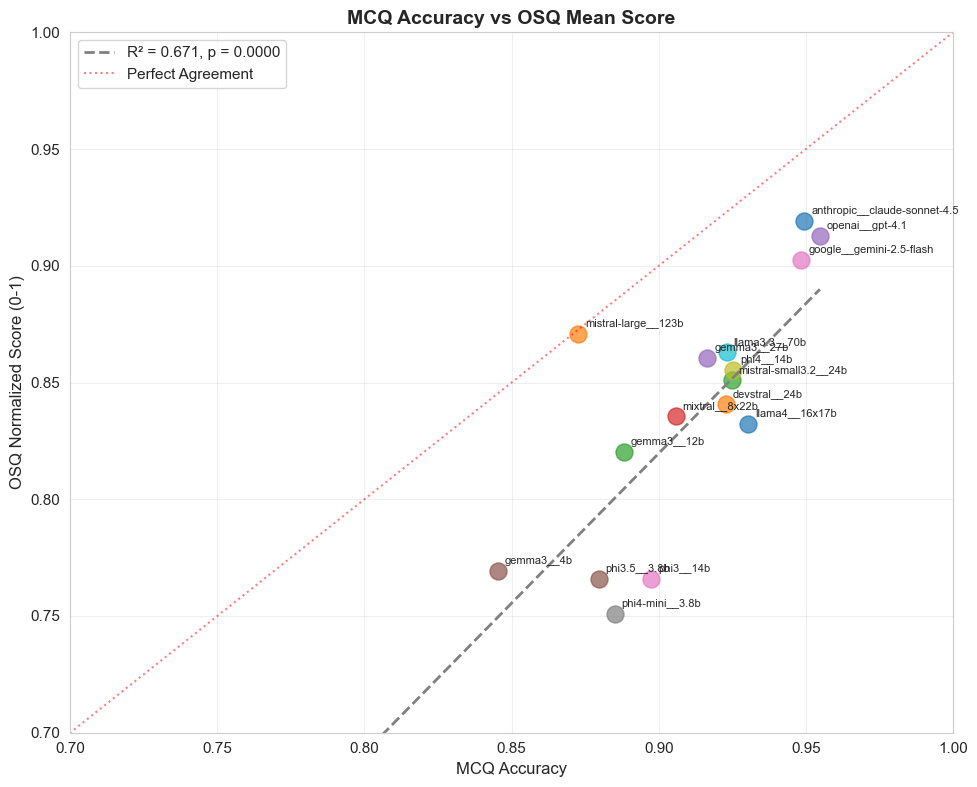

✅ Saved: output/mcq_vs_osq_scatter.png
   Correlation: R² = 0.6710, p = 0.0000
✅ Saved LaTeX table: output\table_mcq_osq_correlation.tex


In [8]:
# Plot 8: MCQ Accuracy vs OSQ Mean Score Scatter
if osq_available and len(aligned_df) > 0:
    print("\n" + "=" * 80)
    print("PLOT 8: MCQ Accuracy vs OSQ Mean Score")
    print("=" * 80)
    
    # Display judge and prompt information
    if 'judge_model' in aligned_df.columns and 'prompt_id' in aligned_df.columns:
        judges_used = aligned_df['judge_model'].dropna().unique()
        prompts_used = aligned_df['prompt_id'].dropna().unique()
        print(f"\n📋 Judge model(s) in comparison: {list(judges_used)}")
        print(f"📋 Prompt(s) in comparison: {list(prompts_used)}")
        if len(judges_used) > 1 or len(prompts_used) > 1:
            print("⚠️  WARNING: Multiple judges/prompts detected. Results aggregate across all.")
            print("   Consider filtering to a single judge/prompt for cleaner comparison.")
    
    # Aggregate by model
    comparison_df = aligned_df.groupby('model').agg(
        mcq_accuracy=('mcq_avg_correct', 'mean'),
        osq_mean=(('osq_total_score', 'mean')),
        osq_std=('osq_total_score', 'std'),
        n_samples=('model', 'count')
    ).reset_index()
    
    # Normalize OSQ to 0-1 scale for comparison
    comparison_df['osq_normalized'] = comparison_df['osq_mean'] / 100.0
    
    # Create scatter plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Scatter with model labels
    for _, row in comparison_df.iterrows():
        ax.scatter(row['mcq_accuracy'], row['osq_normalized'], s=150, alpha=0.7)
        ax.annotate(row['model'], (row['mcq_accuracy'], row['osq_normalized']),
                   xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Add regression line
    from scipy.stats import linregress
    slope, intercept, r_value, p_value, std_err = linregress(
        comparison_df['mcq_accuracy'], comparison_df['osq_normalized']
    )
    x_line = np.linspace(comparison_df['mcq_accuracy'].min(), comparison_df['mcq_accuracy'].max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'gray', linestyle='--', linewidth=2, 
        label=f'R² = {r_value**2:.3f}, p = {p_value:.4f}')
    
    # Add diagonal (perfect agreement)
    ax.plot([0, 1], [0, 1], 'red', linestyle=':', linewidth=1.5, alpha=0.5, label='Perfect Agreement')
    
    ax.set_xlabel('MCQ Accuracy', fontsize=12)
    ax.set_ylabel('OSQ Normalized Score (0-1)', fontsize=12)
    ax.set_title('MCQ Accuracy vs OSQ Mean Score', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.7, 1)
    ax.set_ylim(0.7, 1)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'mcq_vs_osq_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Saved: {output_dir}/mcq_vs_osq_scatter.png")
    print(f"   Correlation: R² = {r_value**2:.4f}, p = {p_value:.4f}")
    
    # Export correlation table
    corr_table = pd.DataFrame({
        'Metric': ['Pearson R', 'R²', 'p-value', 'Slope', 'Intercept'],
        'Value': [r_value, r_value**2, p_value, slope, intercept]
    }).set_index('Metric')
    
    export_latex_table(
        corr_table,
        'table_mcq_osq_correlation.tex',
        'MCQ vs OSQ Correlation Statistics',
        'tab:mcq_osq_correlation',
        column_format='lr'
    )
else:
    print("\n⚠️  Skipping Plot 8 (MCQ vs OSQ Scatter): Insufficient aligned data")
    print(f"   Current aligned samples: {len(aligned_df) if 'aligned_df' in locals() else 0}")

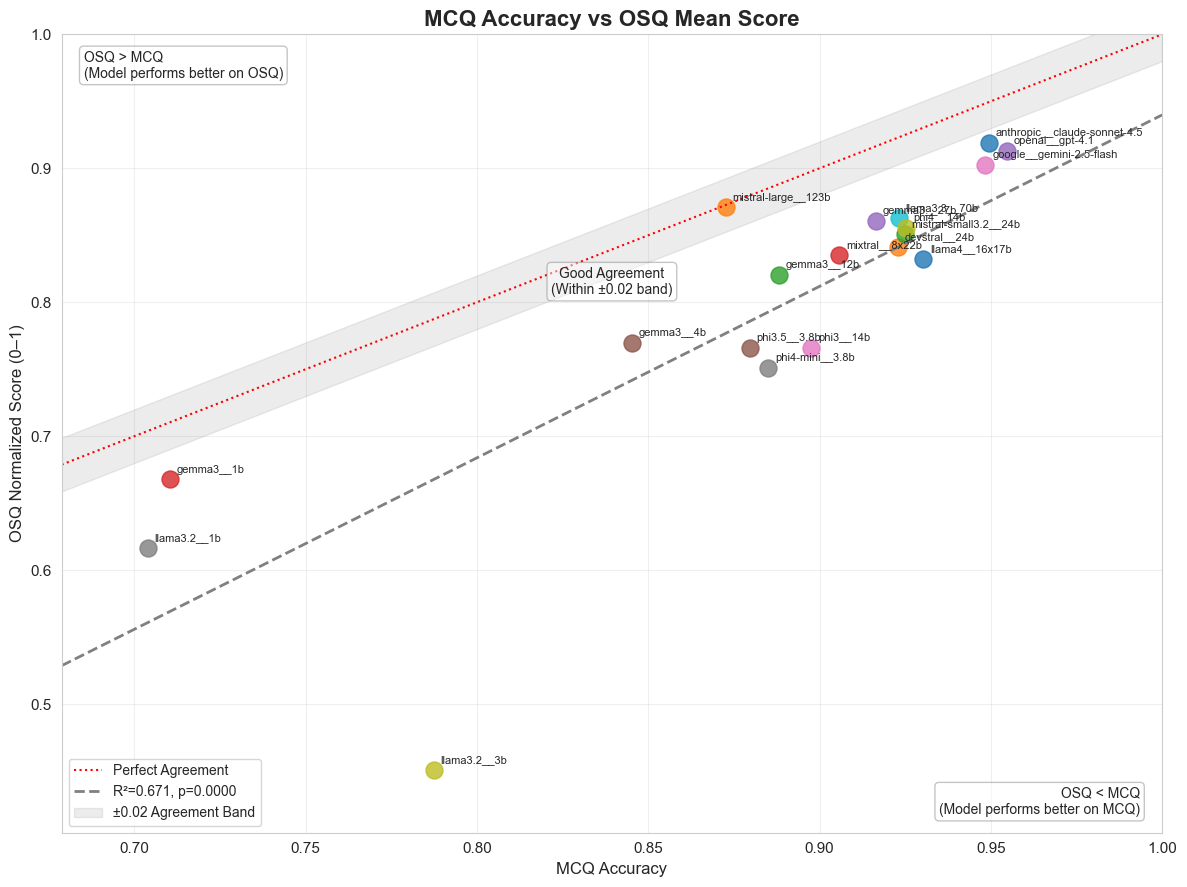

In [33]:
# -------------------------------
# PARAMETRIC CONFIGURATION
# -------------------------------
tolerance = 0.02             # ± tolerance band
label_box_alpha = 0.45
label_fontsize = 10

# -------------------------------
# DATA RANGE EXTRACTION
# -------------------------------
x_min = comparison_df['mcq_accuracy'].min()
x_max = comparison_df['mcq_accuracy'].max()
y_min = comparison_df['osq_normalized'].min()
y_max = comparison_df['osq_normalized'].max()

# Add small margins so points are not right against edges
x_pad = (x_max - x_min) * 0.1
y_pad = (y_max - y_min) * 0.1

x_lo = x_min - x_pad
# x_hi = x_max + x_pad
y_lo = y_min - y_pad
# y_hi = y_max + y_pad

# -------------------------------
# HARDCODE UPPER LIMITS TO 1.0
x_hi = 1.0
y_hi = 1.0

# -------------------------------
# REGION CLASSIFICATION
# -------------------------------
comparison_df['agreement_diff'] = comparison_df['osq_normalized'] - comparison_df['mcq_accuracy']

def classify_region(diff, tol):
    if diff > tol:
        return "OSQ > MCQ"
    elif diff < -tol:
        return "OSQ < MCQ"
    else:
        return "Good Agreement"

comparison_df['region'] = comparison_df['agreement_diff'].apply(lambda d: classify_region(d, tolerance))

# -------------------------------
# BUILD PLOT
# -------------------------------
fig, ax = plt.subplots(figsize=(12, 9))

# Diagonal line (perfect agreement)
ax.plot(
    [x_lo, x_hi],
    [x_lo, x_hi],
    color='red',
    linestyle=':',
    linewidth=1.5,
    label="Perfect Agreement"
)

# -------------------------------
# EXTENDED REGRESSION LINE (FULL AXIS SPAN)
# -------------------------------
x_reg = np.linspace(x_lo, x_hi, 300)       # use plot limits, not data limits
y_reg = slope * x_reg + intercept          # full-span regression

ax.plot(
    x_reg,
    y_reg,
    color='gray',
    linestyle='--',
    linewidth=2,
    label=f"R²={r_value**2:.3f}, p={p_value:.4f}"
)


# Tolerance band (parametric)
x_vals = np.linspace(x_lo, x_hi, 300)
ax.fill_between(
    x_vals,
    x_vals - tolerance,
    x_vals + tolerance,
    color='gray',
    alpha=0.15,
    label=f"±{tolerance:.02f} Agreement Band"
)

# Scatter points (original colors preserved)
for _, row in comparison_df.iterrows():
    ax.scatter(
        row['mcq_accuracy'],
        row['osq_normalized'],
        s=150, alpha=0.8
    )
    ax.annotate(
        row['model'],
        (row['mcq_accuracy'], row['osq_normalized']),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

# -------------------------------
# CORRECTED PARAMETRIC REGION LABEL PLACEMENT
# -------------------------------

# Midpoint of the diagonal segment that fits the data range
x_mid = (x_lo + x_hi) / 2
y_mid = x_mid   # perfect agreement line

# Slight downward offset so the label is visible above the band
agreement_y = y_mid - (tolerance * 1.2)

# TOP region label (OSQ > MCQ)
ax.text(
    x_lo + 0.02 * (x_hi - x_lo),
    y_hi - 0.02 * (y_hi - y_lo),
    "OSQ > MCQ\n(Model performs better on OSQ)",
    ha='left', va='top',
    fontsize=label_fontsize,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=label_box_alpha)
)

# CENTER region label (Good Agreement)
ax.text(
    x_mid,
    agreement_y,
    f"Good Agreement\n(Within ±{tolerance:.02f} band)",
    ha='center', va='center',
    fontsize=label_fontsize,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=label_box_alpha)
)

# BOTTOM region label (OSQ < MCQ)
ax.text(
    x_hi - 0.02 * (x_hi - x_lo),
    y_lo + 0.02 * (y_hi - y_lo),
    "OSQ < MCQ\n(Model performs better on MCQ)",
    ha='right', va='bottom',
    fontsize=label_fontsize,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=label_box_alpha)
)


# -------------------------------
# FINAL STYLING
# -------------------------------
ax.set_xlabel("MCQ Accuracy", fontsize=12)
ax.set_ylabel("OSQ Normalized Score (0–1)", fontsize=12)
ax.set_title("MCQ Accuracy vs OSQ Mean Score", fontsize=16, fontweight="bold")

ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)



ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "mcq_vs_osq_scatter_regions.png", dpi=300, bbox_inches="tight")
plt.show()


#### Plot 8A: MCQ Accuracy vs OSQ Rubric Dimensions (Corrected for OSQ data structure)


PLOT 8A: MCQ Accuracy vs OSQ Rubric Dimensions

📊 Creating scatter plot: Technical Accuracy


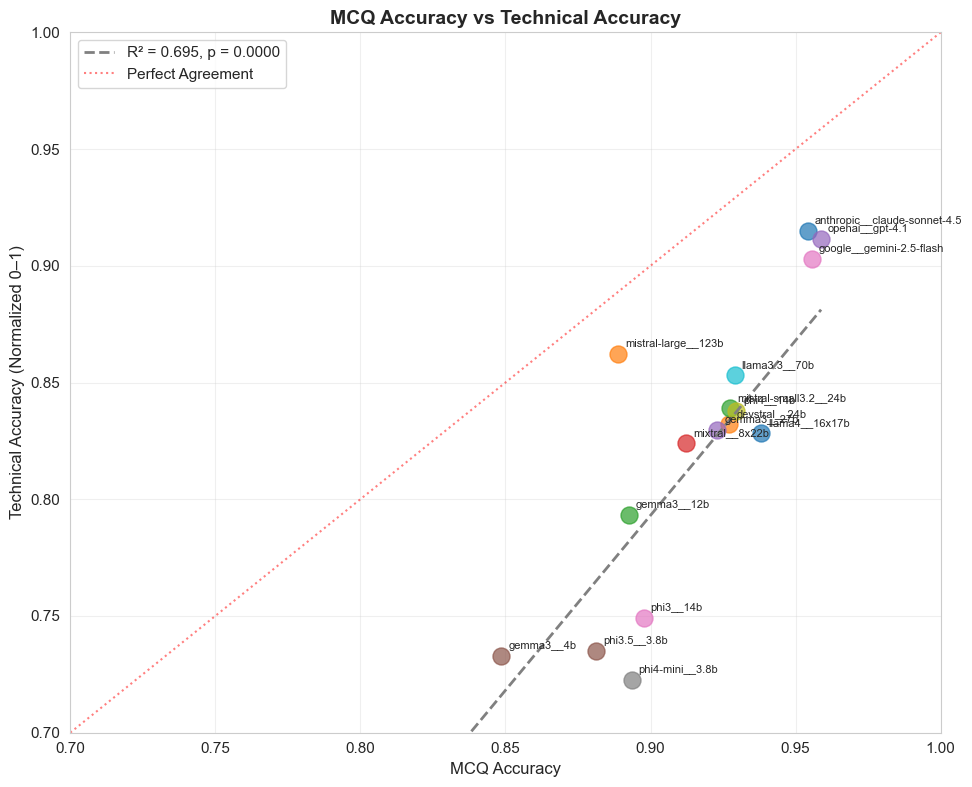

✅ Saved: output\mcq_vs_osq_osq_technical_accuracy.png

📊 Creating scatter plot: Conceptual Understanding


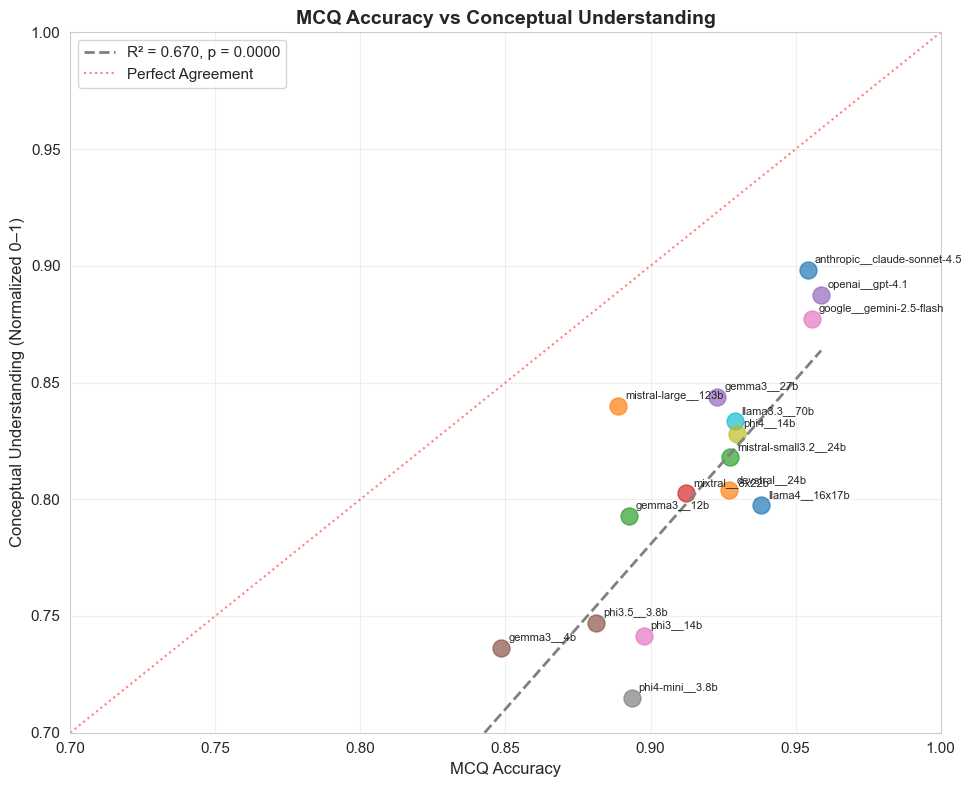

✅ Saved: output\mcq_vs_osq_osq_conceptual_understanding.png

📊 Creating scatter plot: Completeness


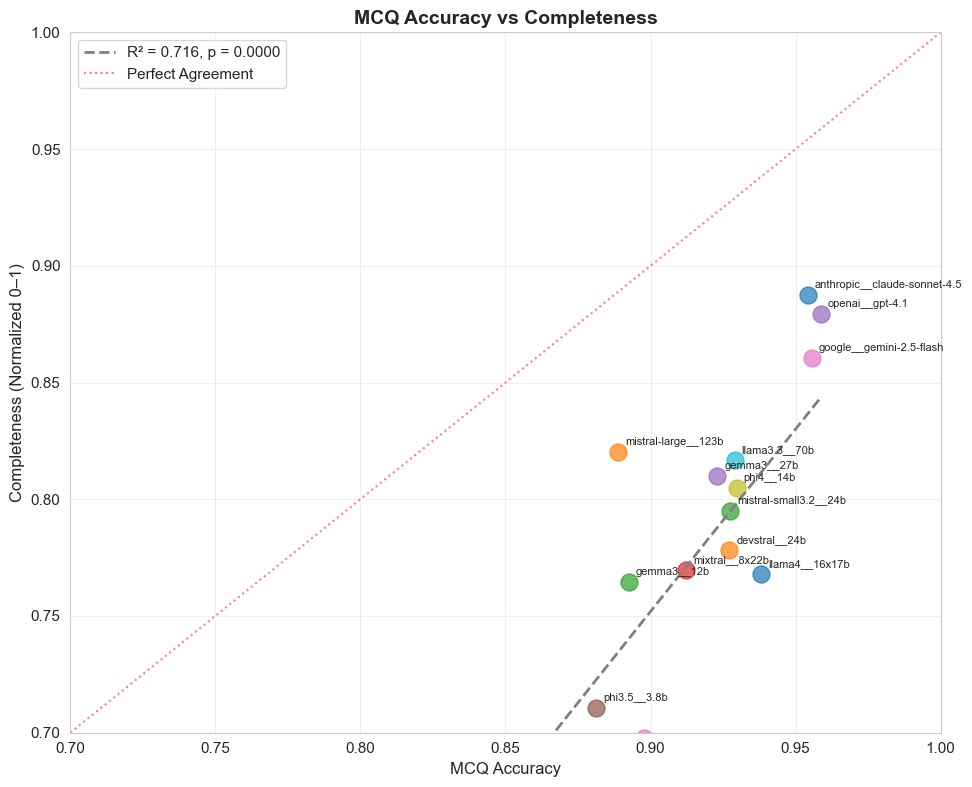

✅ Saved: output\mcq_vs_osq_osq_completeness.png

📊 Creating scatter plot: Clarity & Organization


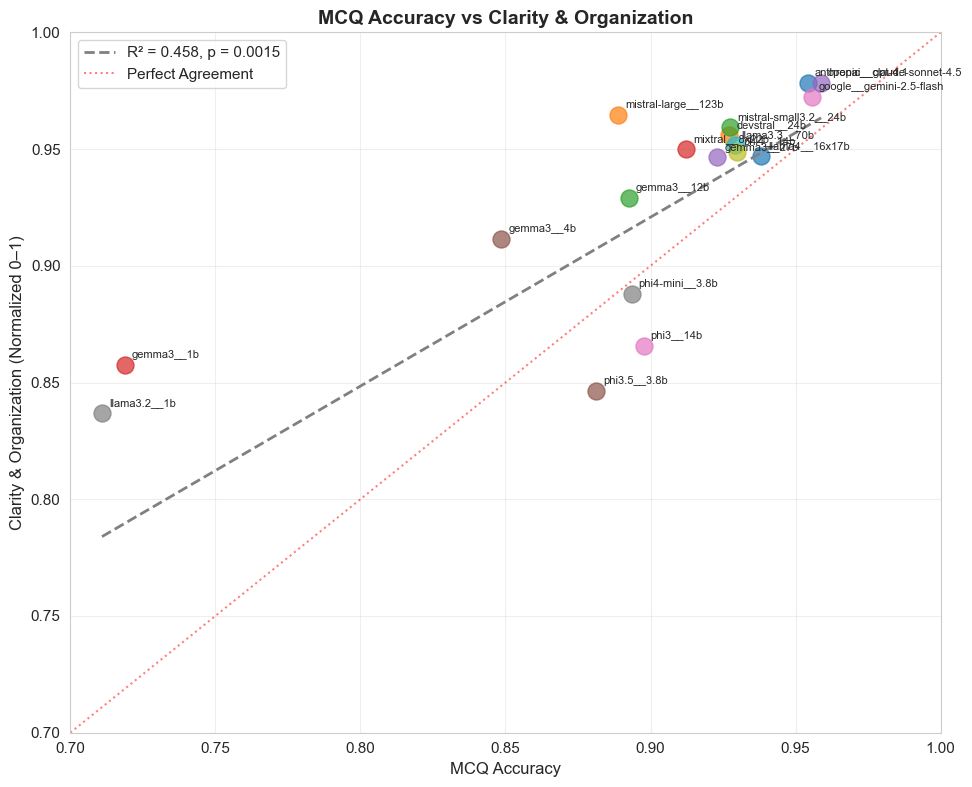

✅ Saved: output\mcq_vs_osq_osq_clarity_organization.png

📊 Creating scatter plot: Professional Relevance


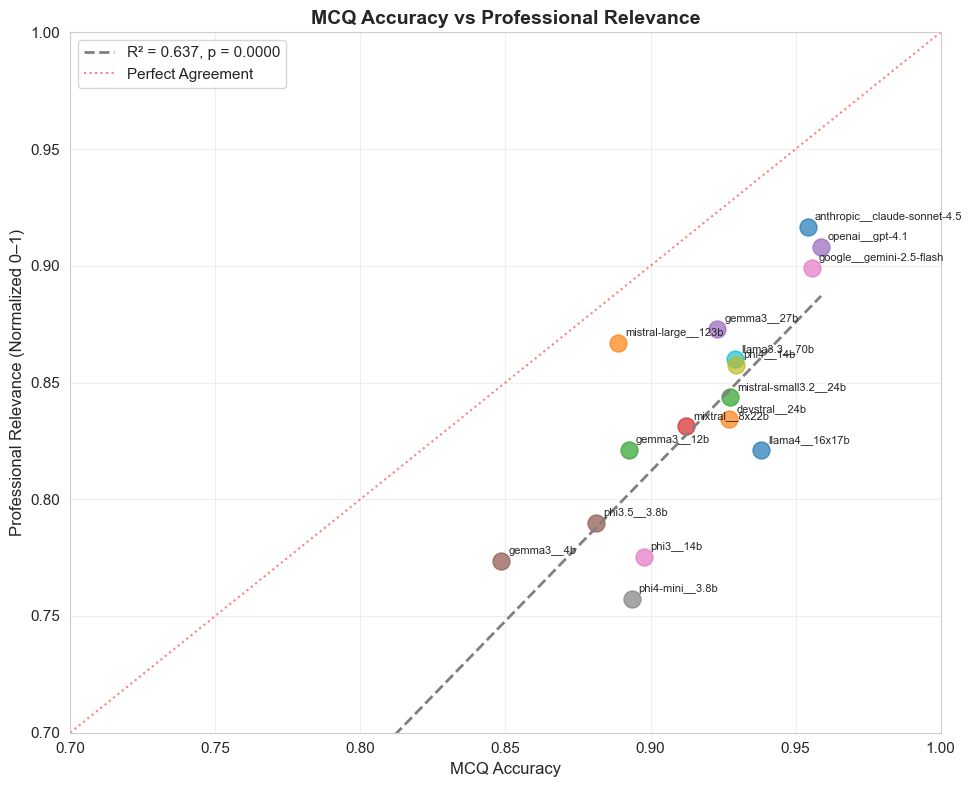

✅ Saved: output\mcq_vs_osq_osq_professional_relevance.png
✅ Saved LaTeX table: output\table_mcq_osq_rubric_correlation.tex

📄 Summary table exported.


In [13]:
# Plot 8A: MCQ Accuracy vs OSQ Rubric Dimensions (Corrected for OSQ data structure)
if osq_available and len(aligned_df) > 0:
    print("\n" + "=" * 80)
    print("PLOT 8A: MCQ Accuracy vs OSQ Rubric Dimensions")
    print("=" * 80)

    # OSQ rubric fields (as they appear in aligned_df)
    rubric_fields = [
        ("osq_technical_accuracy", "Technical Accuracy"),
        ("osq_conceptual_understanding", "Conceptual Understanding"),
        ("osq_completeness", "Completeness"),
        ("osq_clarity_organization", "Clarity & Organization"),
        ("osq_professional_relevance", "Professional Relevance")
    ]

    # Filter to OSQ rows only (exclude MCQ-only rows)
    osq_rows = aligned_df.dropna(subset=[col for col, _ in rubric_fields], how="all")

    # Correlation summary table
    summary_records = []

    for col, label in rubric_fields:

        # Keep only rows where this rubric score exists
        valid = osq_rows.dropna(subset=[col]).copy()

        if len(valid) < 3:
            print(f"⚠️  Skipping {label} — insufficient data")
            continue

        print(f"\n📊 Creating scatter plot: {label}")

        # Compute model-level aggregation
        comp_df = valid.groupby("model").agg(
            mcq_accuracy=("mcq_avg_correct", "mean"),
            osq_raw=(col, "mean")    # rubric dimension 0–20
        ).reset_index()

        # Normalize rubric score from 0–20 to 0–1
        comp_df["osq_norm"] = comp_df["osq_raw"] / 20.0

        # --- Scatter plot ---
        fig, ax = plt.subplots(figsize=(10, 8))

        for _, row in comp_df.iterrows():
            ax.scatter(row["mcq_accuracy"], row["osq_norm"], s=150, alpha=0.7)
            ax.annotate(
                row["model"],
                (row["mcq_accuracy"], row["osq_norm"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8
            )

        # Regression line
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(
            comp_df["mcq_accuracy"], comp_df["osq_norm"]
        )

        x_line = np.linspace(comp_df["mcq_accuracy"].min(), comp_df["mcq_accuracy"].max(), 100)
        y_line = slope * x_line + intercept

        ax.plot(x_line, y_line, "gray", linestyle="--", linewidth=2,
                label=f"R² = {r_value**2:.3f}, p = {p_value:.4f}")

        # Perfect agreement line
        ax.plot([0, 1], [0, 1], "red", linestyle=":", linewidth=1.5, alpha=0.5,
                label="Perfect Agreement")

        ax.set_xlabel("MCQ Accuracy", fontsize=12)
        ax.set_ylabel(f"{label} (Normalized 0–1)", fontsize=12)
        ax.set_title(f"MCQ Accuracy vs {label}", fontsize=14, fontweight="bold")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0.7, 1)
        ax.set_ylim(0.7, 1)   # rubric dimensions are 0–20 → 0–1 normalized

        plt.tight_layout()

        save_path = output_dir / f"mcq_vs_osq_{col}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

        print(f"✅ Saved: {save_path}")

        summary_records.append({
            "Dimension": label,
            "Pearson R": r_value,
            "R²": r_value**2,
            "p-value": p_value,
            "Slope": slope,
            "Intercept": intercept
        })

    # Export summary table
    if len(summary_records) > 0:
        summary_df = pd.DataFrame(summary_records).set_index("Dimension")
        export_latex_table(
            summary_df,
            "table_mcq_osq_rubric_correlation.tex",
            "MCQ vs OSQ Rubric-Dimension Correlation Statistics",
            "tab:mcq_osq_rubric_corr",
            column_format="lrrrrr"
        )
        print("\n📄 Summary table exported.")
    else:
        print("\n⚠️  No valid rubric dimensions available for correlation.")

else:
    print("\n⚠️  Skipping Plot 8A: Insufficient aligned data")



PLOT 8B: MCQ Accuracy vs OSQ Rubric Dimensions (Multi-Panel)


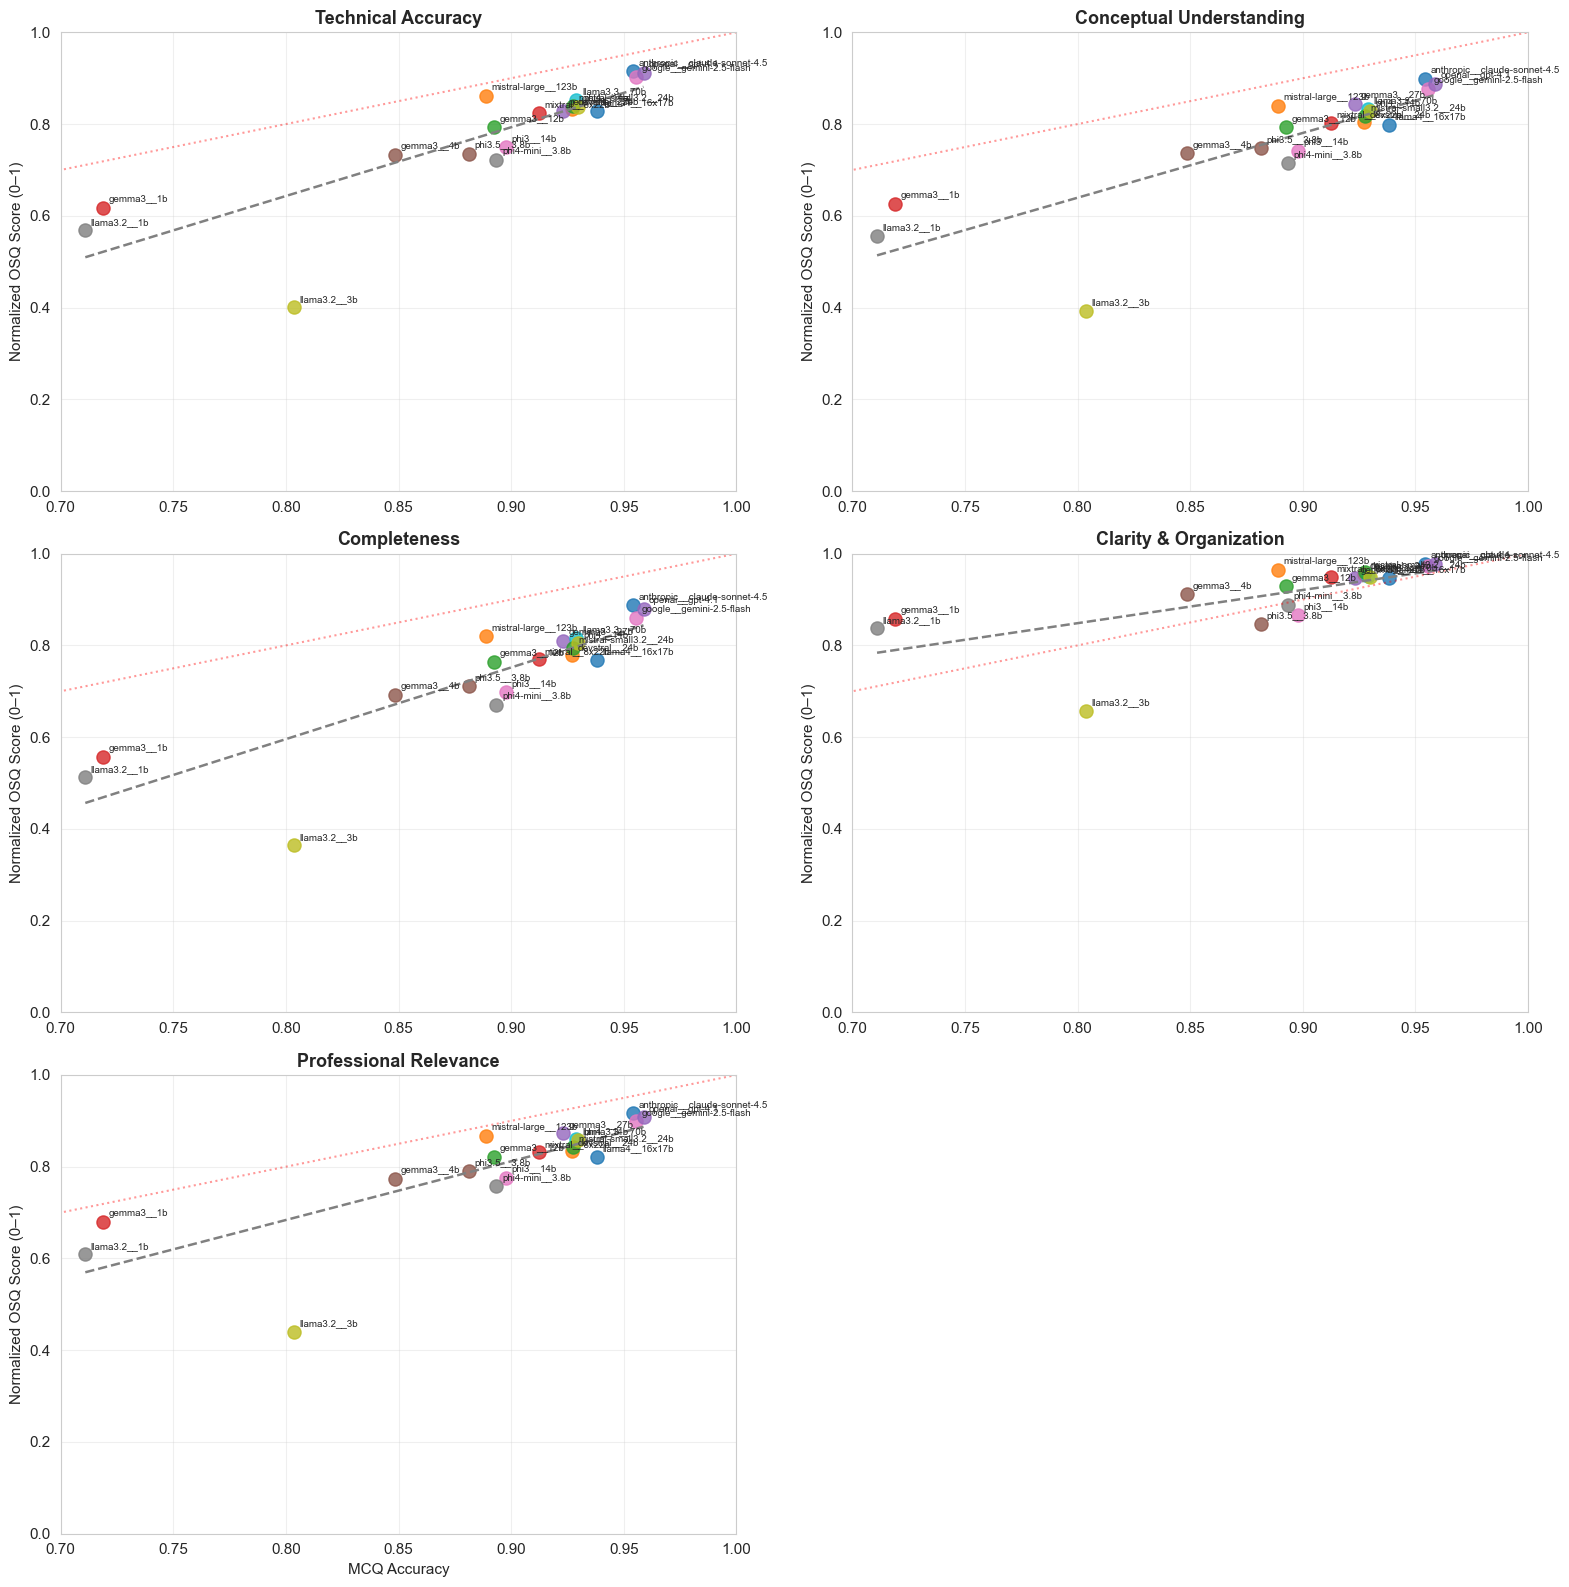

✅ Saved multi-panel plot: output\mcq_vs_osq_rubric_multipanel.png
✅ Saved LaTeX table: output\table_mcq_osq_rubric_correlation.tex


In [14]:
# Plot 8B: MCQ Accuracy vs OSQ Rubric Dimensions (Multi-Panel Single Figure)

if osq_available and len(aligned_df) > 0:
    print("\n" + "=" * 80)
    print("PLOT 8B: MCQ Accuracy vs OSQ Rubric Dimensions (Multi-Panel)")
    print("=" * 80)

    rubric_fields = [
        ("osq_technical_accuracy", "Technical Accuracy"),
        ("osq_conceptual_understanding", "Conceptual Understanding"),
        ("osq_completeness", "Completeness"),
        ("osq_clarity_organization", "Clarity & Organization"),
        ("osq_professional_relevance", "Professional Relevance")
    ]

    # Filter to OSQ-only rows
    osq_rows = aligned_df.dropna(subset=[col for col, _ in rubric_fields], how="all")

    # Multi-panel layout: 3 rows × 2 columns (last cell empty)
    fig, axes = plt.subplots(3, 2, figsize=(16, 16))
    axes = axes.flatten()

    summary_records = []
    panel_idx = 0

    for col, label in rubric_fields:

        valid = osq_rows.dropna(subset=[col]).copy()

        if len(valid) < 3:
            print(f"⚠️  Skipping {label}: insufficient samples")
            panel_idx += 1
            continue

        comp_df = valid.groupby("model").agg(
            mcq_accuracy=("mcq_avg_correct", "mean"),
            osq_norm=(col, lambda x: x.mean() / 20.0)
        ).reset_index()

        ax = axes[panel_idx]
        panel_idx += 1

        # Scatter + labels
        for _, row in comp_df.iterrows():
            ax.scatter(row["mcq_accuracy"], row["osq_norm"], s=90, alpha=0.8)
            ax.annotate(row["model"], (row["mcq_accuracy"], row["osq_norm"]),
                        xytext=(4, 4), textcoords="offset points", fontsize=7)

        # Regression
        from scipy.stats import linregress
        slope, intercept, r_val, p_val, _ = linregress(
            comp_df["mcq_accuracy"], comp_df["osq_norm"]
        )

        x_line = np.linspace(comp_df["mcq_accuracy"].min(),
                             comp_df["mcq_accuracy"].max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, "gray", linestyle="--", linewidth=1.8,
                label=f"R²={r_val**2:.3f}, p={p_val:.4f}")

        # Perfect agreement line
        ax.plot([0, 1], [0, 1], "r:", alpha=0.4)

        ax.set_title(label, fontsize=13, fontweight="bold")
        ax.set_xlim(0.7, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

        if panel_idx > 4:
            ax.set_xlabel("MCQ Accuracy")
        ax.set_ylabel("Normalized OSQ Score (0–1)")

        summary_records.append({
            "Dimension": label,
            "Pearson R": r_val,
            "R²": r_val**2,
            "p-value": p_val,
            "Slope": slope,
            "Intercept": intercept
        })

    # Hide last empty panel (6th panel)
    axes[-1].axis("off")

    plt.tight_layout()
    save_path = output_dir / "mcq_vs_osq_rubric_multipanel.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✅ Saved multi-panel plot: {save_path}")

    # Export correlation summary
    summary_df = pd.DataFrame(summary_records).set_index("Dimension")
    export_latex_table(
        summary_df,
        "table_mcq_osq_rubric_correlation.tex",
        "MCQ vs OSQ Rubric-Dimension Correlation Statistics",
        "tab:mcq_osq_rubric_corr",
        column_format="lrrrrr"
    )

else:
    print("\n⚠️  Skipping Plot 8B: insufficient data")



PLOT 8C: Unified MCQ vs OSQ Rubric Scatterplot


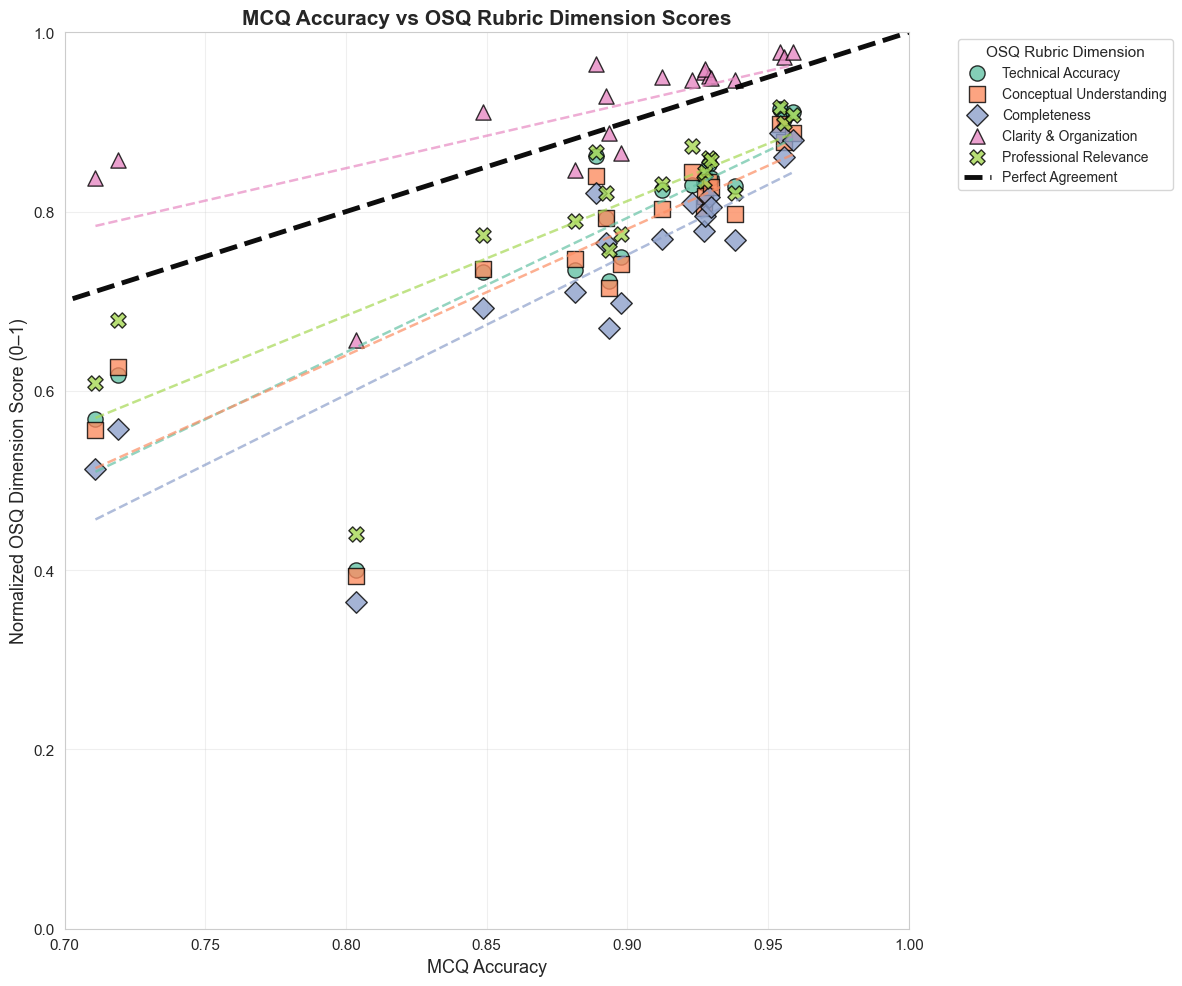

✅ Saved: output\mcq_vs_osq_rubric_combined.png
✅ Saved LaTeX table: output\table_mcq_osq_rubric_correlation.tex


In [19]:
# Plot 8C: MCQ Accuracy vs OSQ Rubric Dimensions (Single Compressed Plot)
if osq_available and len(aligned_df) > 0:
    print("\n" + "=" * 80)
    print("PLOT 8C: Unified MCQ vs OSQ Rubric Scatterplot")
    print("=" * 80)

    rubric_fields = [
        ("osq_technical_accuracy", "Technical Accuracy"),
        ("osq_conceptual_understanding", "Conceptual Understanding"),
        ("osq_completeness", "Completeness"),
        ("osq_clarity_organization", "Clarity & Organization"),
        ("osq_professional_relevance", "Professional Relevance")
    ]

    # Filter to rows with at least one OSQ score
    osq_rows = aligned_df.dropna(
        subset=[col for col, _ in rubric_fields], 
        how="all"
    ).copy()

    # Color + marker style for each dimension
    palette = sns.color_palette("Set2", n_colors=5)
    markers = ["o", "s", "D", "^", "X"]  # circles, squares, diamonds, triangles, crosses

    fig, ax = plt.subplots(figsize=(12, 10))

    summary_records = []

    for (col, label), color, marker in zip(rubric_fields, palette, markers):

        # Only use rows *with* this rubric dimension
        valid = osq_rows.dropna(subset=[col]).copy()
        if len(valid) < 3:
            print(f"⚠️  Skipping {label}: insufficient OSQ samples")
            continue

        # Aggregate by model
        comp_df = valid.groupby("model").agg(
            mcq_accuracy=("mcq_avg_correct", "mean"),
            osq_norm=(col, lambda x: x.mean() / 20.0)  # normalize from 20 → 1
        ).reset_index()

        # Scatter points
        ax.scatter(
            comp_df["mcq_accuracy"],
            comp_df["osq_norm"],
            label=label,
            s=120,
            alpha=0.8,
            color=color,
            marker=marker,
            edgecolor="black"
        )

        # Regression line (optional)
        from scipy.stats import linregress
        slope, intercept, r_val, p_val, _ = linregress(
            comp_df["mcq_accuracy"], comp_df["osq_norm"]
        )

        x_line = np.linspace(
            comp_df["mcq_accuracy"].min(),
            comp_df["mcq_accuracy"].max(),
            100
        )
        y_line = slope * x_line + intercept

        ax.plot(
            x_line, y_line,
            linestyle="--",
            linewidth=1.8,
            color=color,
            alpha=0.7
        )

        # Store stats for table
        summary_records.append({
            "Dimension": label,
            "Pearson R": r_val,
            "R²": r_val**2,
            "p-value": p_val,
            "Slope": slope,
            "Intercept": intercept
        })

    # Perfect agreement diagonal
    ax.plot(
        [0, 1], [0, 1],
        color="black",        # fully dark line
        linestyle="--",        # dotted
        linewidth=3.5,        # much thicker
        alpha=0.95,           # strong opacity
        label="Perfect Agreement"
    )


    ax.set_xlabel("MCQ Accuracy", fontsize=13)
    ax.set_ylabel("Normalized OSQ Dimension Score (0–1)", fontsize=13)
    ax.set_title("MCQ Accuracy vs OSQ Rubric Dimension Scores", fontsize=15, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.set_xlim(0.7, 1.0)
    ax.set_ylim(0.0, 1.0)

    plt.legend(title="OSQ Rubric Dimension", fontsize=10, title_fontsize=11, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    save_path = output_dir / "mcq_vs_osq_rubric_combined.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✅ Saved: {save_path}")

    # Export correlation summary
    if len(summary_records) > 0:
        summary_df = pd.DataFrame(summary_records).set_index("Dimension")

        export_latex_table(
            summary_df,
            "table_mcq_osq_rubric_correlation.tex",
            "MCQ vs OSQ Rubric-Dimension Correlation Statistics",
            "tab:mcq_osq_rubric_corr",
            column_format="lrrrrr"
        )
else:
    print("\n⚠️  Skipping Plot 8C: Insufficient data")



PLOT 8: MCQ Accuracy vs OSQ Mean Score (KMeans Clustering)

📋 Judge model(s) in comparison: ['openai_gpt-5-mini']
📋 Prompt(s) in comparison: ['p1']


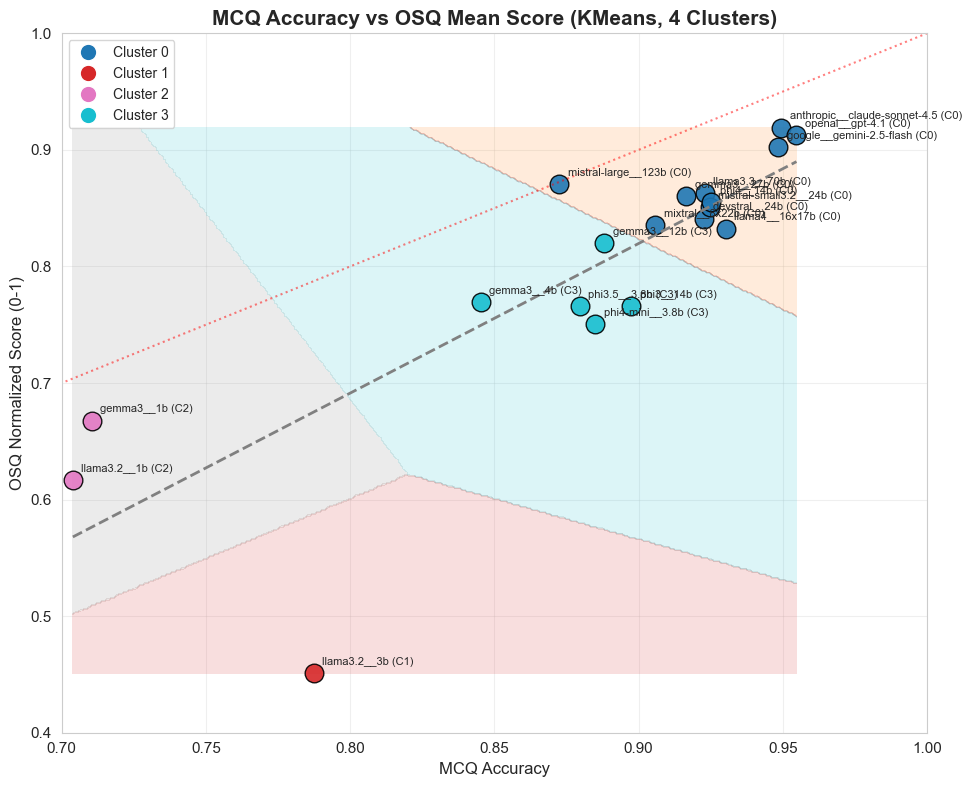

✅ Saved: output/mcq_vs_osq_scatter.png
   Correlation: R² = 0.6710, p = 0.0000
✅ Saved LaTeX table: output\table_mcq_osq_correlation.tex


In [17]:
# Plot 8: MCQ Accuracy vs OSQ Mean Score Scatter WITH KMEANS CLUSTERING (MANUAL N CLUSTERS)
if osq_available and len(aligned_df) > 0:
    print("\n" + "=" * 80)
    print("PLOT 8: MCQ Accuracy vs OSQ Mean Score (KMeans Clustering)")
    print("=" * 80)

    # Display judge and prompt information
    if 'judge_model' in aligned_df.columns and 'prompt_id' in aligned_df.columns:
        judges_used = aligned_df['judge_model'].dropna().unique()
        prompts_used = aligned_df['prompt_id'].dropna().unique()
        print(f"\n📋 Judge model(s) in comparison: {list(judges_used)}")
        print(f"📋 Prompt(s) in comparison: {list(prompts_used)}")
        if len(judges_used) > 1 or len(prompts_used) > 1:
            print("⚠️  WARNING: Multiple judges/prompts detected. Results aggregate across all.")
            print("   Consider filtering to a single judge/prompt for cleaner comparison.")

    # ------------------------------------------------------------------
    # Aggregate by model
    # ------------------------------------------------------------------
    comparison_df = aligned_df.groupby('model').agg(
        mcq_accuracy=('mcq_avg_correct', 'mean'),
        osq_mean=('osq_total_score', 'mean'),
        osq_std=('osq_total_score', 'std'),
        n_samples=('model', 'count')
    ).reset_index()

    # Normalize OSQ to 0-1 scale
    comparison_df['osq_normalized'] = comparison_df['osq_mean'] / 100.0

    # ------------------------------------------------------------------
    # KMEANS CLUSTERING (MANUAL N_CLUSTERS)
    # ------------------------------------------------------------------
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    import numpy as np

    X = comparison_df[['mcq_accuracy', 'osq_normalized']].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # <<< CHANGE THIS TO THE NUMBER OF CLUSTERS YOU WANT >>>
    n_clusters = 4  # e.g., 3, 4, 5, ...

    kmeans = KMeans(
        n_clusters=n_clusters,
        n_init=20,
        random_state=42
    )
    cluster_labels = kmeans.fit_predict(X_scaled)
    comparison_df['cluster'] = cluster_labels

    # ------------------------------------------------------------------
    # SCATTER PLOT + CLUSTER REGIONS
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 8))

    # Decision regions over a meshgrid
    xx, yy = np.meshgrid(
        np.linspace(comparison_df['mcq_accuracy'].min(), comparison_df['mcq_accuracy'].max(), 300),
        np.linspace(comparison_df['osq_normalized'].min(), comparison_df['osq_normalized'].max(), 300)
    )
    grid = np.vstack([xx.ravel(), yy.ravel()]).T
    grid_scaled = scaler.transform(grid)

    Z = kmeans.predict(grid_scaled)
    ax.contourf(xx, yy, Z.reshape(xx.shape),
                levels=n_clusters, alpha=0.15, cmap='tab10')

    # Colors for clusters
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    # Scatter with cluster colors
    for _, row in comparison_df.iterrows():
        ax.scatter(
            row['mcq_accuracy'],
            row['osq_normalized'],
            s=180,
            alpha=0.9,
            color=colors[row['cluster']],
            edgecolor='black'
        )
        ax.annotate(
            f"{row['model']} (C{row['cluster']})",
            (row['mcq_accuracy'], row['osq_normalized']),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=8
        )

    # ------------------------------------------------------------------
    # Regression line
    # ------------------------------------------------------------------
    from scipy.stats import linregress
    slope, intercept, r_value, p_value, std_err = linregress(
        comparison_df['mcq_accuracy'], comparison_df['osq_normalized']
    )
    x_line = np.linspace(comparison_df['mcq_accuracy'].min(), comparison_df['mcq_accuracy'].max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(
        x_line, y_line,
        linestyle='--', linewidth=2,
        color='gray',
        label=f'R² = {r_value**2:.3f}, p = {p_value:.4f}'
    )

    # Perfect agreement diagonal
    ax.plot(
        [0, 1], [0, 1],
        linestyle=':', linewidth=1.5,
        color='red', alpha=0.5,
        label='Perfect Agreement'
    )

    # Axis labels & formatting
    ax.set_xlabel('MCQ Accuracy', fontsize=12)
    ax.set_ylabel('OSQ Normalized Score (0-1)', fontsize=12)
    ax.set_title(
        f'MCQ Accuracy vs OSQ Mean Score (KMeans, {n_clusters} Clusters)',
        fontsize=15, fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.7, 1)
    ax.set_ylim(0.4, 1)

    # Cluster legend
    from matplotlib.lines import Line2D
    cluster_legend = [
        Line2D(
            [0], [0],
            marker='o', color='w',
            label=f"Cluster {i}",
            markerfacecolor=colors[i],
            markersize=12
        )
        for i in range(n_clusters)
    ]
    existing_legend = ax.get_legend()
    existing_handles = existing_legend.legendHandles if existing_legend else []

    ax.legend(handles=cluster_legend + existing_handles, fontsize=10)


    plt.tight_layout()
    plt.savefig(output_dir / 'mcq_vs_osq_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Saved: {output_dir}/mcq_vs_osq_scatter.png")
    print(f"   Correlation: R² = {r_value**2:.4f}, p = {p_value:.4f}")

    # ------------------------------------------------------------------
    # Export correlation table (unchanged)
    # ------------------------------------------------------------------
    corr_table = pd.DataFrame({
        'Metric': ['Pearson R', 'R²', 'p-value', 'Slope', 'Intercept'],
        'Value': [r_value, r_value**2, p_value, slope, intercept]
    }).set_index('Metric')

    export_latex_table(
        corr_table,
        'table_mcq_osq_correlation.tex',
        'MCQ vs OSQ Correlation Statistics',
        'tab:mcq_osq_correlation',
        column_format='lr'
    )

else:
    print("\n⚠️  Skipping Plot 8 (MCQ vs OSQ Scatter): Insufficient aligned data")
    print(f"   Current aligned samples: {len(aligned_df) if 'aligned_df' in locals() else 0}")


## TODO: Consider adding a temporal nature to above -- when the model was created OR their sizes.

## TODO: same as the plot above, but with each of the fields call ed out explicitely so we can attribute the cause to technical performance or otherwise.
      "technical_accuracy": {"score": 19, "justification": "..."},
      "conceptual_understanding": {"score": 19, "justification": "..."},
      "completeness": {"score": 18, "justification": "..."},
      "clarity_organization": {"score": 18, "justification": "..."},
      "professional_relevance": {"score": 20, "justification": "..."}

In [82]:
# Plot 3: MCQ Accuracy vs OSQ Mean Score
# This plot will work when OSQ judged data is available
# Currently adapting to use aggregated data structure

# Try to load OSQ data if available
try:
    print("📊 Loading OSQ judged samples...")
    print("📊 Loading OSQ judged samples...")
    osq_data = parse_osq_judged_samples(phase5_dir)
    osq_df = pd.DataFrame(osq_data)
    
    # Align MCQ and OSQ data
    aligned_df = align_mcq_osq_results(mcq_df, osq_df)
    
    if len(aligned_df) > 0:
        # Aggregate by model: MCQ accuracy vs OSQ mean score
        agg = aligned_df.groupby('model').agg(
            mcq_accuracy=('mcq_correct', 'mean'),
            osq_mean=('osq_score', 'mean'),
            osq_std=('osq_score', 'std'),
            n_samples=('mcq_correct', 'count')
        ).reset_index()
        
        # Create scatter plot
        fig, ax = plt.subplots(figsize=(10, 7))
        
        # Scatter plot with model labels
        for _, row in agg.iterrows():
            ax.scatter(row['mcq_accuracy'], row['osq_mean'], s=150, alpha=0.7)
            ax.text(row['mcq_accuracy'] + 0.01, row['osq_mean'], row['model'], 
                   fontsize=9, ha='left', va='center')
        
        # Add regression line
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(agg['mcq_accuracy'], agg['osq_mean'])
        x_line = np.array([agg['mcq_accuracy'].min(), agg['mcq_accuracy'].max()])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'gray', linestyle='--', label=f'R² = {r_value**2:.3f}')
        ax.plot(x_line, y_line, 'gray', linestyle='--', label=f'R² = {r_value**2:.3f}')
        
        ax.set_xlabel("MCQ Accuracy", fontsize=12)
        ax.set_ylabel("OSQ Mean Score (0-100)", fontsize=12)
        ax.set_title("MCQ Accuracy vs OSQ Mean Score", fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('outputs/plot3_mcq_vs_osq_scatter.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Saved: outputs/plot3_mcq_vs_osq_scatter.png")
        print(f"✅ Saved: outputs/plot3_mcq_vs_osq_scatter.png")
        print(f"   Models plotted: {len(agg)}")
        print(f"   Correlation: R² = {r_value**2:.3f}, p = {p_value:.4f}")
        print(f"   Correlation: R² = {r_value**2:.3f}, p = {p_value:.4f}")
    else:
        print("⚠️  No aligned MCQ-OSQ data available yet.")
        print("⚠️  No aligned MCQ-OSQ data available yet.")
        print("   Placeholder plot will be ready when OSQ judging is complete.")
        
except Exception as e:
    print(f"⚠️  Could not load OSQ data: {e}")
    print(f"⚠️  Could not load OSQ data: {e}")
    print("   Plot 3 will be generated when OSQ judging data is available.")

📊 Loading OSQ judged samples...
📊 Loading OSQ judged samples...
📖 Parsing anthropic__claude-sonnet-4.5/samples_sysengbench-osq_2025-11-16T21-02-49.453852__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, prompt: p1)
   ⚠️  Error processing line 4: 'NoneType' object has no attribute 'get'
   ⚠️  Error processing line 148: 'NoneType' object has no attribute 'get'
   ⚠️  Error processing line 748: 'NoneType' object has no attribute 'get'
📖 Parsing devstral__24b/samples_sysengbench-osq_2025-11-19T22-36-33.281032__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, prompt: p1)


   ⚠️  Error processing line 207: 'NoneType' object has no attribute 'get'
📖 Parsing gemma3__12b/samples_sysengbench-osq_2025-11-19T22-23-32.102126__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, prompt: p1)
   ⚠️  Error processing line 501: 'NoneType' object has no attribute 'get'
📖 Parsing gemma3__27b/samples_sysengbench-osq_2025-11-15T01-24-12.251073__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, prompt: p1)
📖 Parsing google__gemini-2.5-flash/samples_sysengbench-osq_2025-11-16T04-10-37.215910__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, prompt: p1)
📖 Parsing llama3.2__3b/samples_sysengbench-osq_2025-11-19T21-47-50.052256__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, prompt: p1)
📖 Parsing llama3.3__70b/samples_sysengbench-osq_2025-11-14T23-24-28.915214__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, prompt: p1)
📖 Parsing llama4__16x17b/samples_sysengbench-osq_2025-11-14T23-18-06.136162__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, pro


PLOT 3: Confusion Matrix - All Models (Dynamic Layout)
Total models detected: 19
  1. openai__gpt-4.1: 0.9556
  2. anthropic__claude-sonnet-4.5: 0.9493
  3. google__gemini-2.5-flash: 0.9486
  4. llama4__16x17b: 0.9318
  5. mistral-small3.2__24b: 0.9287
  6. phi4__14b: 0.9276
  7. devstral__24b: 0.9243
  8. llama3.3__70b: 0.9243
  9. gemma3__27b: 0.9177
  10. mixtral__8x22b: 0.9066
  11. phi3__14b: 0.8997
  12. gemma3__12b: 0.8886
  13. phi4-mini__3.8b: 0.8876
  14. phi3.5__3.8b: 0.8820
  15. mistral-large__123b: 0.8745
  16. gemma3__4b: 0.8481
  17. llama3.2__3b: 0.7963
  18. gemma3__1b: 0.7079
  19. llama3.2__1b: 0.7040


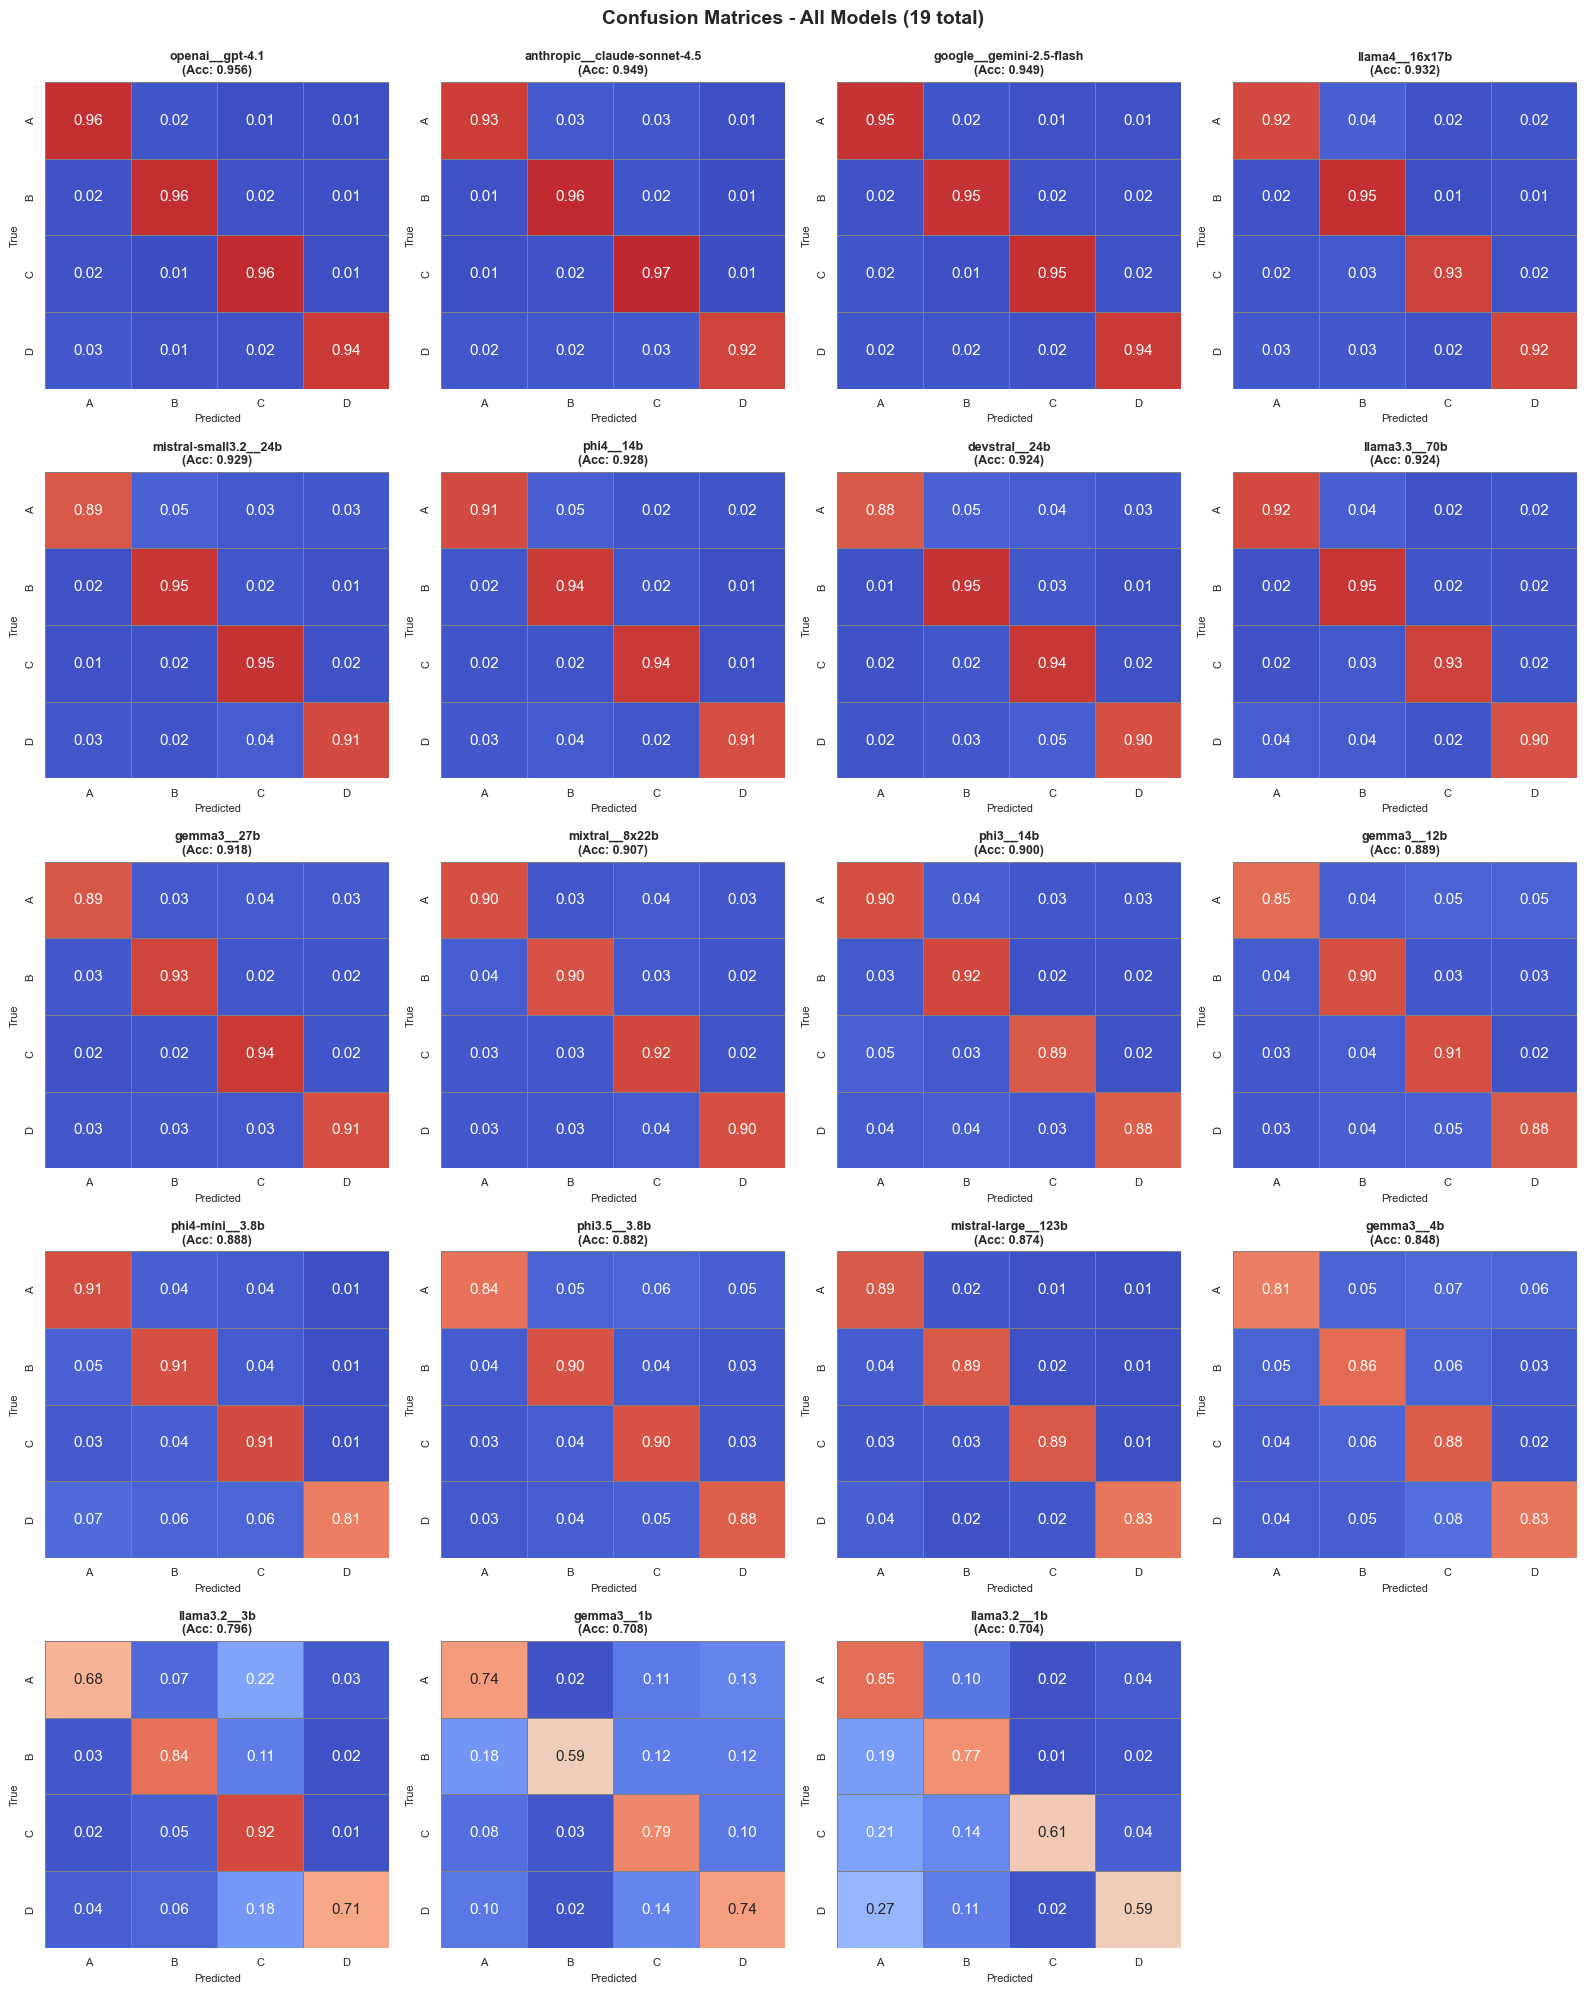


✅ Saved: output/mcq_confusion_matrix_all_models.png


In [20]:
# ================================================================
# Plot 3: Confusion Matrix Small Multiples (All Models, Dynamic Grid)
# ================================================================

print("\n" + "=" * 80)
print("PLOT 3: Confusion Matrix - All Models (Dynamic Layout)")
print("=" * 80)

# ----------------------------------------------------------
# Compute accuracy per model and sort
# ----------------------------------------------------------
model_accuracy = (
    mcq_df.groupby('model')['is_correct']
    .mean()
    .sort_values(ascending=False)
)

all_models = model_accuracy.index.tolist()

print(f"Total models detected: {len(all_models)}")
for i, model in enumerate(all_models, 1):
    print(f"  {i}. {model}: {model_accuracy[model]:.4f}")

# ----------------------------------------------------------
# Dynamic subplot grid: always 4 columns, variable rows
# ----------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(all_models) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = np.array(axes).reshape(-1)  # flatten safely

# ----------------------------------------------------------
# Plot confusion matrices
# ----------------------------------------------------------
for idx, model in enumerate(all_models):
    model_data = mcq_df[mcq_df['model'] == model]

    # Row-normalized confusion matrix
    conf_mat = pd.crosstab(
        model_data['correct_answer'],
        model_data['model_answer'],
        normalize='index'
    )

    # Ensure consistent A–D structure even if some keys missing
    # Ensure consistent A–D structure even if some keys missing
    for pos in ['A', 'B', 'C', 'D']:
        if pos not in conf_mat.index:
            conf_mat.loc[pos] = 0
        if pos not in conf_mat.columns:
            conf_mat[pos] = 0

    conf_mat = conf_mat.reindex(
        index=['A', 'B', 'C', 'D'],
        columns=['A', 'B', 'C', 'D'],
        fill_value=0
    )

    sns.heatmap(
        conf_mat,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        vmin=0, vmax=1,
        cbar=False,
        ax=axes[idx],
        linewidths=0.5,
        linecolor='gray'
    )

    axes[idx].set_title(
        f"{model}\n(Acc: {model_accuracy[model]:.3f})",
        fontsize=9,
        fontweight='bold'
    )
    axes[idx].set_xlabel("Predicted", fontsize=8)
    axes[idx].set_ylabel("True", fontsize=8)
    axes[idx].tick_params(labelsize=8)

# ----------------------------------------------------------
# Hide unused plots (only applies when model count % 4 != 0)
# ----------------------------------------------------------
for j in range(len(all_models), len(axes)):
    axes[j].axis('off')

plt.suptitle(
    f"Confusion Matrices - All Models ({len(all_models)} total)",
    fontsize=14,
    fontweight='bold',
    y=0.995
)

plt.tight_layout()
plt.savefig(output_dir / "mcq_confusion_matrix_all_models.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved: {output_dir}/mcq_confusion_matrix_all_models.png")



PLOT 4: Wrong-Answer Distribution Analysis


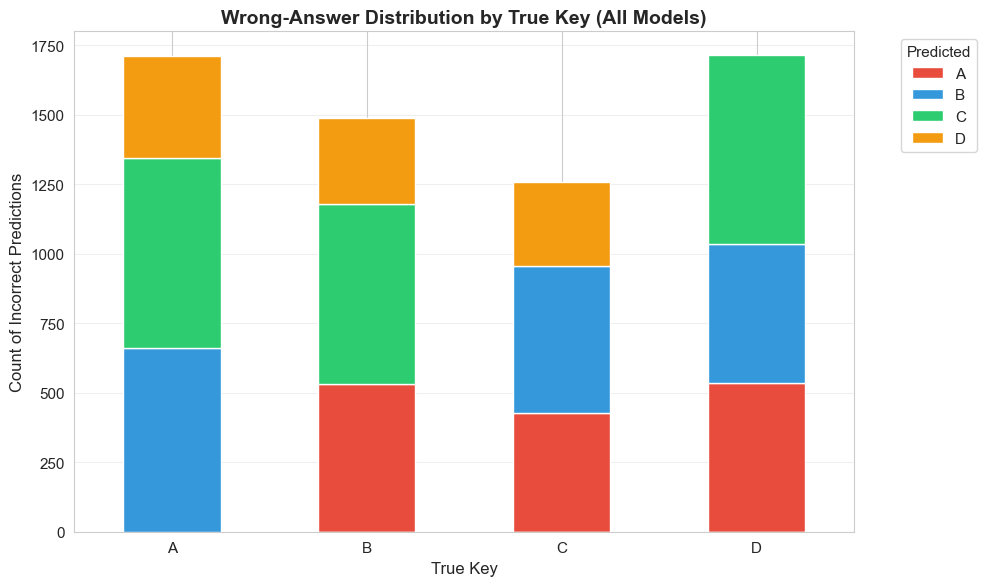

✅ Saved: output/mcq_wrong_answer_distribution.png
✅ Saved: output/mcq_wrong_answer_distribution.png

Wrong answer summary:
predicted      A      B      C      D
true_key                             
A            0.0  660.0  684.0  368.0
B          532.0    0.0  647.0  310.0
C          429.0  526.0    0.0  303.0
D          537.0  499.0  679.0    0.0


In [84]:
# Plot 4: Wrong-Answer Distribution (Stacked Bars)
# For each true key (A-D), show distribution of INCORRECT predictions by model

print("\n" + "=" * 80)
print("PLOT 4: Wrong-Answer Distribution Analysis")
print("=" * 80)

# Get data for INCORRECT answers only
incorrect_only = mcq_df[~mcq_df['is_correct']].copy()

# For each true answer, count predictions (excluding correct ones)
wrong_answer_data = []

for true_key in ['A', 'B', 'C', 'D']:
    subset = incorrect_only[incorrect_only['correct_answer'] == true_key]
    
    for model in mcq_df['model'].unique():
        model_subset = subset[subset['model'] == model]
        
        # Count predictions for each position
        for pred in ['A', 'B', 'C', 'D']:
            if pred != true_key:  # Exclude correct answer
                count = (model_subset['model_answer'] == pred).sum()
                wrong_answer_data.append({
                    'true_key': true_key,
                    'model': model,
                    'predicted': pred,
                    'count': count
                })

wrong_df = pd.DataFrame(wrong_answer_data)

# Aggregate across all models for visualization
wrong_agg = wrong_df.groupby(['true_key', 'predicted'])['count'].sum().reset_index()

# Pivot for stacked bar chart
wrong_pivot = wrong_agg.pivot(index='true_key', columns='predicted', values='count').fillna(0)

# Remove correct answers (diagonal)
for key in ['A', 'B', 'C', 'D']:
    if key in wrong_pivot.columns and key in wrong_pivot.index:
        wrong_pivot.loc[key, key] = 0

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
wrong_pivot.plot(kind='bar', stacked=True, ax=ax, 
                 color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])

ax.set_xlabel('True Key', fontsize=12)
ax.set_ylabel('Count of Incorrect Predictions', fontsize=12)
ax.set_title('Wrong-Answer Distribution by True Key (All Models)', fontsize=14, fontweight='bold')
ax.set_xticklabels(['A', 'B', 'C', 'D'], rotation=0)
ax.legend(title='Predicted', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'mcq_wrong_answer_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/mcq_wrong_answer_distribution.png")
print(f"✅ Saved: {output_dir}/mcq_wrong_answer_distribution.png")
print(f"\nWrong answer summary:")
print(wrong_pivot)

## 6. Summary Tables & Export


In [ ]:
# Table 2: Position Accuracy Summary
# Show accuracy for each position (A/B/C/D) by model with mean and std

print("\n" + "=" * 80)
print("TABLE 2: Position Accuracy Summary")
print("=" * 80)

# Pivot accuracy data
pos_acc_table = position_accuracy.pivot(index='model', columns='variant', values='accuracy')
pos_acc_table.columns = [f'Acc_{c.upper()}' for c in pos_acc_table.columns]

# Add mean and std across positions
pos_acc_table['Mean'] = pos_acc_table.mean(axis=1)
pos_acc_table['Std'] = pos_acc_table.std(axis=1)

# Sort by mean accuracy
pos_acc_table = pos_acc_table.sort_values('Mean', ascending=False)

# Display table
print("\nPosition Accuracy by Model:")
print(pos_acc_table.to_string())

# Export to LaTeX
export_latex_table(
    pos_acc_table,
    'table_position_accuracy.tex',
    'MCQ Accuracy by Answer Position and Model',
    'tab:position_accuracy',
    column_format='lrrrrrr'
)

print(f"\n✅ Table displayed and exported to LaTeX")

In [ ]:
# Table 1: Position Bias Statistical Tests
# Combine Chi-square and ANOVA results for all models

print("\n" + "=" * 80)
print("TABLE 1: Position Bias Statistical Tests")
print("=" * 80)

stat_test_results = []

for model in mcq_fixed['model'].unique():
    model_data = mcq_fixed[mcq_fixed['model'] == model]
    
    # Chi-square test
    contingency = pd.crosstab(model_data['variant'], model_data['is_correct'])
    chi2, chi2_p, dof, expected = chi2_contingency(contingency)
    
    # ANOVA test
    groups = [model_data[model_data['variant'] == v]['is_correct'].astype(int).values 
              for v in ['a', 'b', 'c', 'd']]
    f_stat, anova_p = f_oneway(*groups)
    
    stat_test_results.append({
        'Model': model,
        'Chi²': chi2,
        'Chi² p-value': chi2_p,
        'Chi²': chi2,
        'Chi² p-value': chi2_p,
        'F-statistic': f_stat,
        'ANOVA p-value': anova_p,
        'Significant ($\\alpha=0.05$)': 'Yes' if chi2_p < 0.05 else 'No'
    })

stat_df = pd.DataFrame(stat_test_results)
stat_df = stat_df.set_index('Model')

# Display table
print("\nPosition Bias Statistical Tests:")
print(stat_df.to_string())

# Export to LaTeX
export_latex_table(
    stat_df,
    'table_position_bias_tests.tex',
    'Position Bias Statistical Tests for MCQ Variants',
    'tab:position_bias_tests',
    column_format='lrrrrr'
)

print(f"\n✅ Table displayed and exported to LaTeX")

In [89]:
# ANOVA test for position bias
print("\n📊 One-Way ANOVA for Position Bias")
print("=" * 80)
print("H0: Mean accuracy is equal across all positions\n")

for model in mcq_fixed['model'].unique():
    model_data = mcq_fixed[mcq_fixed['model'] == model]
    
    # Group by variant
    groups = [model_data[model_data['variant'] == v]['is_correct'].astype(int).values 
              for v in ['a', 'b', 'c', 'd']]
    
    # Perform one-way ANOVA
    f_stat, p_value = f_oneway(*groups)
    
    print(f"Model: {model}")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Result: {'Significant' if p_value < 0.05 else 'Not significant'} at α=0.05")
    print()


📊 One-Way ANOVA for Position Bias
H0: Mean accuracy is equal across all positions

Model: anthropic__claude-sonnet-4.5
  F-statistic: 6.6046
  p-value: 0.0002
  Result: Significant at α=0.05

Model: devstral__24b
  F-statistic: 8.8296
  p-value: 0.0000
  Result: Significant at α=0.05

Model: gemma3__12b
  F-statistic: 4.0007
  p-value: 0.0074
  Result: Significant at α=0.05

Model: gemma3__27b
  F-statistic: 2.9164
  p-value: 0.0329
  Result: Significant at α=0.05

Model: google__gemini-2.5-flash
  F-statistic: 0.3691
  p-value: 0.7753
  Result: Not significant at α=0.05

Model: llama3.2__3b
  F-statistic: 71.8676
  p-value: 0.0000
  Result: Significant at α=0.05

Model: llama3.3__70b
  F-statistic: 3.3117
  p-value: 0.0192
  Result: Significant at α=0.05

Model: llama4__16x17b
  F-statistic: 2.6025
  p-value: 0.0503
  Result: Not significant at α=0.05

Model: mistral-large__123b
  F-statistic: 6.9520
  p-value: 0.0001
  Result: Significant at α=0.05

Model: mistral-small3.2__24b
  F-

### Output Summary and Manifest


In [92]:
# Final Summary: List all generated outputs
import os

print("=" * 80)
print(" " * 25 + "OUTPUT MANIFEST")
print("=" * 80)

# Scan output directory
output_files = list(output_dir.glob('*'))
plots = [f for f in output_files if f.suffix == '.png']
tables = [f for f in output_files if f.suffix == '.tex']
csvs = [f for f in output_files if f.suffix == '.csv']

print(f"\n📊 PLOTS GENERATED ({len(plots)}):")
print("-" * 80)
for i, plot in enumerate(sorted(plots), 1):
    size = os.path.getsize(plot) / 1024  # KB
    print(f"  {i:2d}. {plot.name:<50s} ({size:>8.1f} KB)")

print(f"\n📋 LATEX TABLES GENERATED ({len(tables)}):")
print("-" * 80)
for i, table in enumerate(sorted(tables), 1):
    size = os.path.getsize(table) / 1024  # KB
    print(f"  {i:2d}. {table.name:<50s} ({size:>8.1f} KB)")

print(f"\n💾 CSV DATA FILES ({len(csvs)}):")
print("-" * 80)
for i, csv in enumerate(sorted(csvs), 1):
    size = os.path.getsize(csv) / 1024  # KB
    print(f"  {i:2d}. {csv.name:<50s} ({size:>8.1f} KB)")

total_size = sum(os.path.getsize(f) for f in output_files) / (1024 * 1024)  # MB
print(f"\n" + "=" * 80)
print(f"Total Output Directory Size: {total_size:.2f} MB")
print(f"Total Files Generated: {len(output_files)}")
print("=" * 80)

print("\n✅ ANALYSIS COMPLETE!")
print(f"   All outputs saved to: {output_dir.absolute()}")

                         OUTPUT MANIFEST

📊 PLOTS GENERATED (17):
--------------------------------------------------------------------------------
   1. mcq_bootstrap_ci.png                               (   187.5 KB)
   2. mcq_confusion_matrix_all_models.png                (   633.5 KB)
   3. mcq_confusion_matrix_top_models.png                (   369.5 KB)
   4. mcq_deviation_from_uniform.png                     (   313.3 KB)
   5. mcq_position_heatmap.png                           (   394.4 KB)
   6. mcq_vs_osq_scatter.png                             (   248.0 KB)
   7. mcq_vs_osq_sidebyside.png                          (   211.8 KB)
   8. mcq_wrong_answer_distribution.png                  (   106.2 KB)
   9. osq_blooms_comparison.png                          (   130.6 KB)
  10. osq_score_histogram.png                            (   388.1 KB)
  11. osq_violin_scores.png                              (   444.4 KB)
  12. plot1_position_accuracy_heatmap_all_models.png     (   365.3 KB)
 